Got it. Here's a **template** you can reuse for every imputation column analysis — like `flat_on_floor`, `costpersqft`, etc.

---

### ✅ 1st: Quick Comparison — `column_name_here`

| Method            | Mean | Std Dev | Median | 75%  | Notes                                     |
| ----------------- | ---- | ------- | ------ | ---- | ----------------------------------------- |
| **Original**      | xxxx | xxxx    | xxxx   | xxxx | — Baseline                                |
| **KNN Imputed**   | xxxx | xxxx    | xxxx   | xxxx | ✅ Very close to original, preserves shape |
| **Iterative**     | xxxx | xxxx    | xxxx   | xxxx | ✅ Similar, but possible noise or shift    |
| **Mean**          | xxxx | xxxx    | xxxx   | xxxx | ⚠️ Median/shape may shift slightly        |
| **Median**        | xxxx | xxxx    | xxxx   | xxxx | ✅ Stable, generally safe                  |
| **Constant**      | xxxx | xxxx    | xxxx   | xxxx | ❌ Not reliable, distorts distribution     |
| **Most Frequent** | xxxx | xxxx    | xxxx   | xxxx | ⚠️ Redundant or risky if not categorical  |

---

### ✅ 2nd: Final Recommendation for `column_name_here`:

Use **KNN Imputation** — best preserves distribution and aligns closely with original data.

**Alternative:** Iterative or Median — both **safe** and **stable**.

🚫 **Avoid:**

* **Mean** (can distort median and flatten distribution)
* **Constant** (high risk of unrealistic values)
* **Most Frequent** (not suitable for numeric/ordinal)

👉 **Final pick:** `KNN > Iterative ≈ Median`

---

Would you like me to fill this out for your `flat_on_floor` column now?


In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split



from sklearn.preprocessing import PowerTransformer, OneHotEncoder, MultiLabelBinarizer, OrdinalEncoder, MinMaxScaler, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer, MissingIndicator
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



#libraries not req in vscode
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import math

# functions

`print the .describe() and .isna().sum() for that column`

In [2]:
def describe_and_missing(data, column_name):
    print(f"\n--- Description for '{column_name}' ---")
    print(data[column_name].describe())
    print('-'*100)
    print(f"\nMissing values in '{column_name}': {data[column_name].isna().sum()}")

`plots the KDE plot with different imputations`

In [3]:
def get_simple_imputations(data, column_name, constant_value=9999):
    col_data = data[[column_name]].astype(float)  # Ensure numeric

    mean_imputed = np.array(SimpleImputer(strategy='mean').fit_transform(col_data)).ravel()
    median_imputed = np.array(SimpleImputer(strategy='median').fit_transform(col_data)).ravel()
    most_frequent_imputed = np.array(SimpleImputer(strategy='most_frequent').fit_transform(col_data)).ravel()
    constant_imputed = np.array(SimpleImputer(strategy='constant', fill_value=constant_value).fit_transform(col_data)).ravel()

    return mean_imputed, median_imputed, most_frequent_imputed, constant_imputed

def plot_kde_imputations(data, column_name, constant_value=9999):
    original = data[column_name].dropna()
    mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(data, column_name, constant_value)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # Mean Imputation
    sns.kdeplot(original, label='Original', ax=axes[0])
    sns.kdeplot(mean_imputed, label='Mean Imputed', ax=axes[0])
    axes[0].set_title('Mean Imputation')
    axes[0].legend()

    # Median Imputation
    sns.kdeplot(original, label='Original', ax=axes[1])
    sns.kdeplot(median_imputed, label='Median Imputed', ax=axes[1])
    axes[1].set_title('Median Imputation')
    axes[1].legend()

    # Most Frequent Imputation
    sns.kdeplot(original, label='Original', ax=axes[2])
    sns.kdeplot(most_frequent_imputed, label='Most Frequent Imputed', ax=axes[2])
    axes[2].set_title('Most Frequent Imputation')
    axes[2].legend()

    # Constant Imputation
    sns.kdeplot(original, label='Original', ax=axes[3])
    sns.kdeplot(constant_imputed, label='Constant Imputed', ax=axes[3])
    axes[3].set_title('Constant Imputation')
    axes[3].legend()

    plt.suptitle(f"KDE Plots for '{column_name}' (Before and After Imputation)", fontsize=16)
    plt.tight_layout()
    plt.show()


`Visualize original vs iterative imputed values for any numeric column`

In [4]:
def plot_iterative_imputation_kde(data, column_name):
    # 1. Save original column
    original = data[column_name].copy()

    # 2. Select numeric columns
    numeric_data = data.select_dtypes(include='number').copy()

    # 3. Apply IterativeImputer
    imputer = IterativeImputer(random_state=0)
    numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_data.columns)

    # 4. Replace the imputed column in original data
    data_iter_imputed = data.copy()
    data_iter_imputed[column_name] = numeric_imputed[column_name]

    # 5. Plot KDE
    plt.figure(figsize=(10, 6))
    sns.kdeplot(original.dropna(), label='original', color='blue')
    sns.kdeplot(data_iter_imputed[column_name], label='iterative imputed (full)', color='orange')
    plt.xlabel(column_name)
    plt.ylabel('Density')
    plt.title(f"KDE Plot: Original vs Iterative Imputed ({column_name})")
    plt.legend()
    plt.show()
    
    return original, data_iter_imputed

In [5]:
# #i am confuse in this iterative + clipping and above only iterative method 
# #so i have ask this to sir in doubt on 23-7-25 lets see 
# #so after that keep any one function from above and this one  

# def plot_iterative_imputation_kde(data, column_name):
#     # 1. Save original column
#     original = data[column_name].copy()

#     # 2. Select numeric columns
#     numeric_data = data.select_dtypes(include='number').copy()

#     # 3. Apply IterativeImputer
#     imputer = IterativeImputer(random_state=0)
#     numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_data.columns)

#     # 4. Replace the imputed column in original data
#     data_iter_imputed = data.copy()
    
#     # 4.1 Clip the imputed column to match original min/max
#     min_val = original.min()
#     max_val = original.max()
#     clipped_column = numeric_imputed[column_name].clip(lower=min_val, upper=max_val)

#     data_iter_imputed[column_name] = clipped_column

#     # 5. Plot KDE
#     plt.figure(figsize=(10, 6))
#     sns.kdeplot(original.dropna(), label='original', color='blue')
#     sns.kdeplot(clipped_column, label='iterative imputed (clipped)', color='orange')
#     plt.xlabel(column_name)
#     plt.ylabel('Density')
#     plt.title(f"KDE Plot: Original vs Iterative Imputed ({column_name})")
#     plt.legend()
#     plt.show()
    
#     return original, data_iter_imputed


`Visualize original vs KNN imputed values for any numeric column`

In [6]:
def plot_knn_imputation_kde(data, column_name, n_neighbors=5):
    # 1. Save original column
    original = data[column_name].copy()

    # 2. Select numeric columns
    numeric_data = data.select_dtypes(include='number').copy()

    # 3. Apply KNNImputer
    imputer = KNNImputer(n_neighbors=n_neighbors)
    numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_data.columns)

    # 4. Replace the imputed column in original data
    data_knn_imputed = data.copy()
    data_knn_imputed[column_name] = numeric_imputed[column_name]

    # 5. Plot KDE
    plt.figure(figsize=(10, 6))
    sns.kdeplot(original.dropna(), label='original', color='blue')
    sns.kdeplot(data_knn_imputed[column_name], label='knn imputed (full)', color='green')
    plt.xlabel(column_name)
    plt.ylabel('Density')
    plt.title(f"KDE Plot: Original vs KNN Imputed ({column_name})")
    plt.legend()
    plt.show()

    return original, data_knn_imputed

`categorical imputation strategies: original vs most frequent vs constant`

In [7]:
def plot_categorical_imputations(data, column_name, constant_value="missing"):
    # 1. Copy the column
    original = data[column_name].copy()

    # 2. Check shape and missing values
    print("Data shape:", data.shape)
    print(f"Missing values in '{column_name}':", original.isna().sum())

    # 3. Impute using mode (most frequent)
    mode_value = original.mode()[0]
    print("Mode:", mode_value)

    # 4. Fill missing with mode
    most_frequent_imputed = original.fillna(mode_value)

    # 5. Fill missing with constant
    constant_imputed = original.fillna(constant_value)

    # 6. Plot all
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.countplot(x=original, ax=axes[0])
    axes[0].set_title("Original")

    sns.countplot(x=most_frequent_imputed, order=original.value_counts().index, ax=axes[1])
    axes[1].set_title("Most Frequent Imputed")

    order_for_constant = list(original.dropna().value_counts().index) + [constant_value]
    sns.countplot(x=constant_imputed, order=order_for_constant, ax=axes[2])
    axes[2].set_title("Constant Imputed")

    plt.tight_layout()
    plt.show()

`target encoding with i/p option as handle missing values using target encoding or not`

In [8]:
def apply_target_encoding_train_only(X_train, y_train, columns, handle_missing_option='value'):
    encoder = TargetEncoder(cols=columns, handle_missing=handle_missing_option)
    X_encoded = encoder.fit_transform(X_train, y_train)

    return X_encoded, encoder

#use
#handle missing value using target encoder     
#X_encoded, enc = apply_target_encoding_train_only(X_train, y_train, ['project_name'], handle_missing_option='value')
    
#do not handle missing values using target encoder means return nan values as it is after target encoding     
#X_encoded, enc = apply_target_encoding_train_only(X_train, y_train, ['project_name'], handle_missing_option='return_nan')

# Building a Baseline model 

In [9]:
#Here, I used the data saved using VS Code. This data has 184 columns, which means it is the result of merging df and am_df.
df = pd.read_csv(r'C:\Users\ABC\Desktop/bhushan/property_project/files_vscode/data/py_cleaned_data.csv')

C:\Users\ABC\AppData\Local\Temp\ipykernel_2580\610101231.py:2: DtypeWarning: Columns (106,128,134,135,136,137,138,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\ABC\Desktop/bhushan/property_project/files_vscode/data/py_cleaned_data.csv')


In [10]:
df.shape

(11857, 184)

In [11]:
#except amenities col lets analyze all other col
for col in df.columns:
  if col.startswith('am'):
    continue
  print(col)

id
price
flooring
available_units
towers
construction
ownership
emi
bed
bath
parking
area
costpersqft
flat_on_floor
total_floor
lift
balcony
lattitude
longitude
project_in_acres
builder
project_name
furnish
city
location
property_type
status
extra_rooms
facing
seller
price_category
overlooking
education_mean_km
education_min_km
education_within_2km
transport_mean_km
transport_min_km
transport_within_2km
shopping_centre_mean_km
shopping_centre_min_km
shopping_centre_within_2km
commercial_hub_mean_km
commercial_hub_min_km
commercial_hub_within_2km
hospital_within_2km
tourist_within_2km
overall_min_mean_km
overall_avg_mean_km
overall_min_min_km
overall_avg_min_km
total_within_2km


In [12]:
# drop columns not required for model input 
columns_to_drop = ['id','price_category','costpersqft','emi']

df.drop(columns = columns_to_drop , inplace = True)
df.head()

,price,flooring,available_units,towers,am_12204,am_12226,am_12225,am_12229,am_12230,am_1404107,...,commercial_hub_mean_km,commercial_hub_min_km,commercial_hub_within_2km,hospital_within_2km,tourist_within_2km,overall_min_mean_km,overall_avg_mean_km,overall_min_min_km,overall_avg_min_km,total_within_2km
0,1.80,vitrified,1512.0,10.0,club house,cafeteria/food court,bar/lounge,jogging and strolling track,outdoor tennis courts,barbeque pit,...,NaN,NaN,0,0,0,1.833333,3.044444,1.2,2.100000,2
1,2.37,"vitrified, wooden, ceramic tiles",810.0,6.0,club house,cafeteria/food court,bar/lounge,jogging and strolling track,outdoor tennis courts,barbeque pit,...,6.0,2.3,0,0,0,2.760000,3.980000,1.1,1.900000,2
2,1.80,NaN,412.0,2.0,NaN,NaN,NaN,jogging and strolling track,NaN,barbeque pit,...,18.5,18.4,0,0,0,5.380000,10.417917,0.2,4.900000,8
3,1.64,vitrified,339.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,0
4,1.26,vitrified,174.0,1.0,club house,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,1.200000,2.370000,1.2,1.566667,4


In [13]:
# combine all amenities and make one column
# Step 1: Filter columns that start with 'am_'
am_cols = [col for col in df.columns if col.startswith('am_')]

# Step 2: Combine values row-wise into a comma-separated string (not a list)
df['amenities'] = df[am_cols].apply(
    lambda row: ', '.join([str(val).strip() for val in row if isinstance(val, str) and val.strip() != ""]),
    axis=1
)

In [14]:
# Step 3: Drop original 'am_' columns
df.drop(columns=am_cols, inplace=True)

In [15]:
df['amenities'].head()

0    club house, cafeteria/food court, bar/lounge, ...
1    club house, cafeteria/food court, bar/lounge, ...
2    jogging and strolling track, barbeque pit, lif...
3    power back up, swimming pool, lift, security, ...
4    club house, swimming pool, banquet hall, gymna...
Name: amenities, dtype: object

In [16]:
# check for missing values 

df.isna().sum()

price                            0
flooring                      4430
available_units               5198
towers                        5005
construction                  1048
ownership                     3590
bed                              0
bath                            30
parking                       6152
area                             5
flat_on_floor                 2287
total_floor                   2054
lift                          5419
balcony                       5801
lattitude                      464
longitude                      464
project_in_acres              5730
builder                       4255
project_name                  3479
furnish                         39
city                             0
location                       481
property_type                    2
status                          82
extra_rooms                   5275
facing                        3716
seller                           0
overlooking                   3945
education_mean_km   

In [17]:
df.duplicated().sum()

229

`observation`
- after dreopping id column got 224 duplicate rows

In [18]:
#drop duplicate rows 
df.drop_duplicates(inplace=True)

<Axes: >

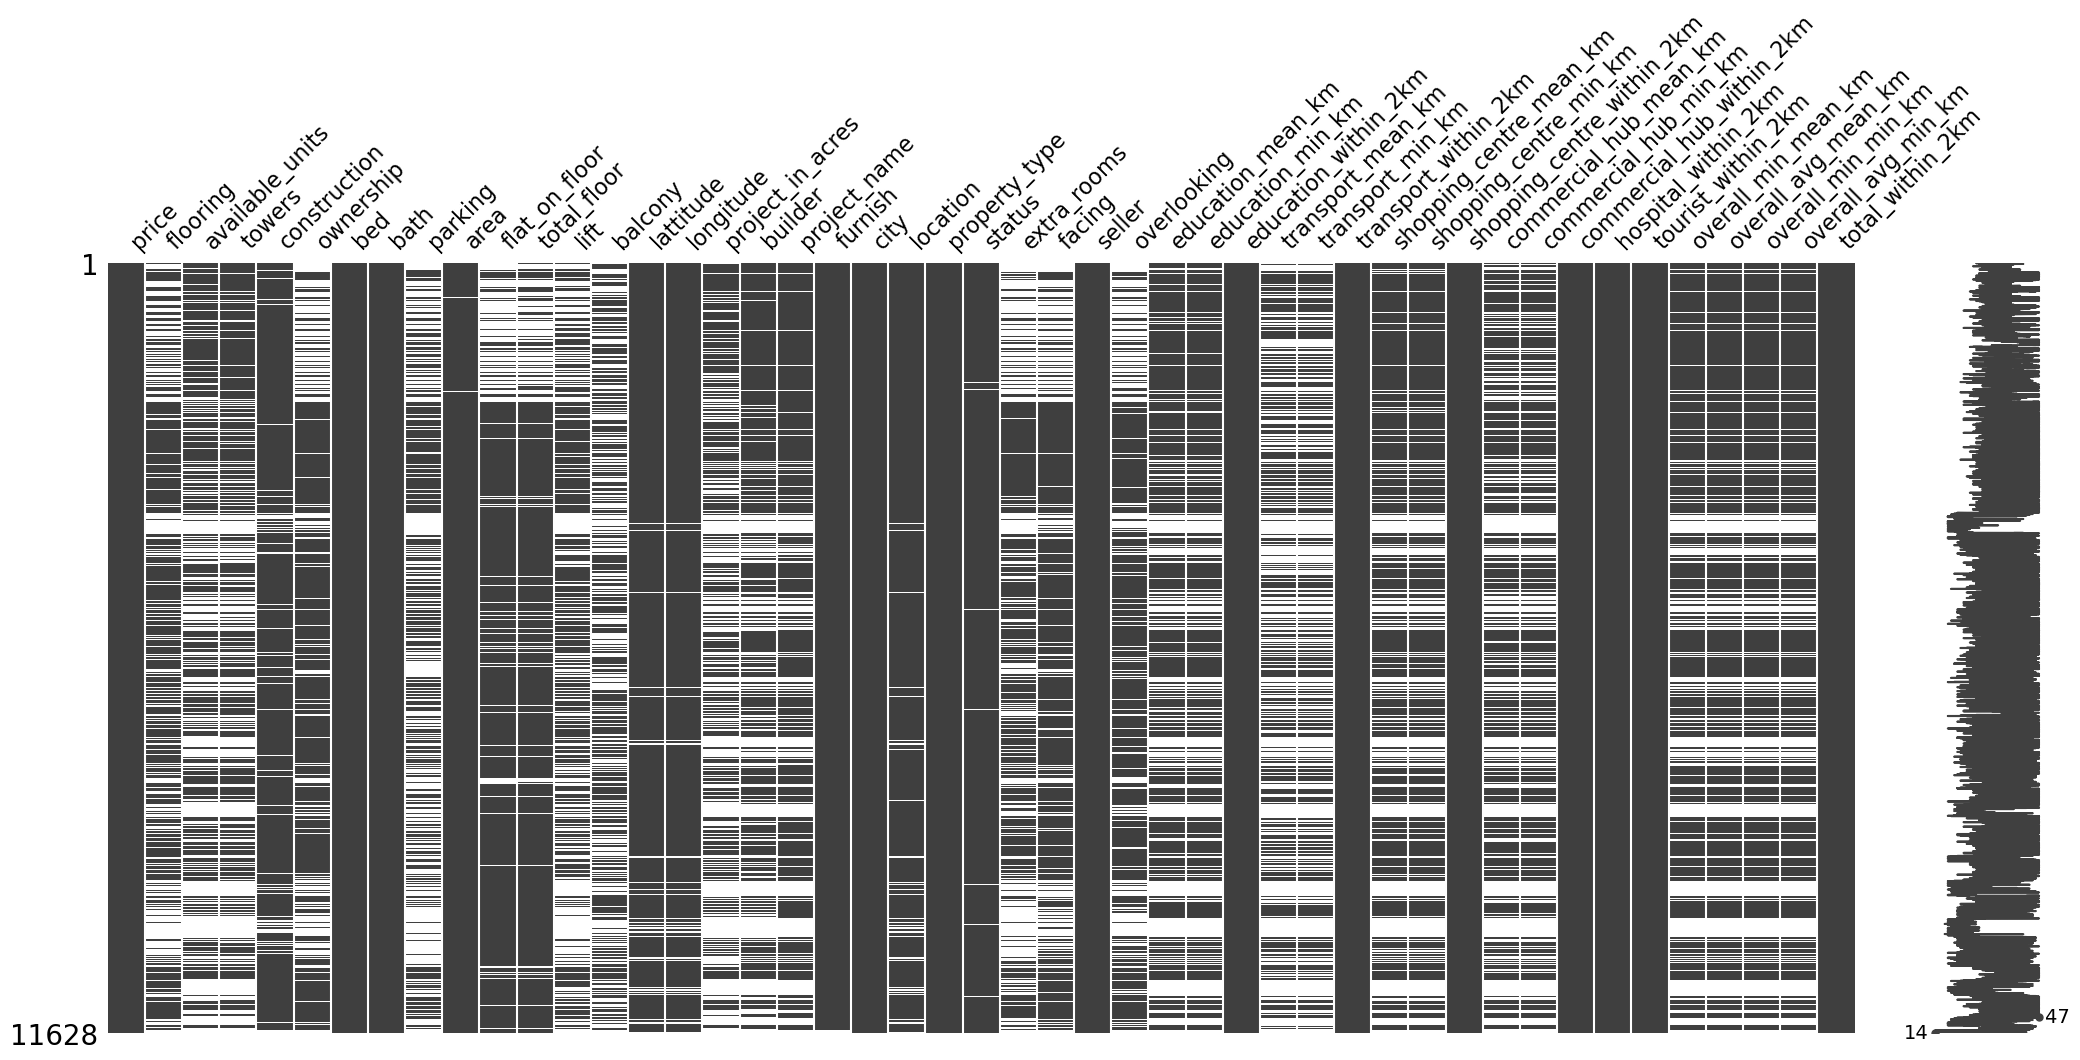

In [19]:
cols_to_check = [col for col in df.columns if not col.startswith('am')]
msno.matrix(df[cols_to_check])

In [20]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['flooring', 'available_units', 'towers', 'construction', 'ownership',
       'bath', 'parking', 'area', 'flat_on_floor', 'total_floor', 'lift',
       'balcony', 'lattitude', 'longitude', 'project_in_acres', 'builder',
       'project_name', 'furnish', 'location', 'property_type', 'status',
       'extra_rooms', 'facing', 'overlooking', 'education_mean_km',
       'education_min_km', 'transport_mean_km', 'transport_min_km',
       'shopping_centre_mean_km', 'shopping_centre_min_km',
       'commercial_hub_mean_km', 'commercial_hub_min_km',
       'overall_min_mean_km', 'overall_avg_mean_km', 'overall_min_min_km',
       'overall_avg_min_km'],
      dtype='object')

# Data preparation 

In [21]:
temp_df = df.copy()

In [22]:
# split data 

X = temp_df.drop(columns = 'price')
y = temp_df['price']

In [23]:
# Combine X and y back temporarily to check correlation
df_corr = X.copy()
df_corr['price'] = y  # original target

# Get only numeric columns
numeric_cols = df_corr.select_dtypes(include=[np.number])

# Calculate correlation with target
correlations = numeric_cols.corr()['price'].sort_values(ascending=False)

# Show top correlated features
print(correlations.head(15))


price                         1.000000
area                          0.874342
bath                          0.693031
bed                           0.658361
flat_on_floor                 0.362269
total_floor                   0.357294
lift                          0.280007
transport_min_km              0.161608
total_within_2km              0.154311
shopping_centre_within_2km    0.146298
education_within_2km          0.119450
balcony                       0.111886
commercial_hub_within_2km     0.105604
transport_within_2km          0.103677
tourist_within_2km            0.065853
Name: price, dtype: float64


`observation`

- The `emi` column is highly correlated with the target variable `price`.
- The `costpersqft` column is derived as `price / area`, which means it partially contains information about the target. This results in data leakage.
- Therefore, I will compare the model's performance **with** and **without** these columns to evaluate their impact.

In [24]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (9302, 47)
The shape of test data is (2326, 47)


`lets categorized the columns`

In [26]:
num_nominal_cols = ['project_in_acres','lattitude','longitude','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'transport_min_km',
                    'shopping_centre_mean_km', 'shopping_centre_min_km','commercial_hub_mean_km', 'commercial_hub_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                    'overall_min_min_km', 'overall_avg_min_km','available_units','towers']

num_ordinal_cols = ['flat_on_floor','total_floor','bed','bath','balcony','lift','parking','education_within_2km','transport_within_2km','shopping_centre_within_2km',
                    'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

nominal_cat_cols = ['builder','project_name','location','city','property_type','ownership','overlooking','facing','flooring','extra_rooms','seller']

ordinal_cat_cols = ['status','construction','furnish']

#there are amenities columns also which starts from am


#status : 'under construction < ongoing < ready to move'
#construction : 'under construction → new construction → less than 5 years → 5 to 10 years → 10 to 15 years → 15 to 20 years → above 20 years'
#furnish : 'unfurnished < semi-furnished < furnished'

In [27]:
len(num_nominal_cols + num_ordinal_cols + nominal_cat_cols + ordinal_cat_cols)

48

In [28]:
df.shape

(11628, 48)

# Transform Target column

In [29]:
pt = PowerTransformer(method='yeo-johnson')
y_train_trans = pd.Series(
    pt.fit_transform(y_train.values.reshape(-1, 1)).ravel(),
    index=y_train.index
)
y_test_trans = pd.Series(
    pt.transform(y_test.values.reshape(-1, 1)).ravel(),
    index=y_test.index
)

In [30]:
missing_cols

Index(['flooring', 'available_units', 'towers', 'construction', 'ownership',
       'bath', 'parking', 'area', 'flat_on_floor', 'total_floor', 'lift',
       'balcony', 'lattitude', 'longitude', 'project_in_acres', 'builder',
       'project_name', 'furnish', 'location', 'property_type', 'status',
       'extra_rooms', 'facing', 'overlooking', 'education_mean_km',
       'education_min_km', 'transport_mean_km', 'transport_min_km',
       'shopping_centre_mean_km', 'shopping_centre_min_km',
       'commercial_hub_mean_km', 'commercial_hub_min_km',
       'overall_min_mean_km', 'overall_avg_mean_km', 'overall_min_min_km',
       'overall_avg_min_km'],
      dtype='object')

In [31]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


93.0

In [32]:
#o/p in daraframe
from sklearn import set_config
set_config(transform_output="pandas")

# Missing value Imputation 

## Analysis on num_nominal_cols

In [33]:
num_nominal_cols = ['project_in_acres','lattitude','longitude','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'transport_min_km',
                    'shopping_centre_mean_km', 'shopping_centre_min_km','commercial_hub_mean_km', 'commercial_hub_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                    'overall_min_min_km', 'overall_avg_min_km','available_units','towers']

### project_in_acres

In [34]:
describe_and_missing(X_train, 'project_in_acres')


--- Description for 'project_in_acres' ---
count    4729.000000
mean       16.525708
std       127.551735
min         0.000000
25%         1.000000
50%         3.000000
75%         8.000000
max      4500.000000
Name: project_in_acres, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'project_in_acres': 4577


`observation`
- mean and median values are not similar still lets impute using simple imputer and check kdeplot
- missing values 4577

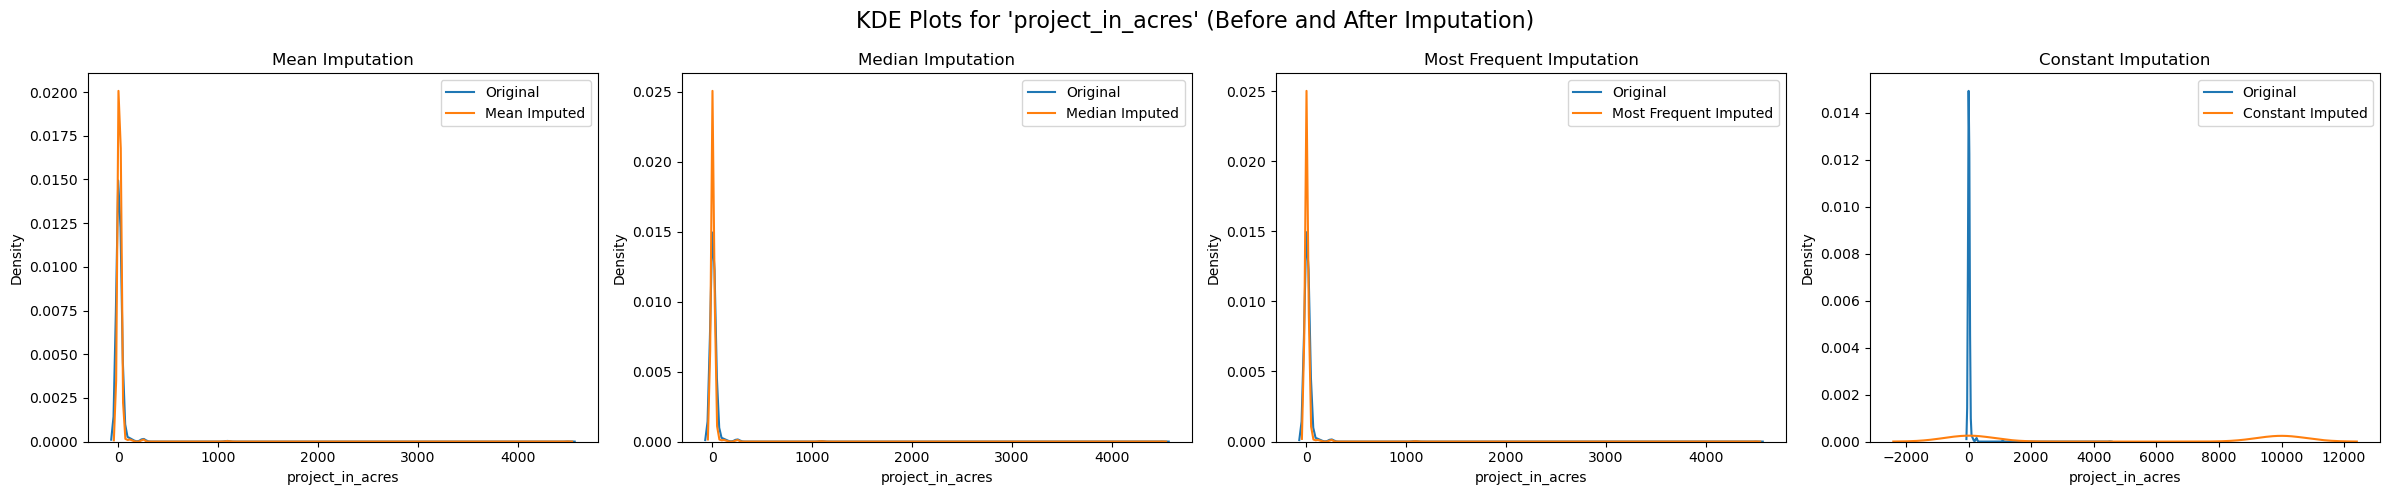

In [35]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'project_in_acres', constant_value=9999)
plot_kde_imputations(X_train, 'project_in_acres')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


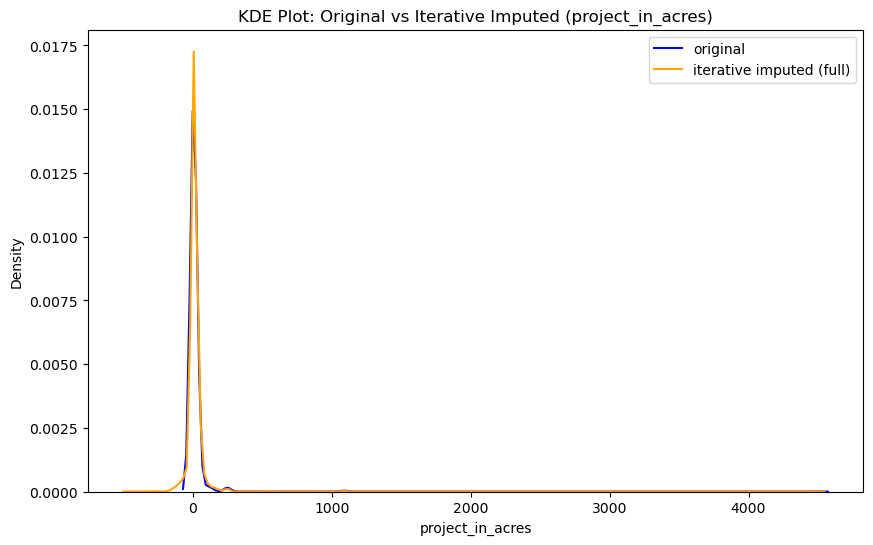

In [36]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'project_in_acres')

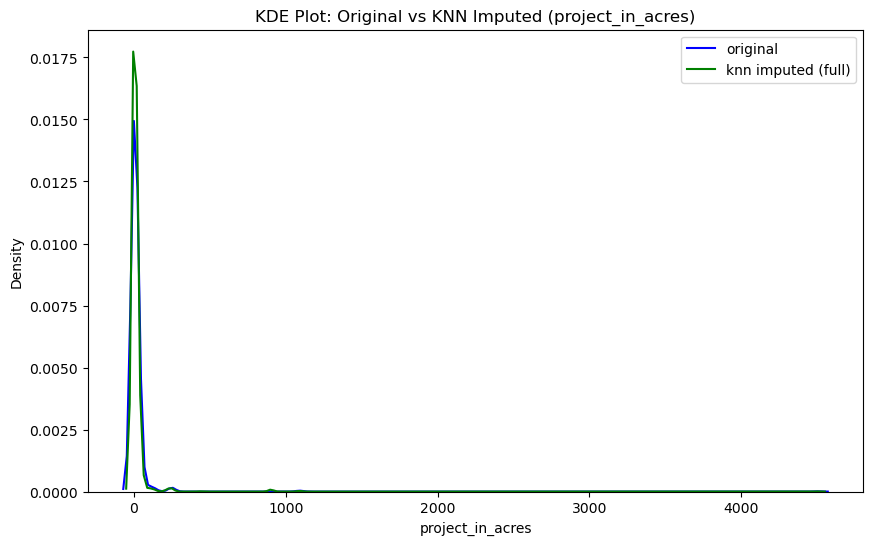

In [37]:
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'project_in_acres')

In [38]:
print("Original:\n", X_train['project_in_acres'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['project_in_acres'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['project_in_acres'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4729.000000
mean       16.525708
std       127.551735
min         0.000000
25%         1.000000
50%         3.000000
75%         8.000000
max      4500.000000
Name: project_in_acres, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       16.089347
std       106.173291
min         0.000000
25%         2.000000
50%         4.000000
75%         8.009100
max      4500.000000
Name: project_in_acres, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       15.218447
std        98.156755
min      -453.209717
25%         1.000000
50%         6.000000
75%        22.000000
max      4500.000000
Name: project_in_acres, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       16.525708
std        90.921568
min         0.000000
25%         3.000000
50%        16.525708
75%        16.525708
max      4500.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        9.873316
std        91.172696
min         0.000000
25%         3.000000
50%   

`observation`

- KNN imputation is more reliable here.
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

In [39]:
# Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
X_train_acres_imputed = imputer.fit_transform(X_train[['project_in_acres']])

# 3. Replace original column
X_train['project_in_acres'] = X_train_acres_imputed

In [40]:
X_train['project_in_acres'].isna().sum()

0

### lattitude

In [41]:
describe_and_missing(X_train, 'lattitude')


--- Description for 'lattitude' ---
count    8935.000000
mean       19.146099
std         0.118896
min        18.795002
25%        19.062055
50%        19.143622
75%        19.210299
max        19.832738
Name: lattitude, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'lattitude': 371


`observation`
- mean and median values are almost similar lets impute using simple imputer and check kdeplot

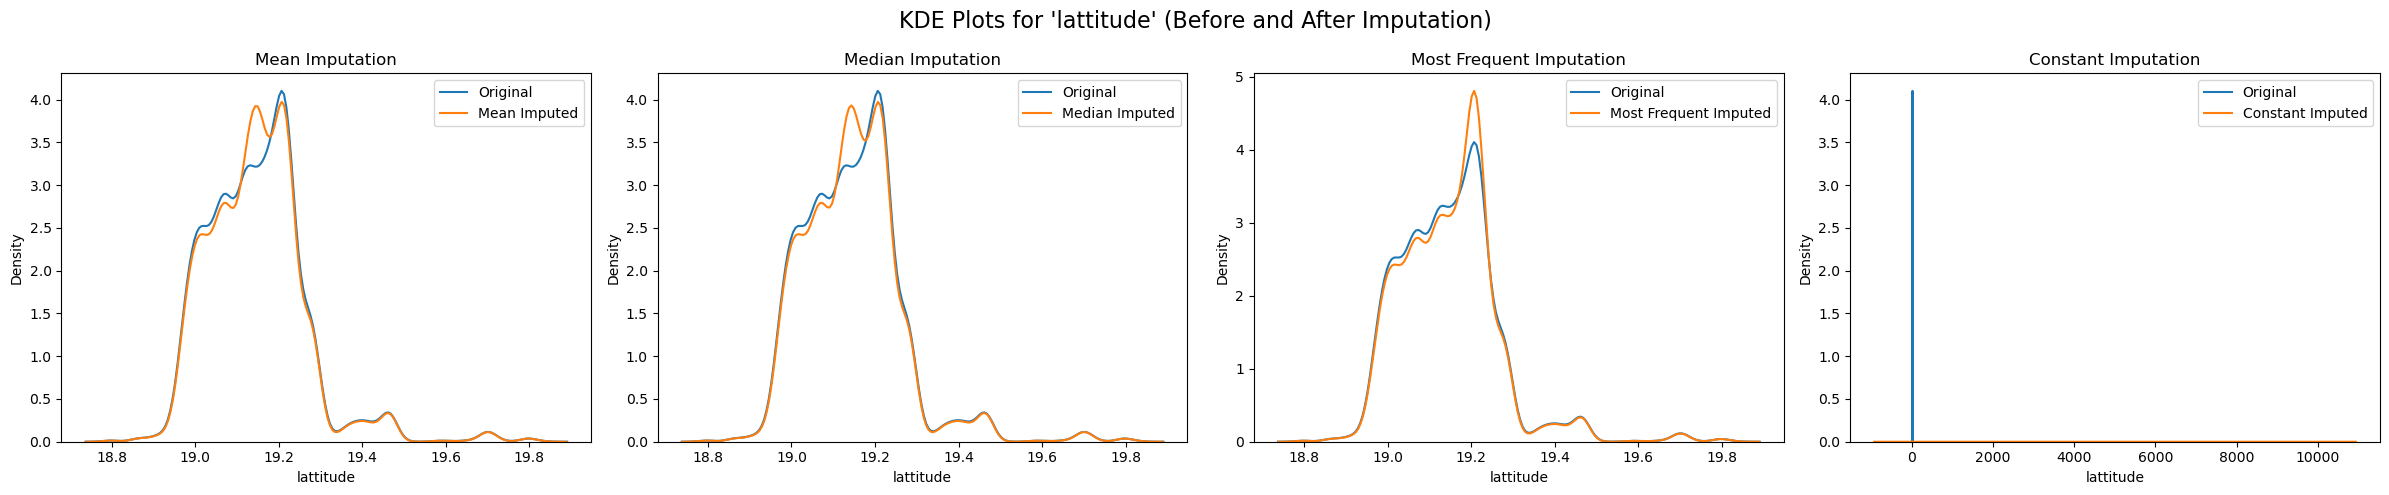

In [42]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'lattitude', constant_value=9999)
plot_kde_imputations(X_train, 'lattitude')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


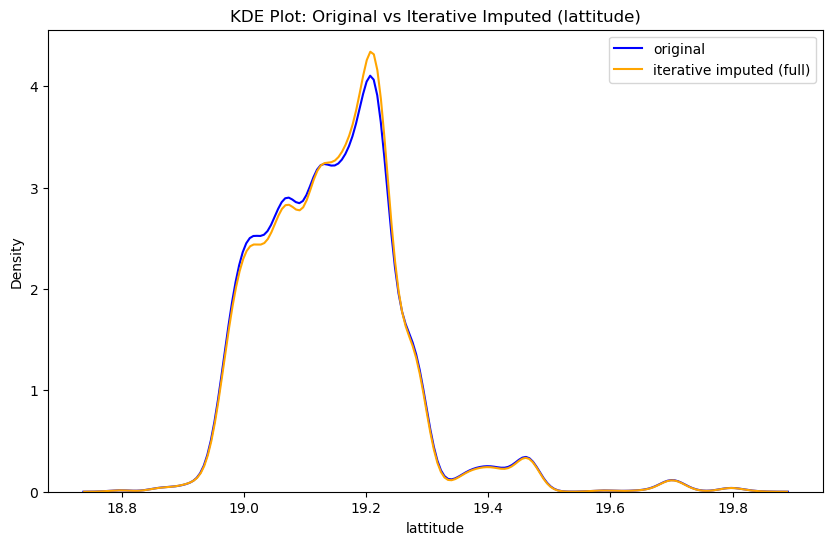

In [43]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'lattitude')

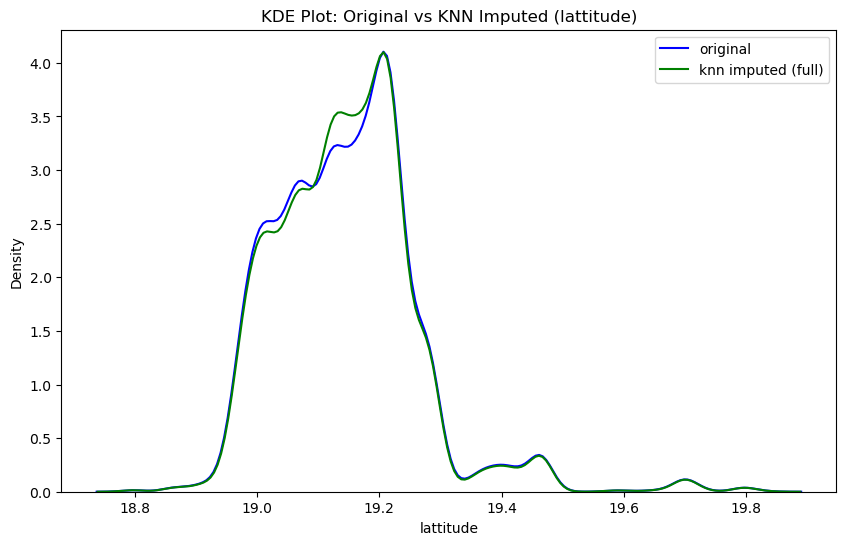

In [44]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'lattitude')

In [45]:
print("Original:\n", X_train['lattitude'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['lattitude'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['lattitude'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    8935.000000
mean       19.146099
std         0.118896
min        18.795002
25%        19.062055
50%        19.143622
75%        19.210299
max        19.832738
Name: lattitude, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       19.146334
std         0.116719
min        18.795002
25%        19.065672
50%        19.143882
75%        19.210131
max        19.832738
Name: lattitude, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       19.147510
std         0.117200
min        18.795002
25%        19.063918
50%        19.148366
75%        19.211267
max        19.832738
Name: lattitude, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       19.146099
std         0.116502
min        18.795002
25%        19.065672
50%        19.146099
75%        19.210131
max        19.832738
dtype: float64 

Median Imputed:
 count    9306.000000
mean       19.146001
std         0.116503
min        18.795002
25%        19.065672
50%        19.143622
75%   

`observation`

- both works almost same but iterative is slightly better than KNN 
- Try different max_iter and imputation_order': ['ascending', 'descending', 'roman', 'arabic'] and estimator': [BayesianRidge(), ExtraTreesRegressor(n_estimators=50, random_state=0), RandomForestRegressor(random_state=0)] to further improve iterative results.

### longitude

In [46]:
describe_and_missing(X_train, 'longitude')


--- Description for 'longitude' ---
count    8935.000000
mean       72.905286
std         0.086000
min        72.704548
25%        72.839809
50%        72.872695
75%        72.963282
max        73.337269
Name: longitude, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'longitude': 371


`observation`
- mean and median values are almost similar lets impute using simple imputer and check kdeplot

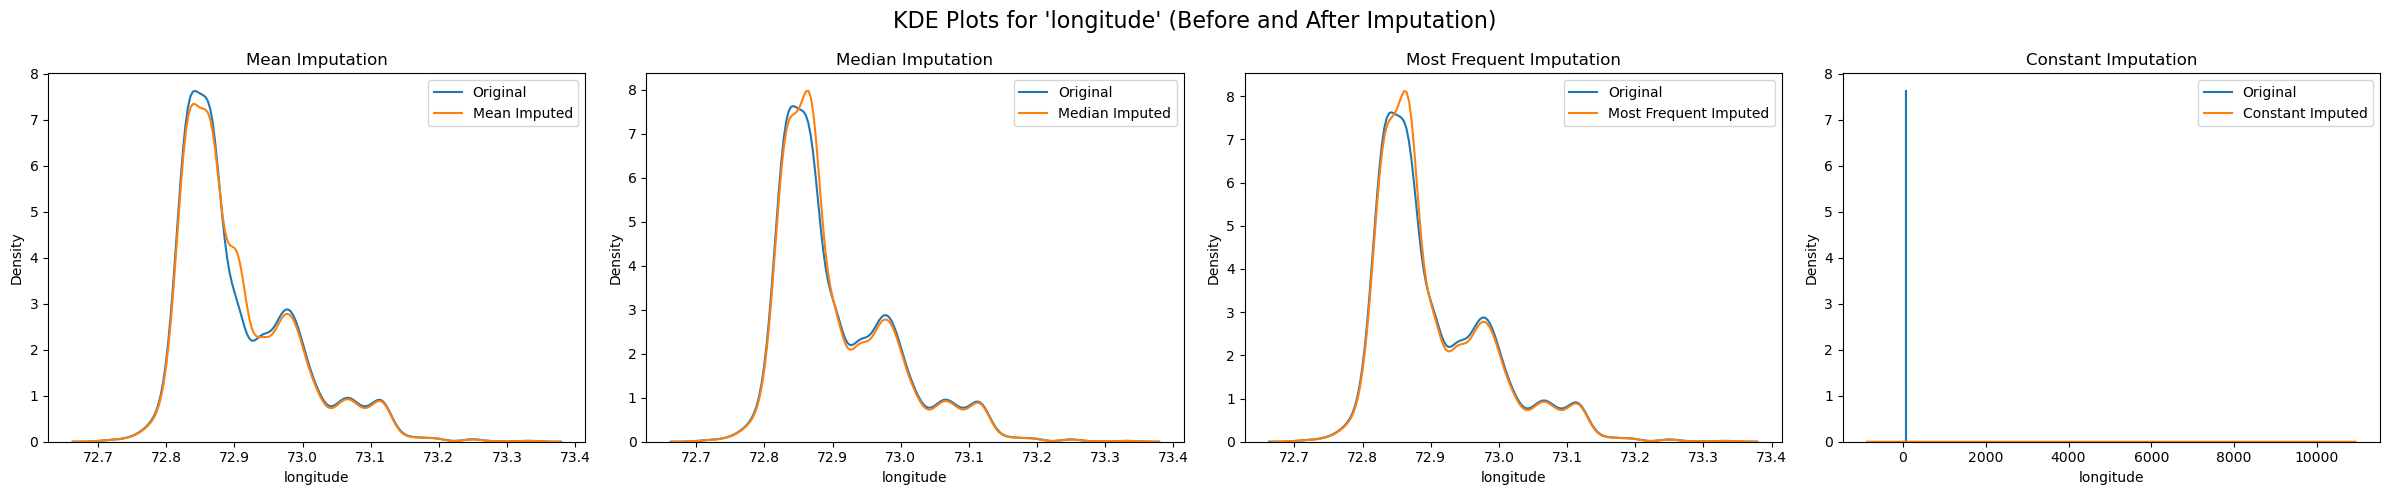

In [47]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'longitude', constant_value=9999)
plot_kde_imputations(X_train, 'longitude')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


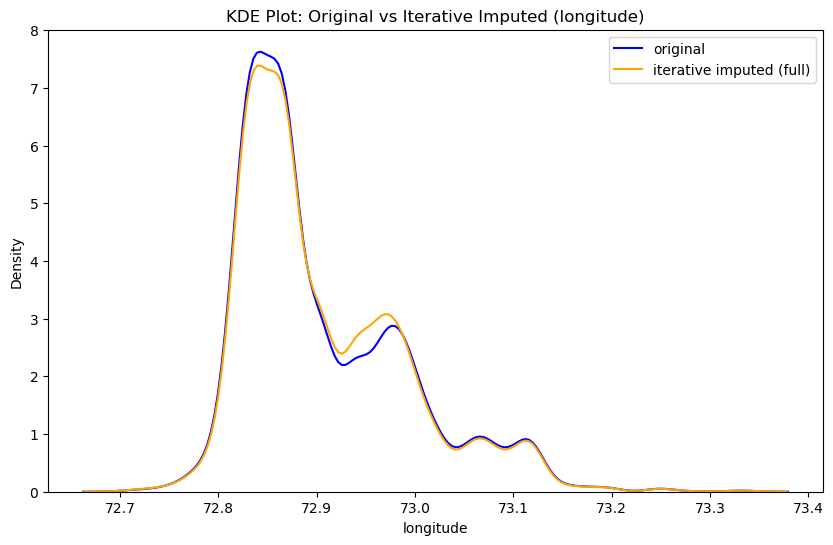

In [48]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'longitude')

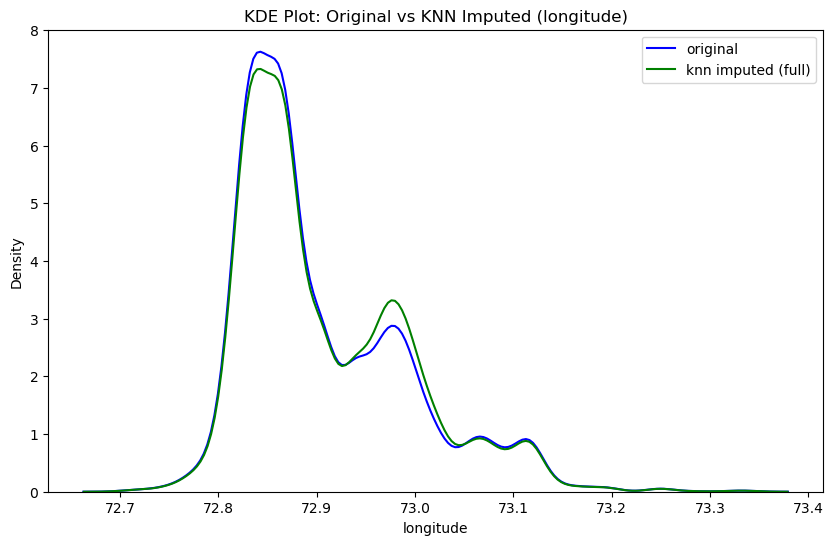

In [49]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'longitude')

In [50]:
print("Original:\n", X_train['longitude'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['longitude'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['longitude'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    8935.000000
mean       72.905286
std         0.086000
min        72.704548
25%        72.839809
50%        72.872695
75%        72.963282
max        73.337269
Name: longitude, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       72.908378
std         0.085793
min        72.704548
25%        72.839809
50%        72.873618
75%        72.968923
max        73.337269
Name: longitude, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       72.906250
std         0.084784
min        72.704548
25%        72.839809
50%        72.873618
75%        72.963171
max        73.337269
Name: longitude, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       72.905286
std         0.084268
min        72.704548
25%        72.839809
50%        72.873618
75%        72.959958
max        73.337269
dtype: float64 

Median Imputed:
 count    9306.000000
mean       72.903987
std         0.084509
min        72.704548
25%        72.839809
50%        72.872695
75%   

`observation`

- both works almost same but iterative is slightly better than KNN  
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### area

In [51]:
describe_and_missing(X_train, 'area')


--- Description for 'area' ---
count     9302.000000
mean       876.107289
std        580.371129
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'area': 4


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

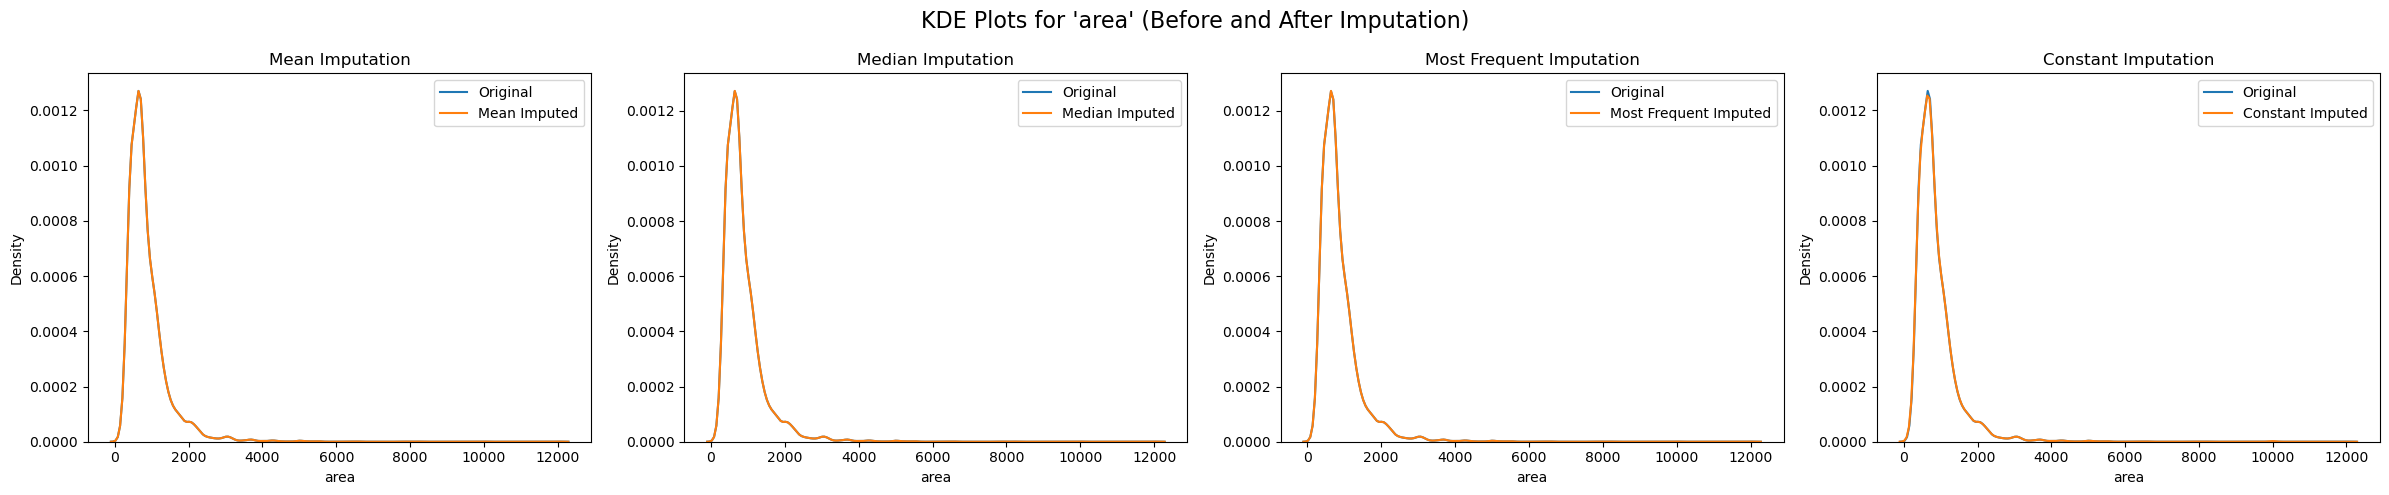

In [52]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'area', constant_value=9999)
plot_kde_imputations(X_train, 'area')

`observation`
- After imputation distribution not change as have very less values in data 
- Still lets use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


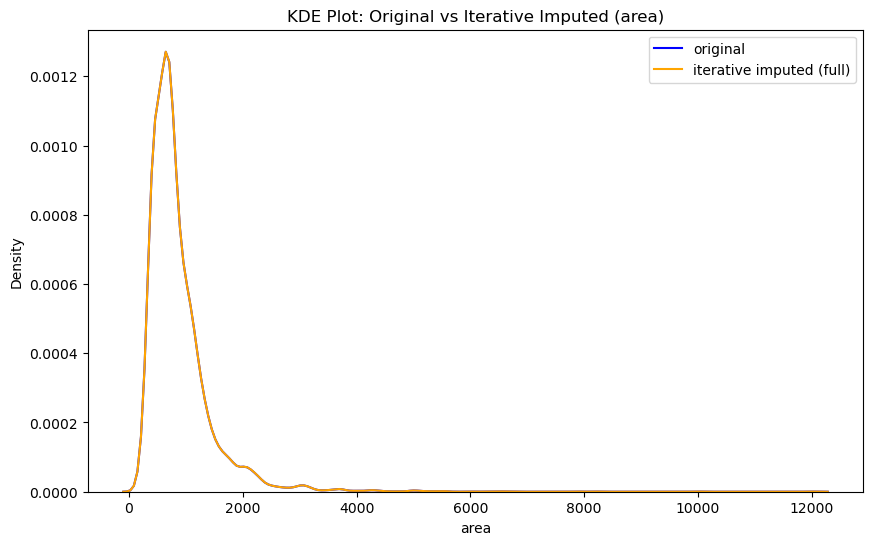

In [53]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'area')

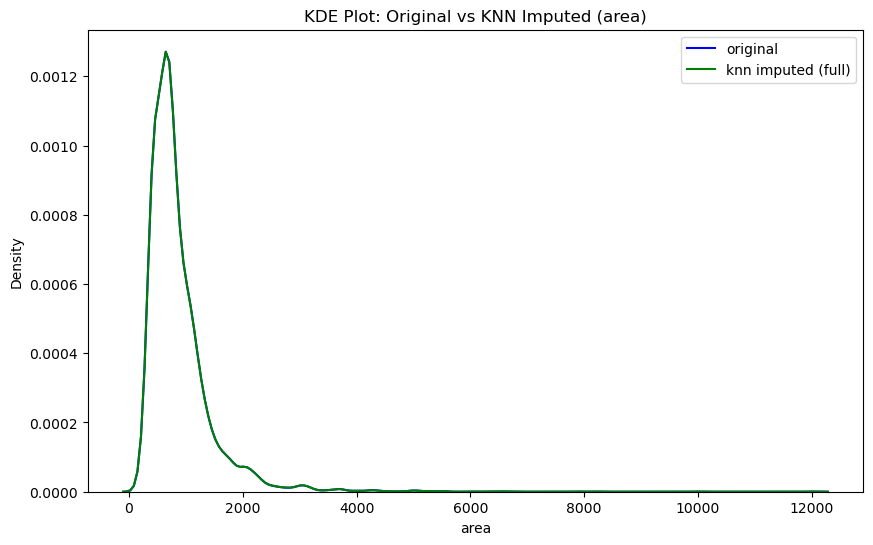

In [54]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'area')

In [55]:
print("Original:\n", X_train['area'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['area'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['area'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count     9302.000000
mean       876.107289
std        580.371129
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64 

KNN Imputed:
 count     9306.000000
mean       876.212315
std        580.537012
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64 

Iterative Imputed:
 count     9306.000000
mean       876.185713
std        580.425224
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64 

Mean Imputed:
 count     9306.000000
mean       876.107289
std        580.246372
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
dtype: float64 

Median Imputed:
 count     9306.000000
mean       876.044487
std        580.254276
min        180.000000
25%        540.000000
50%  

`observation`

- both works almost same but KNN is slightly better than iterative- 
Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### costpersqft

In [56]:
describe_and_missing(X_train, 'costpersqft')


--- Description for 'costpersqft' ---
count      9301.000000
mean      27802.121748
std       16004.552857
min         289.000000
25%       16875.000000
50%       25556.000000
75%       34392.000000
max      138889.000000
Name: costpersqft, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'costpersqft': 5


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

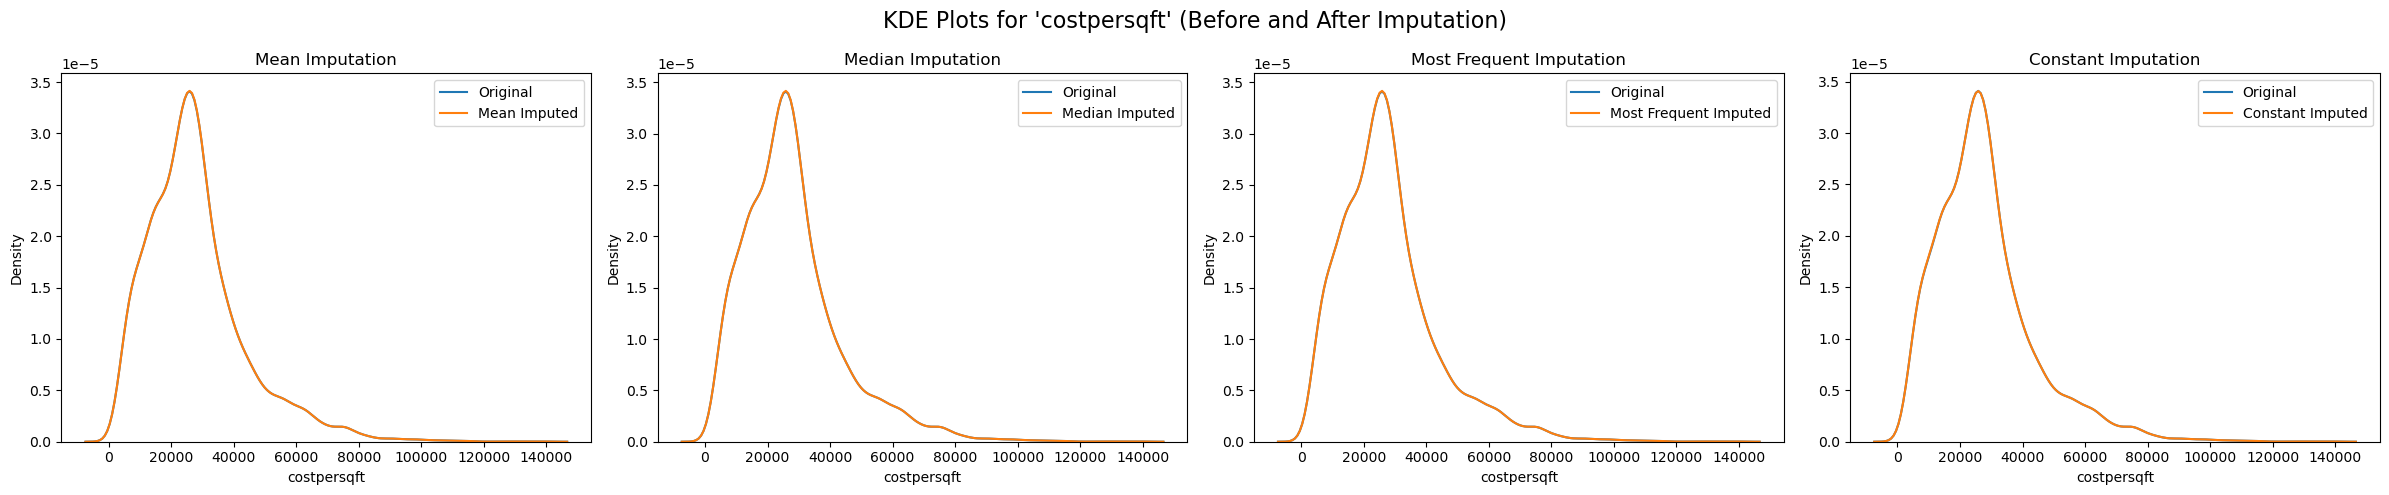

In [57]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'costpersqft', constant_value=9999)
plot_kde_imputations(X_train, 'costpersqft')

`observation`
- After imputation distribution remanin same as have very less values in data
- lets use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


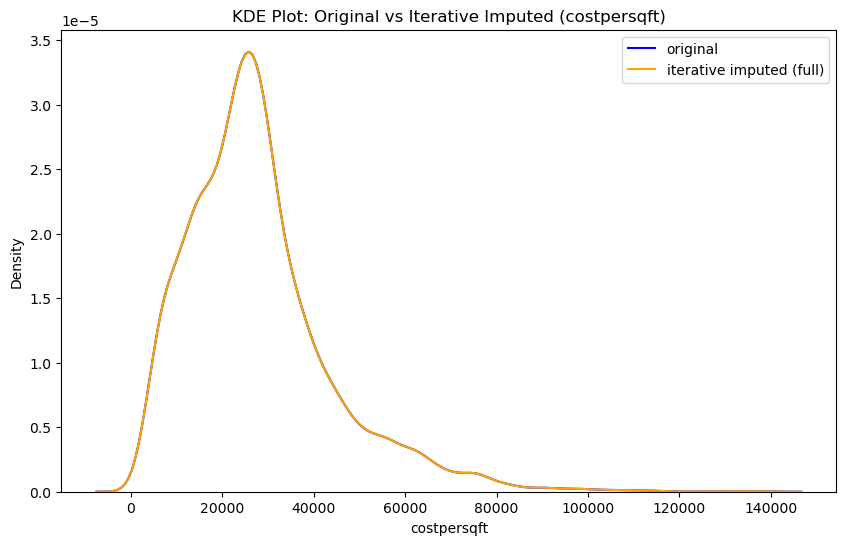

In [58]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'costpersqft')

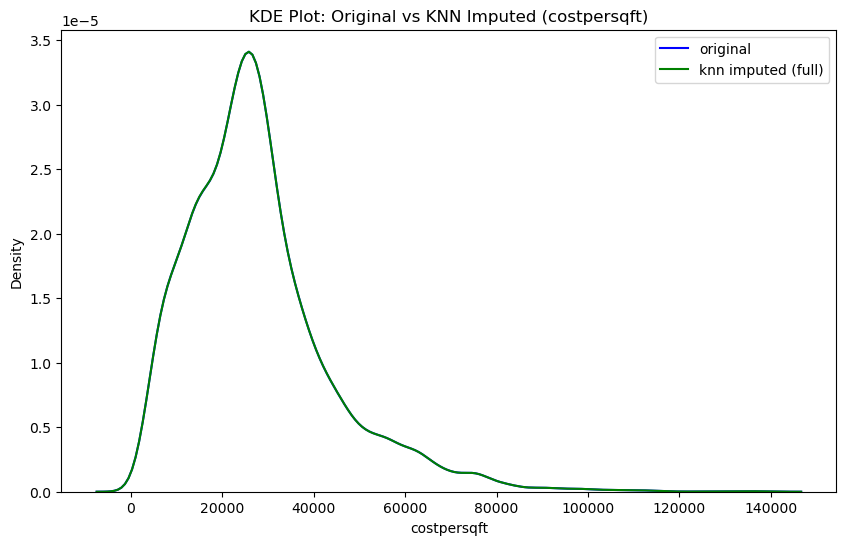

In [59]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'costpersqft')

In [60]:
print("Original:\n", X_train['costpersqft'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['costpersqft'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['costpersqft'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count      9301.000000
mean      27802.121748
std       16004.552857
min         289.000000
25%       16875.000000
50%       25556.000000
75%       34392.000000
max      138889.000000
Name: costpersqft, dtype: float64 

KNN Imputed:
 count      9306.000000
mean      27800.281236
std       16002.385511
min         289.000000
25%       16869.000000
50%       25556.000000
75%       34390.000000
max      138889.000000
Name: costpersqft, dtype: float64 

Iterative Imputed:
 count      9306.000000
mean      27798.880153
std       16004.796477
min         289.000000
25%       16867.000000
50%       25556.000000
75%       34390.000000
max      138889.000000
Name: costpersqft, dtype: float64 

Mean Imputed:
 count      9306.000000
mean      27802.121748
std       16000.252292
min         289.000000
25%       16875.000000
50%       25558.500000
75%       34383.750000
max      138889.000000
dtype: float64 

Median Imputed:
 count      9306.000000
mean      27800.914934
std       16000.

`observation`

- both works almost same but KNN is slightly better than iterative
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### emi

In [61]:
describe_and_missing(X_train, 'emi')


--- Description for 'emi' ---
count    9304.000000
mean        1.321022
std         1.917678
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'emi': 2


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

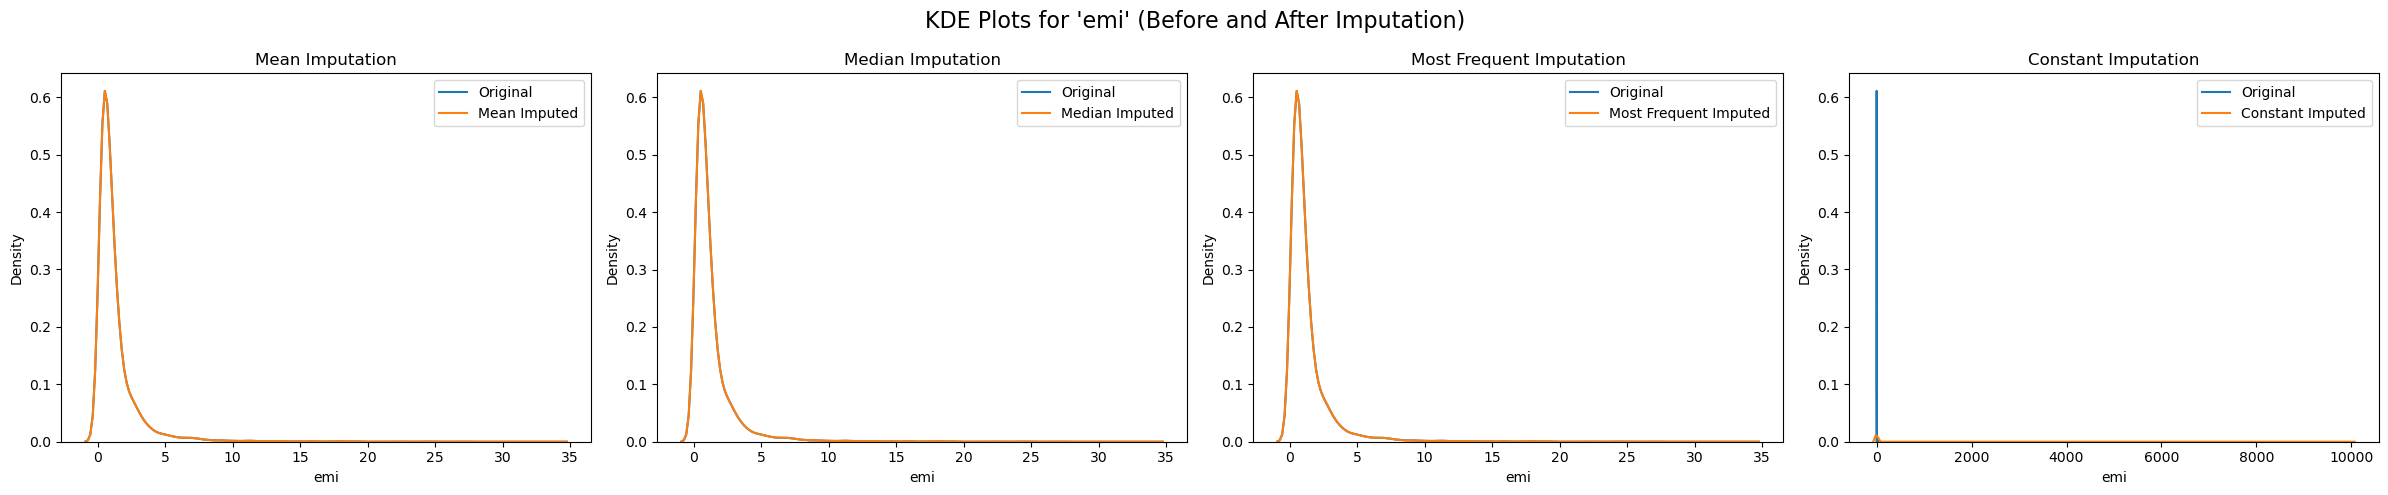

In [62]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'emi', constant_value=9999)
plot_kde_imputations(X_train, 'emi')

`observation`
- After imputation distribution remain same as have very less values in data 
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


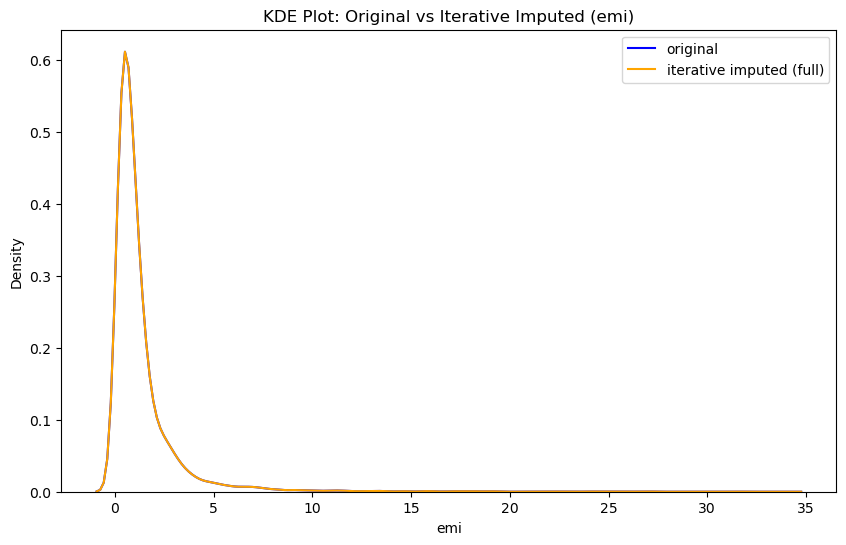

In [63]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'emi')

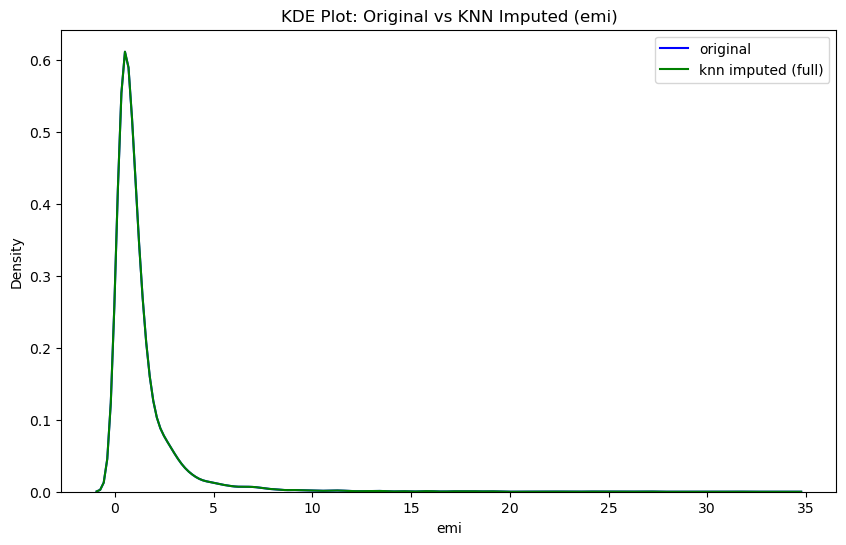

In [64]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'emi')

In [65]:
print("Original:\n", X_train['emi'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['emi'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['emi'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    9304.000000
mean        1.321022
std         1.917678
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.320901
std         1.917495
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.320896
std         1.917500
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.321022
std         1.917472
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.320910
std         1.917487
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max

`observation`

- mean, iterative and KNN works almost same but KNN is slightly better than others
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### education_mean_km

In [66]:
describe_and_missing(X_train, 'education_mean_km')


--- Description for 'education_mean_km' ---
count    5922.000000
mean        7.901789
std        14.835780
min         0.100000
25%         1.740000
50%         3.040000
75%         5.050000
max        66.350000
Name: education_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'education_mean_km': 3384


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

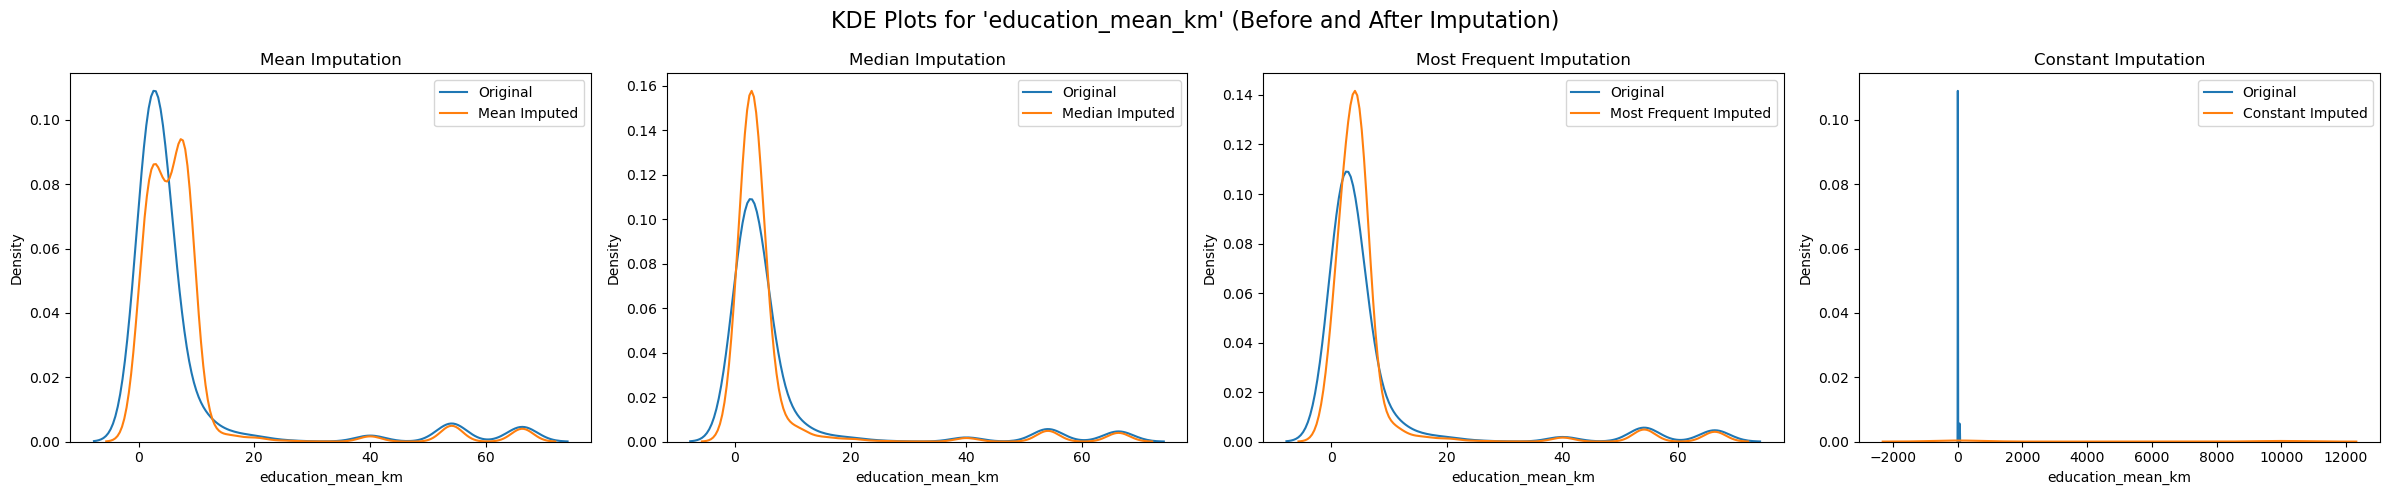

In [67]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'education_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'education_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


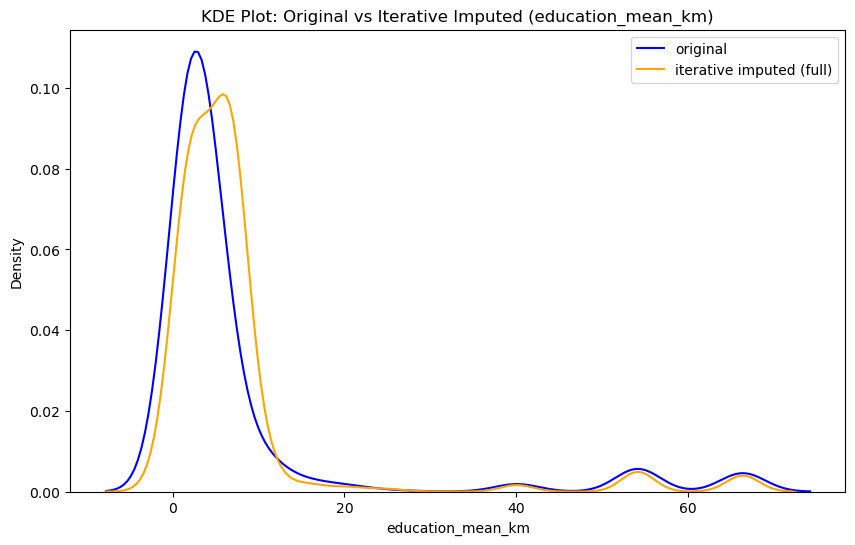

In [68]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'education_mean_km')

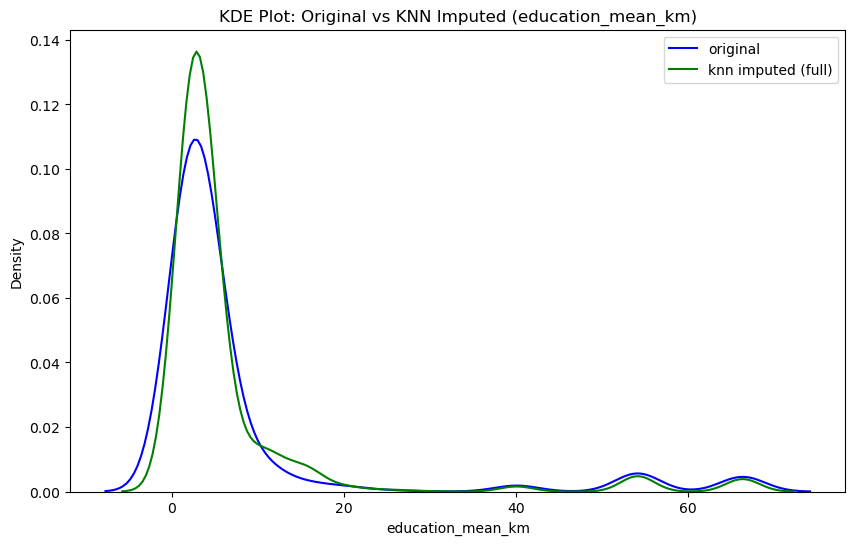

In [69]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'education_mean_km')

In [70]:
print("Original:\n", X_train['education_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['education_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['education_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5922.000000
mean        7.901789
std        14.835780
min         0.100000
25%         1.740000
50%         3.040000
75%         5.050000
max        66.350000
Name: education_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        6.916881
std        12.192428
min         0.100000
25%         2.166667
50%         3.131333
75%         5.019000
max        66.350000
Name: education_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        7.484756
std        11.932328
min        -2.045053
25%         2.166667
50%         5.050000
75%         7.072587
max        66.350000
Name: education_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        7.901789
std        11.834495
min         0.100000
25%         2.250000
50%         5.100000
75%         7.901789
max        66.350000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        6.133866
std        12.063398
min         0.100000
25%         2.250000
50%

`observation`

- KNN and median works well but KNN is slightly better
- KNN distribution is also not have exact match still as it is better than other hence try KNN 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### education_min_km

In [71]:
describe_and_missing(X_train, 'education_min_km')


--- Description for 'education_min_km' ---
count    5922.000000
mean        2.390713
std         4.960103
min         0.100000
25%         0.500000
50%         0.800000
75%         1.400000
max        39.400000
Name: education_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'education_min_km': 3384


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

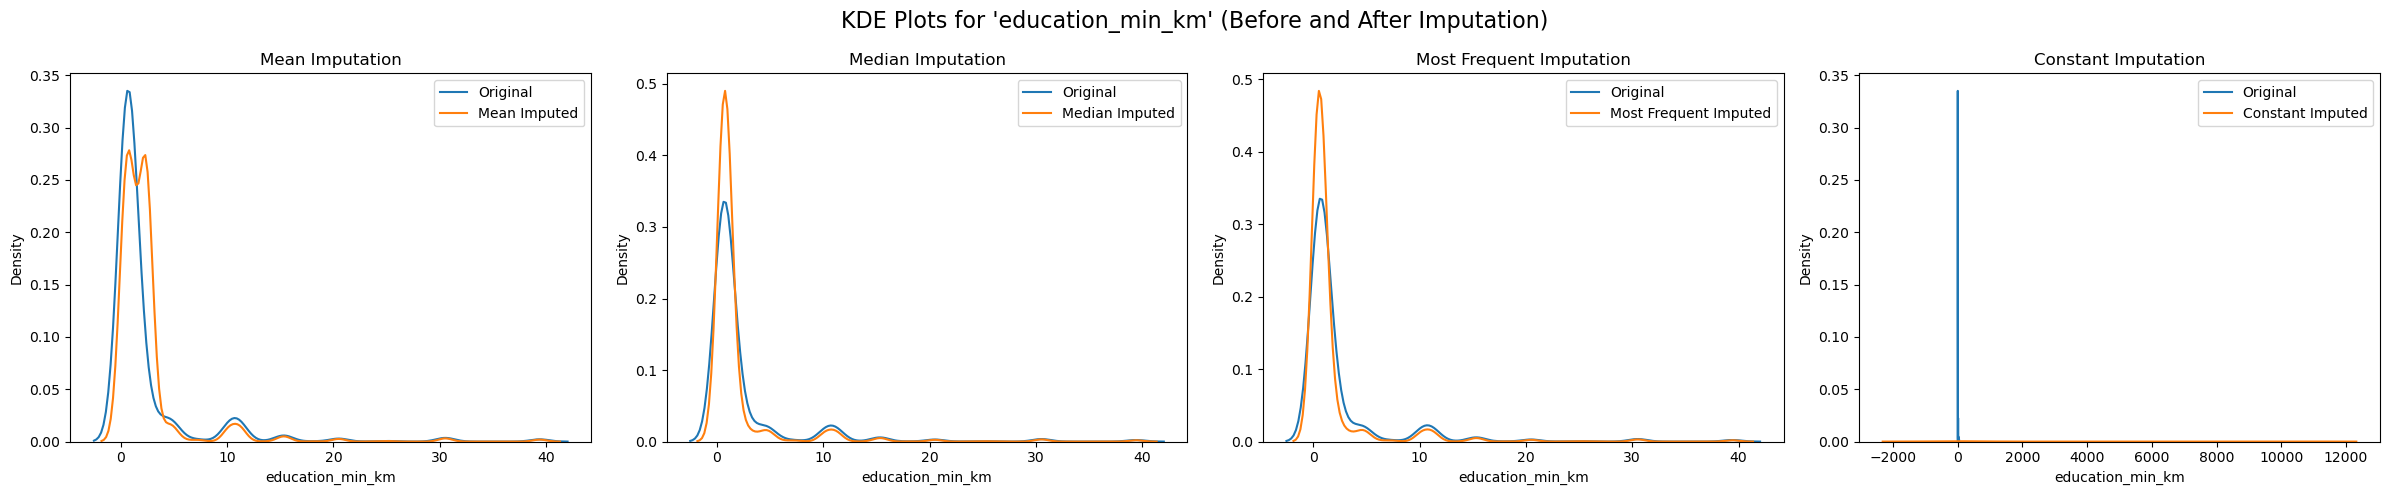

In [72]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'education_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'education_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


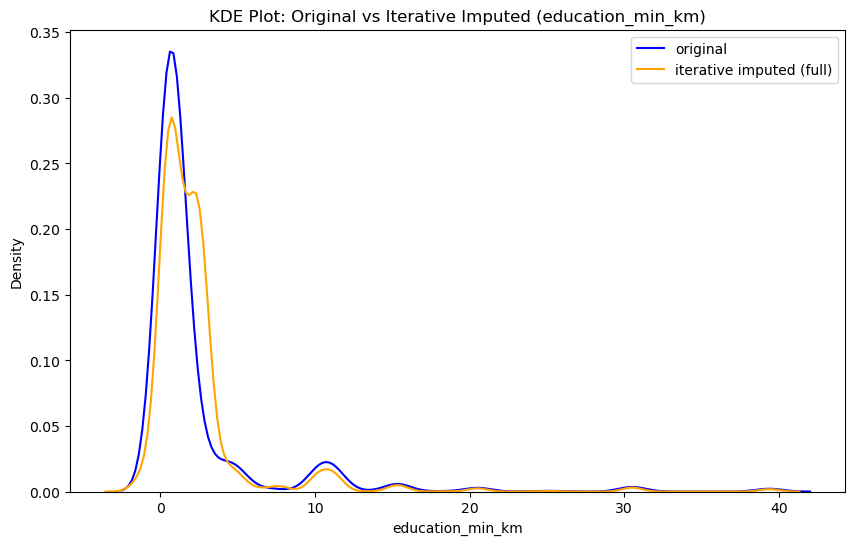

In [73]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'education_min_km')

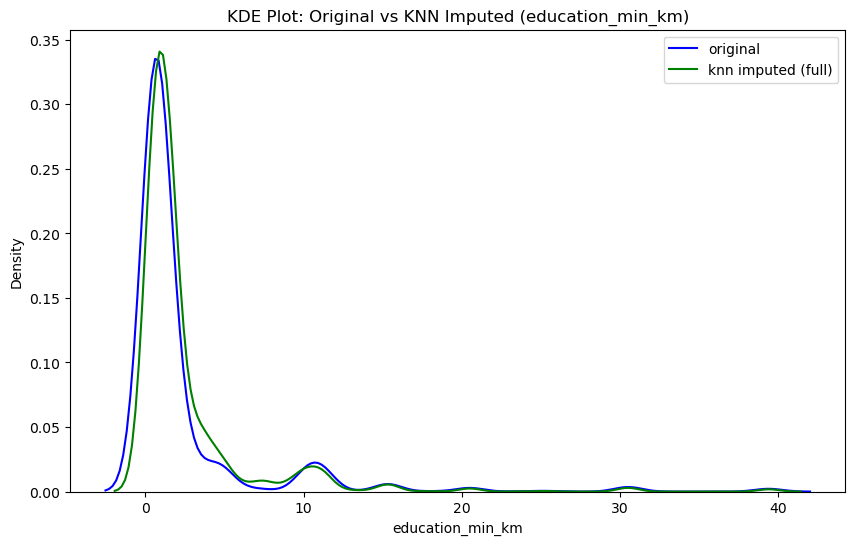

In [74]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'education_min_km')

In [75]:
print("Original:\n", X_train['education_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['education_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['education_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5922.000000
mean        2.390713
std         4.960103
min         0.100000
25%         0.500000
50%         0.800000
75%         1.400000
max        39.400000
Name: education_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.521685
std         4.221818
min         0.100000
25%         0.600000
50%         1.320000
75%         2.100000
max        39.400000
Name: education_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.354348
std         4.020792
min        -1.614666
25%         0.525000
50%         1.300000
75%         2.485001
max        39.400000
Name: education_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.390713
std         3.956672
min         0.100000
25%         0.600000
50%         1.900000
75%         2.390713
max        39.400000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.812272
std         4.029994
min         0.100000
25%         0.600000
50%   

`observation`

- median and KNN works almost same but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### transport_mean_km

In [76]:
describe_and_missing(X_train, 'transport_mean_km')


--- Description for 'transport_mean_km' ---
count    4351.000000
mean        3.875422
std         5.149028
min         0.000100
25%         1.400000
50%         2.450000
75%         4.600000
max        57.700000
Name: transport_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'transport_mean_km': 4955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

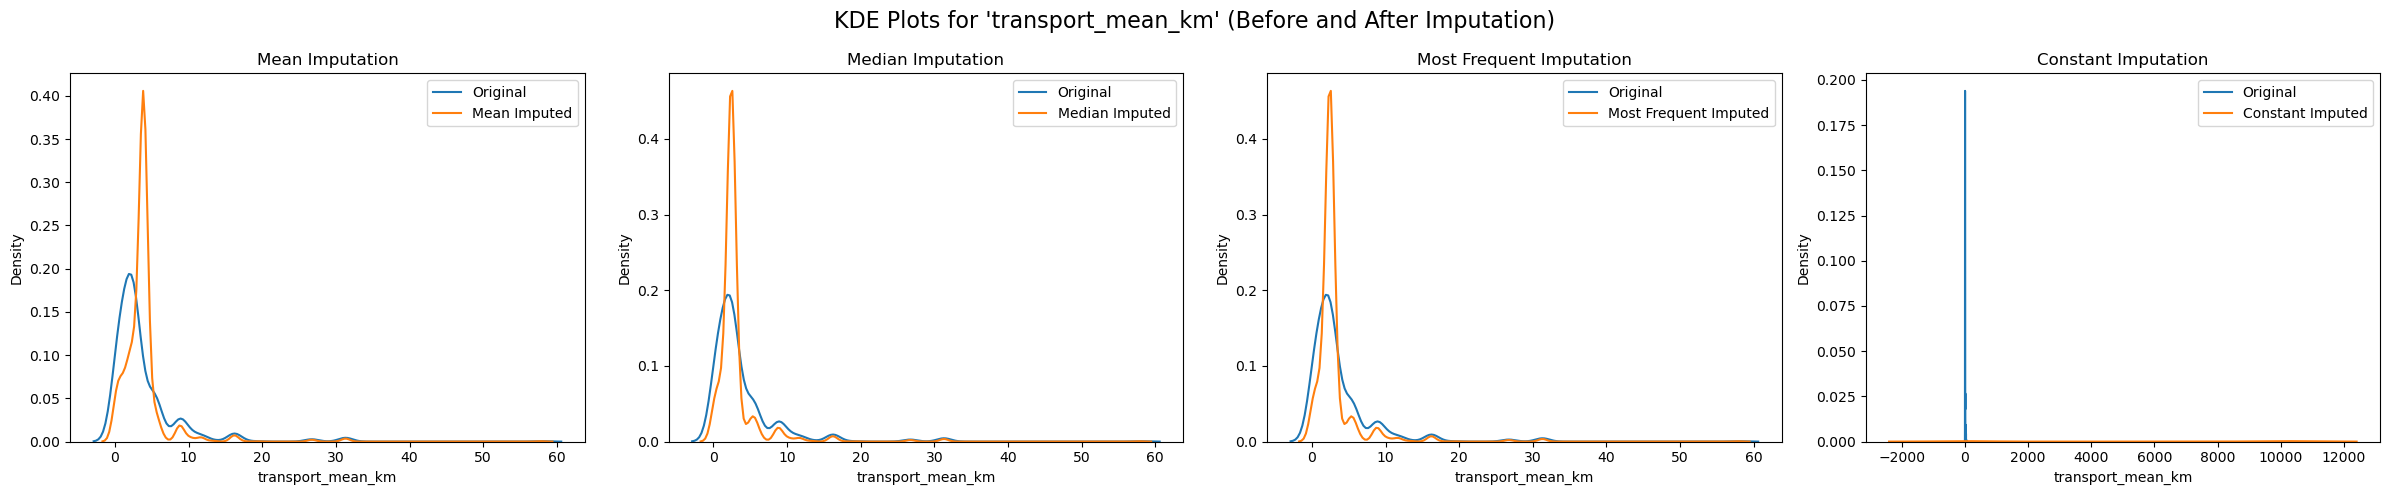

In [77]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'transport_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'transport_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


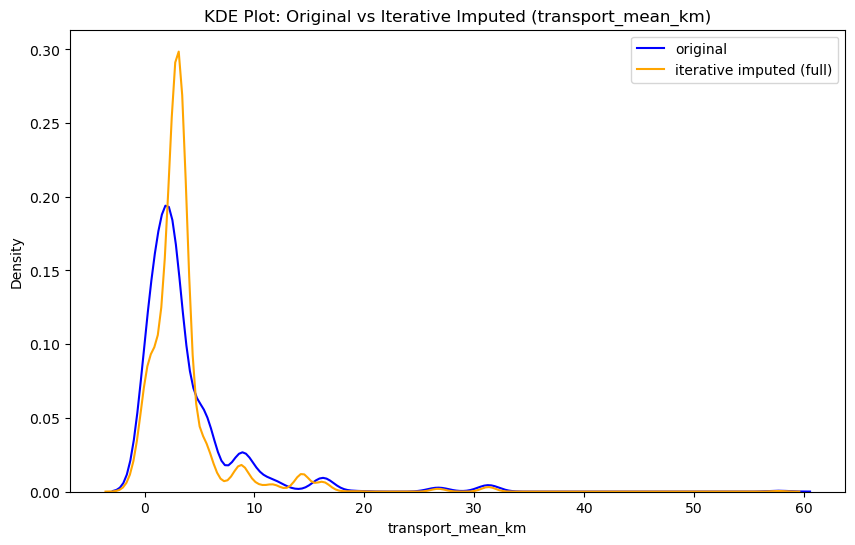

In [78]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'transport_mean_km')

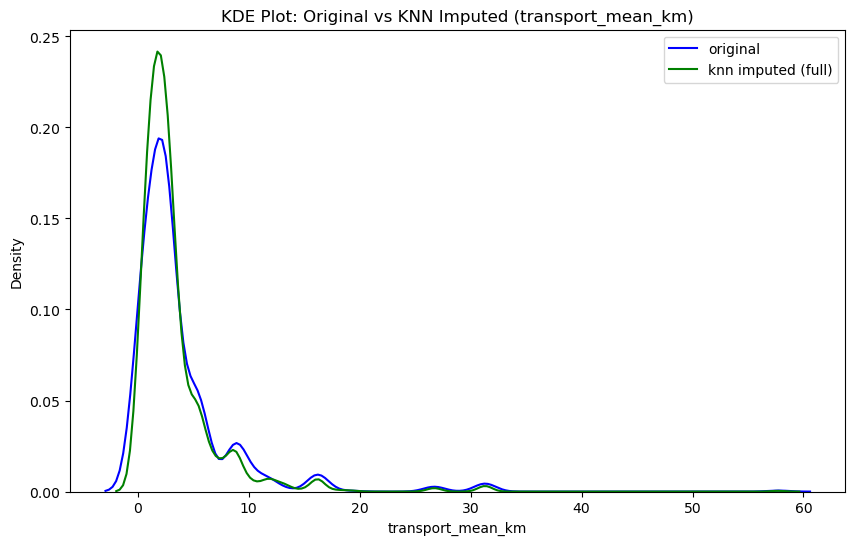

In [79]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'transport_mean_km')

In [80]:
print("Original:\n", X_train['transport_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['transport_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['transport_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4351.000000
mean        3.875422
std         5.149028
min         0.000100
25%         1.400000
50%         2.450000
75%         4.600000
max        57.700000
Name: transport_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        3.354147
std         3.993477
min         0.000100
25%         1.400000
50%         2.386856
75%         3.696269
max        57.700000
Name: transport_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        3.573229
std         3.970974
min        -1.641944
25%         1.900000
50%         2.965515
75%         3.529514
max        57.700000
Name: transport_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        3.875422
std         3.520559
min         0.000100
25%         2.600000
50%         3.875422
75%         3.875422
max        57.700000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.116453
std         3.591686
min         0.000100
25%         2.450000
50%

`observation`

- KNN is better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### transport_min_km

In [81]:
describe_and_missing(X_train, 'transport_min_km')


--- Description for 'transport_min_km' ---
count    4351.000000
mean        2.260324
std         3.779435
min         0.000100
25%         0.400000
50%         1.400000
75%         1.900000
max        57.700000
Name: transport_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'transport_min_km': 4955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

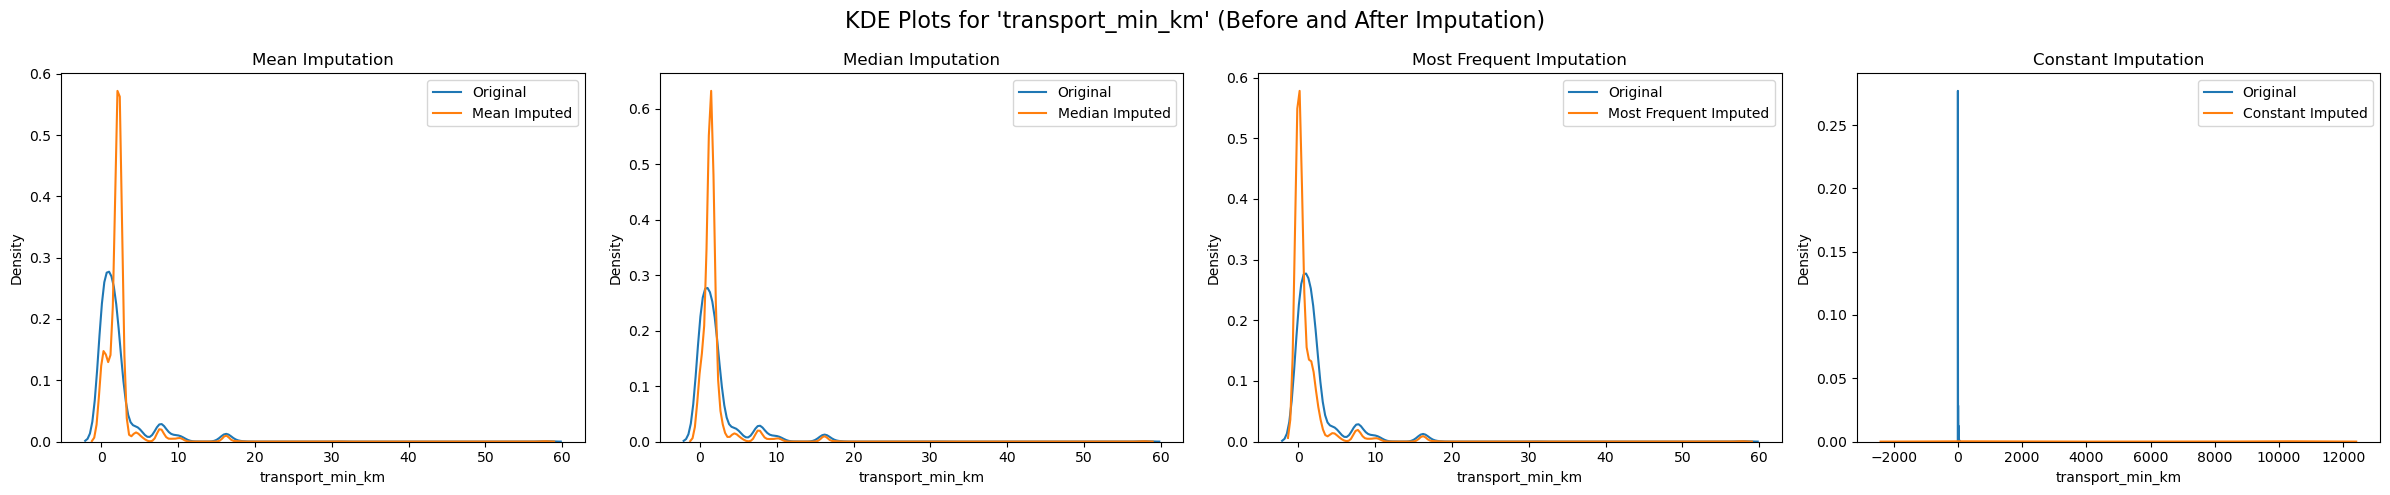

In [82]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'transport_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'transport_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


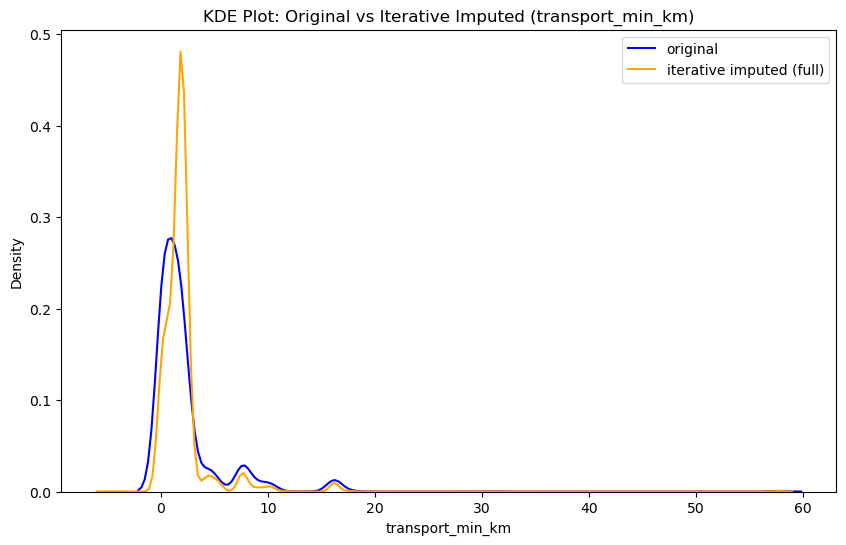

In [83]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'transport_min_km')

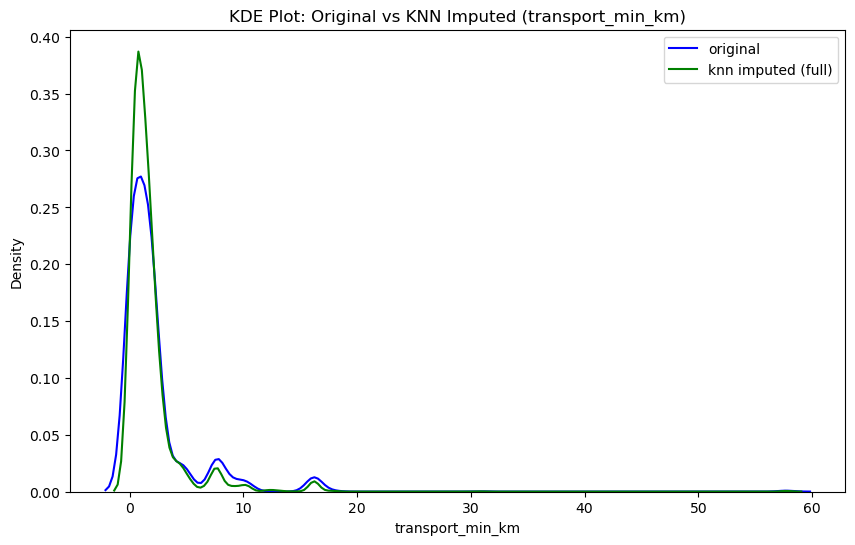

In [84]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'transport_min_km')

In [85]:
print("Original:\n", X_train['transport_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['transport_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['transport_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4351.000000
mean        2.260324
std         3.779435
min         0.000100
25%         0.400000
50%         1.400000
75%         1.900000
max        57.700000
Name: transport_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.843073
std         2.811844
min         0.000100
25%         0.600040
50%         1.140020
75%         1.900000
max        57.700000
Name: transport_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.078171
std         2.640043
min        -4.717609
25%         1.124573
50%         1.820740
75%         2.158404
max        57.700000
Name: transport_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.260324
std         2.584124
min         0.000100
25%         1.600000
50%         2.260324
75%         2.260324
max        57.700000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.802243
std         2.619537
min         0.000100
25%         1.400000
50%   

`observation`

- KNN and median works well but KNN is slightly better than median
- KNN also changes the diastribution and hence use some other ways in next experiments 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### shopping_centre_mean_km

In [86]:
describe_and_missing(X_train, 'shopping_centre_mean_km')


--- Description for 'shopping_centre_mean_km' ---
count    6212.000000
mean        3.381102
std         3.592412
min         0.100000
25%         1.450000
50%         2.260020
75%         4.200000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'shopping_centre_mean_km': 3094


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

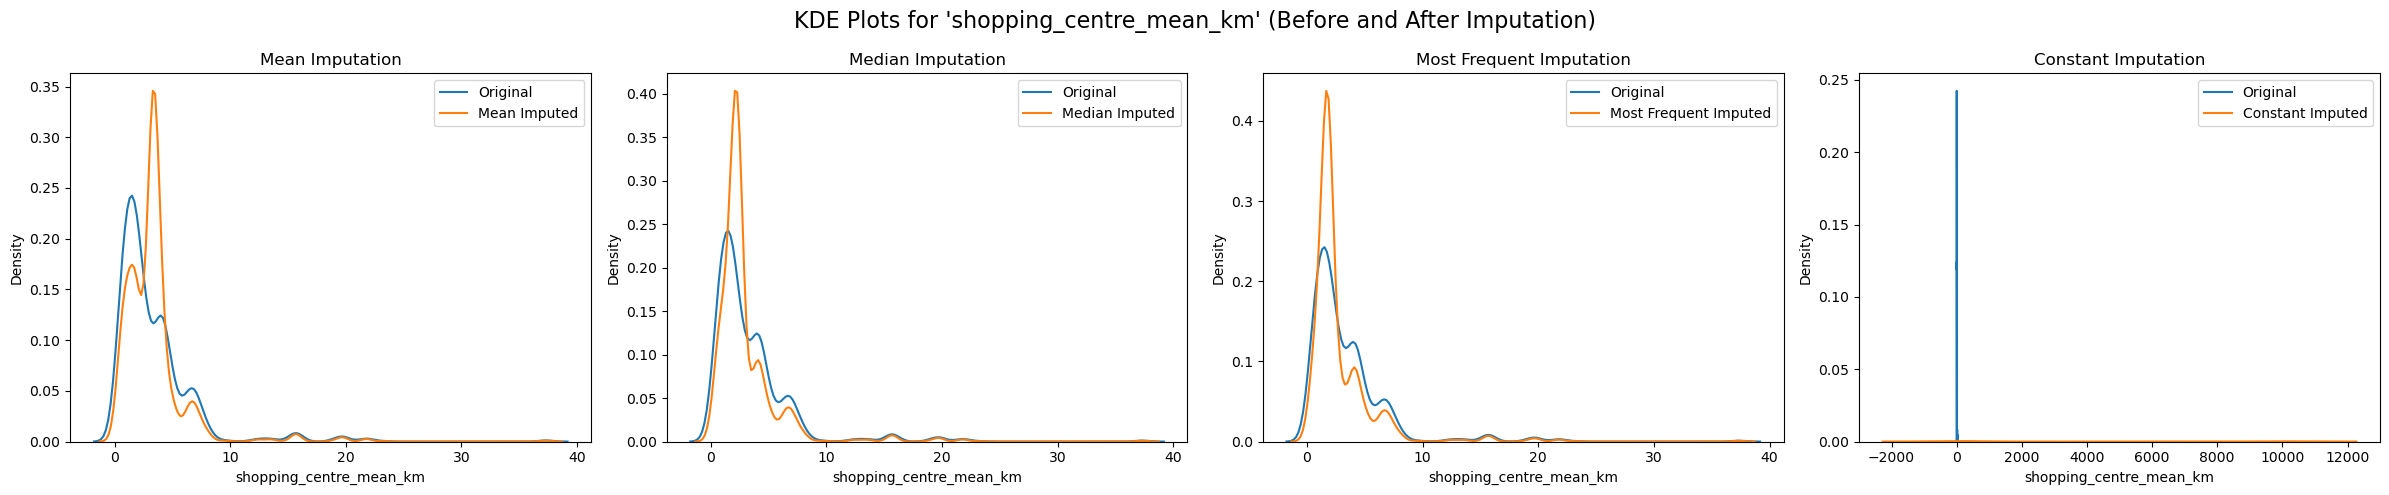

In [87]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'shopping_centre_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'shopping_centre_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


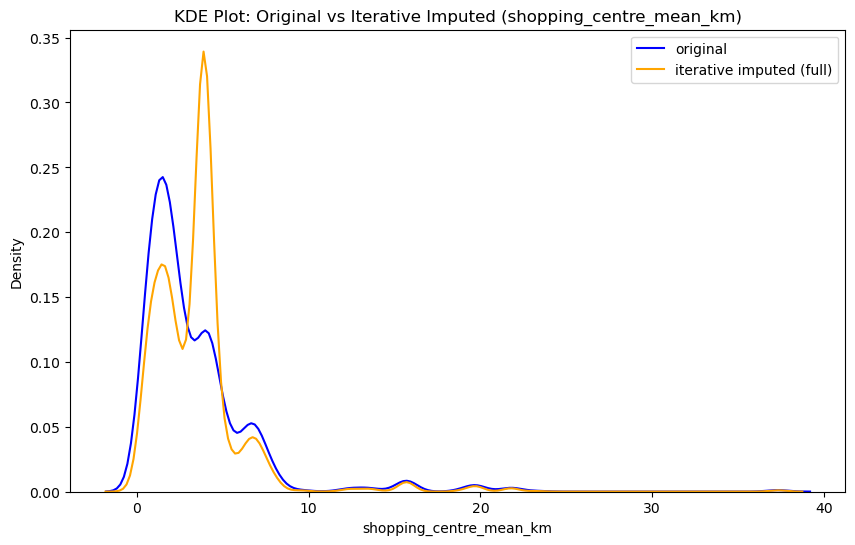

In [88]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'shopping_centre_mean_km')

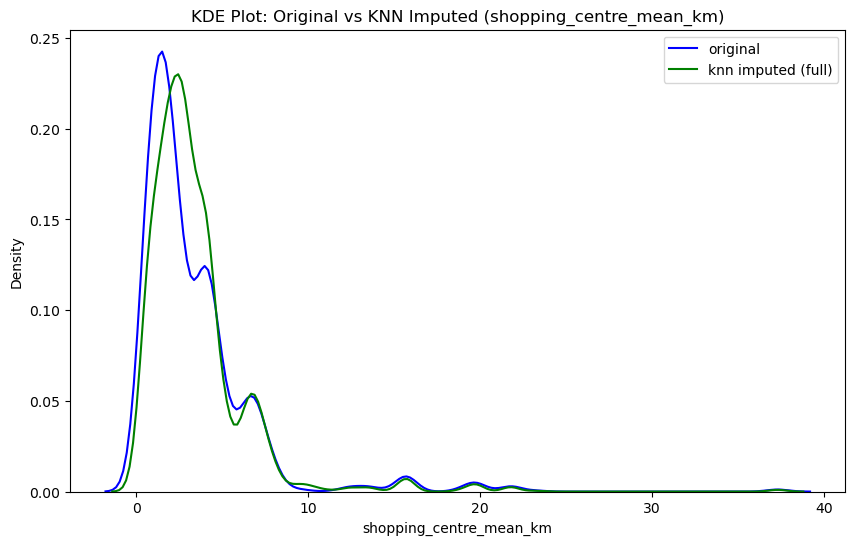

In [89]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'shopping_centre_mean_km')

In [90]:
print("Original:\n", X_train['shopping_centre_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['shopping_centre_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['shopping_centre_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6212.000000
mean        3.381102
std         3.592412
min         0.100000
25%         1.450000
50%         2.260020
75%         4.200000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        3.464465
std         3.087976
min         0.100000
25%         1.760000
50%         2.820000
75%         4.120000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        3.558167
std         2.965783
min        -0.387348
25%         1.760000
50%         3.740952
75%         4.040000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        3.381102
std         2.935004
min         0.100000
25%         1.760000
50%         3.381102
75%         3.460000
max        37.300000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.008372
std         2.982149
min         0.100000
25%   

`observation`

- both median and KNN works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### shopping_centre_min_km

In [91]:
describe_and_missing(X_train, 'shopping_centre_min_km')


--- Description for 'shopping_centre_min_km' ---
count    6212.000000
mean        1.474845
std         2.578839
min         0.000100
25%         0.400000
50%         0.900000
75%         1.900000
max        37.300000
Name: shopping_centre_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'shopping_centre_min_km': 3094


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

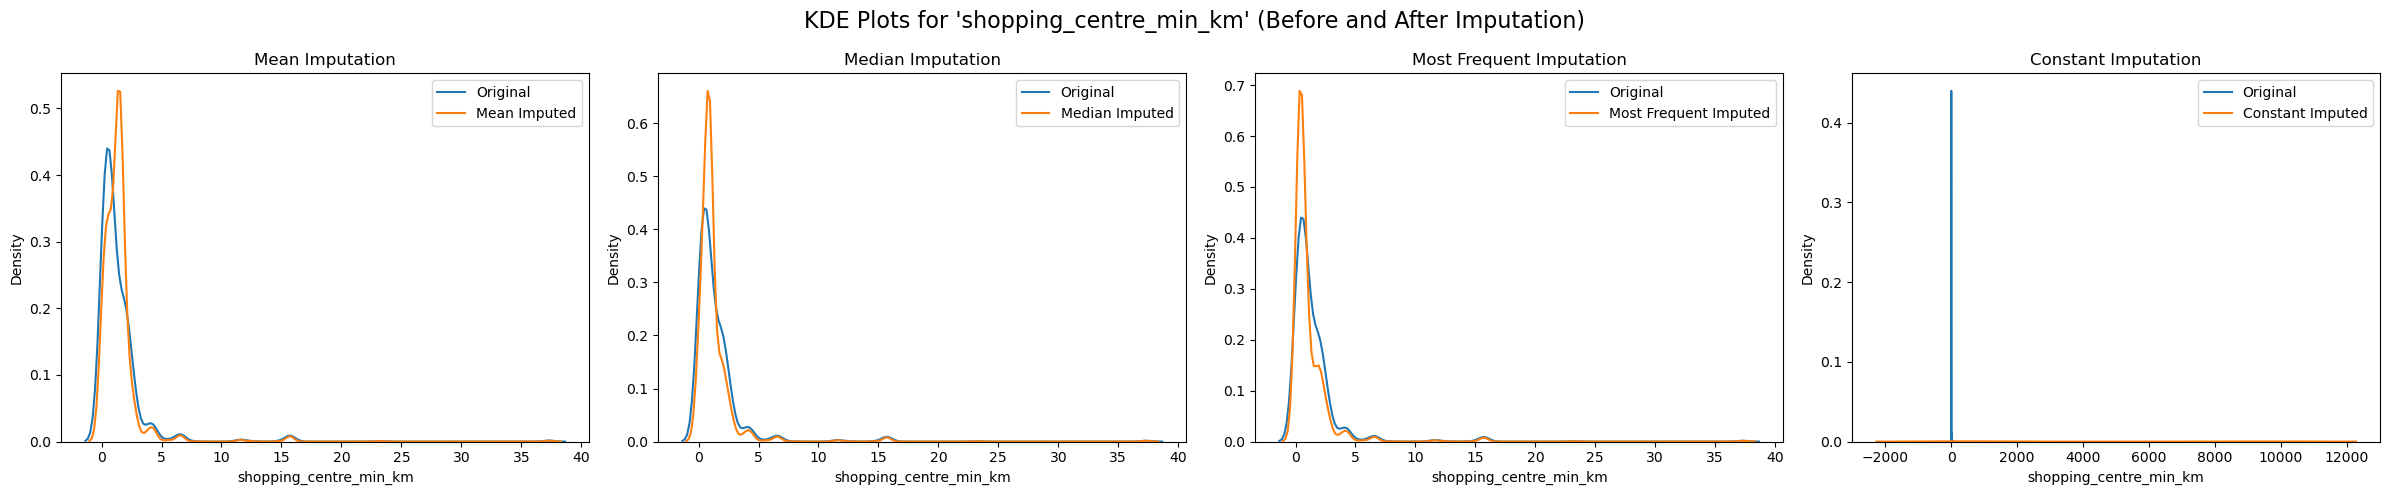

In [92]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'shopping_centre_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'shopping_centre_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


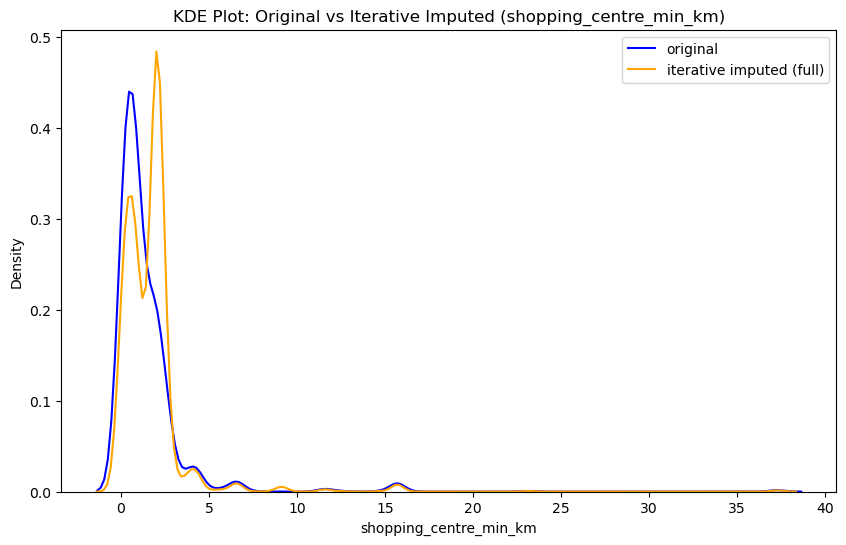

In [93]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'shopping_centre_min_km')

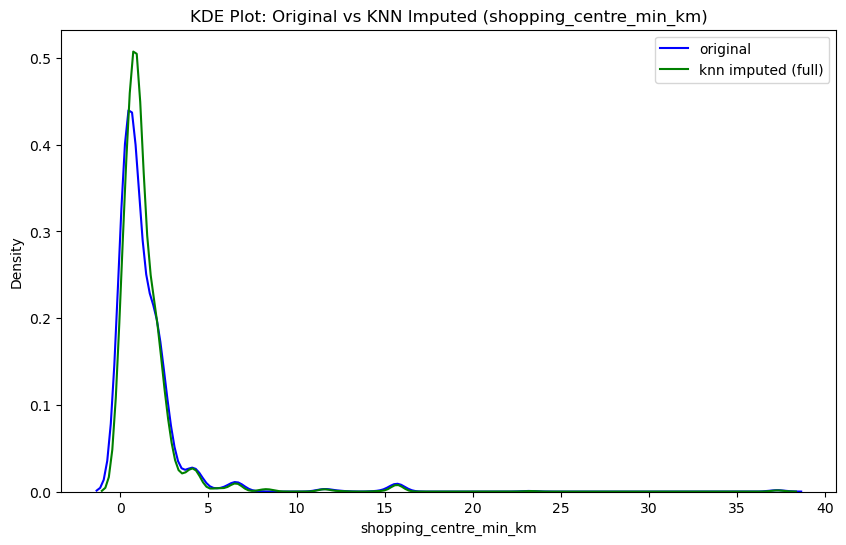

In [94]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'shopping_centre_min_km')

In [95]:
print("Original:\n", X_train['shopping_centre_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['shopping_centre_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['shopping_centre_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6212.000000
mean        1.474845
std         2.578839
min         0.000100
25%         0.400000
50%         0.900000
75%         1.900000
max        37.300000
Name: shopping_centre_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.436872
std         2.181324
min         0.000100
25%         0.600000
50%         1.000000
75%         1.800000
max        37.300000
Name: shopping_centre_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.712089
std         2.193145
min        -0.323836
25%         0.600000
50%         1.800000
75%         2.111274
max        37.300000
Name: shopping_centre_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.474845
std         2.106914
min         0.000100
25%         0.600000
50%         1.474845
75%         1.474845
max        37.300000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.283724
std         2.124249
min         0.000100
25%      

`observation`

- both median and KNN works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### commercial_hub_mean_km

In [96]:
describe_and_missing(X_train, 'commercial_hub_mean_km')


--- Description for 'commercial_hub_mean_km' ---
count    5250.000000
mean        6.861918
std         7.138121
min         0.100000
25%         2.840000
50%         4.566667
75%         7.260000
max        48.100000
Name: commercial_hub_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'commercial_hub_mean_km': 4056


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

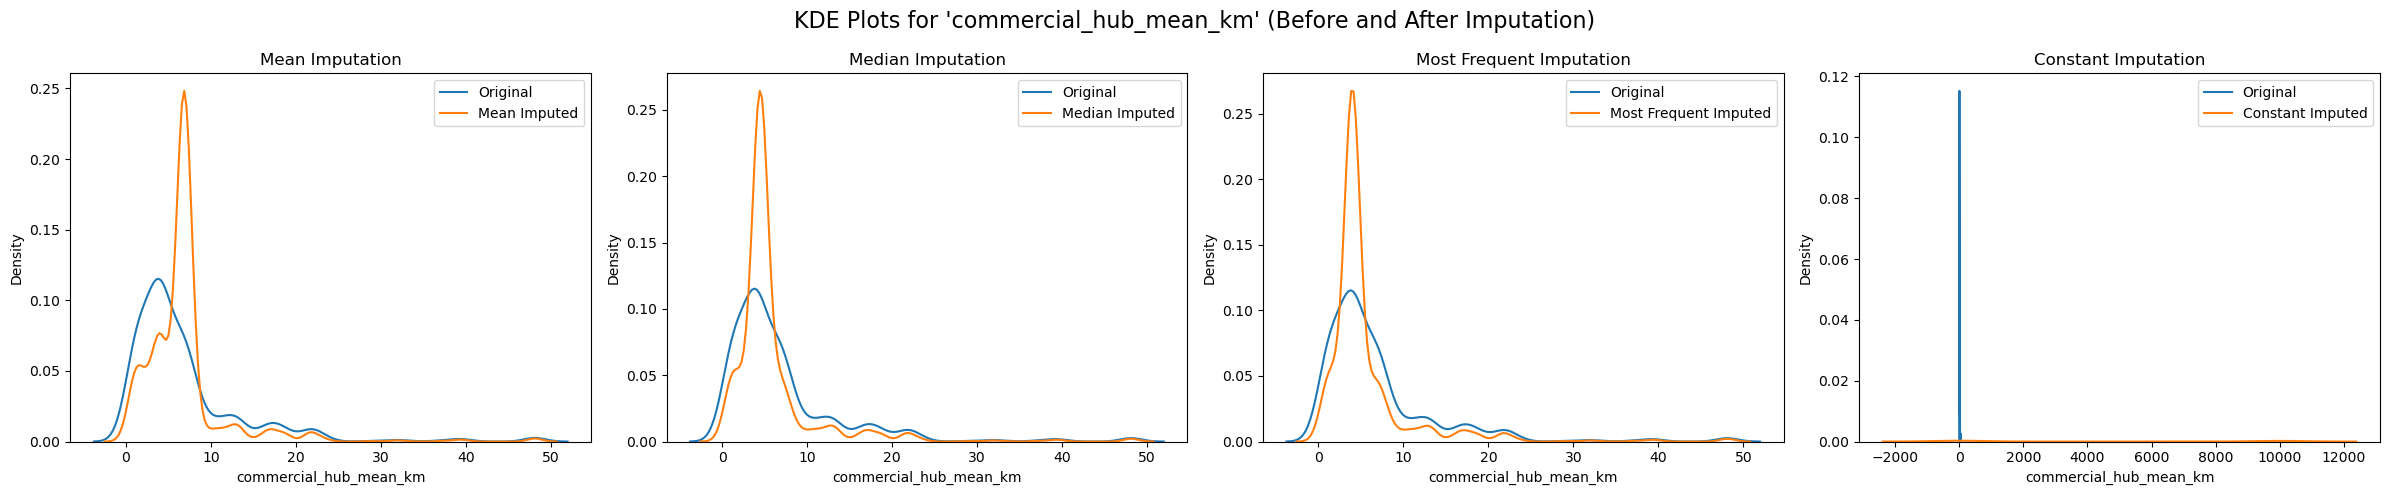

In [97]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'commercial_hub_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'commercial_hub_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


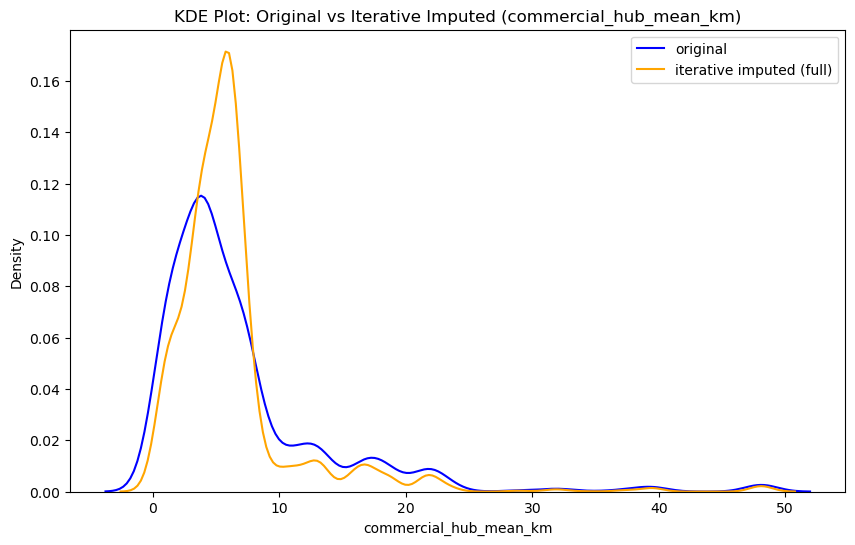

In [98]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'commercial_hub_mean_km')

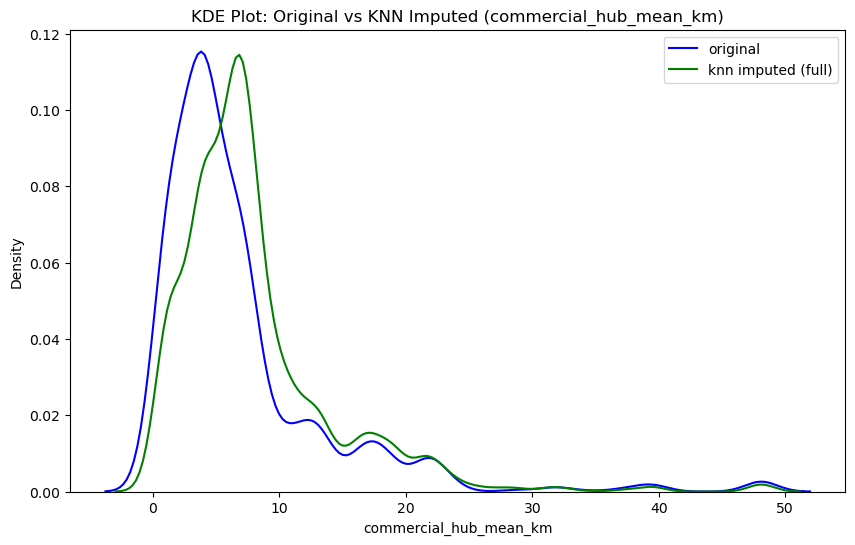

In [99]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'commercial_hub_mean_km')

In [100]:
print("Original:\n", X_train['commercial_hub_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['commercial_hub_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['commercial_hub_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5250.000000
mean        6.861918
std         7.138121
min         0.100000
25%         2.840000
50%         4.566667
75%         7.260000
max        48.100000
Name: commercial_hub_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        8.004867
std         6.375024
min         0.100000
25%         4.033333
50%         6.774500
75%         9.477333
max        48.100000
Name: commercial_hub_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        6.296043
std         5.535474
min         0.100000
25%         3.760000
50%         5.671346
75%         6.672874
max        48.100000
Name: commercial_hub_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        6.861918
std         5.361225
min         0.100000
25%         4.060000
50%         6.861918
75%         6.861918
max        48.100000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        5.861538
std         5.480715
min         0.100000
25%      

`observation`

- both Iterative and Median works well but KNN is better
- slight shift using KNN so try other approaches also in next experiments else KNN is fine here 

### commercial_hub_min_km

In [101]:
describe_and_missing(X_train, 'commercial_hub_min_km')


--- Description for 'commercial_hub_min_km' ---
count    5250.000000
mean        4.609031
std         6.938345
min         0.000100
25%         1.000000
50%         2.100000
75%         5.600000
max        48.100000
Name: commercial_hub_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'commercial_hub_min_km': 4056


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

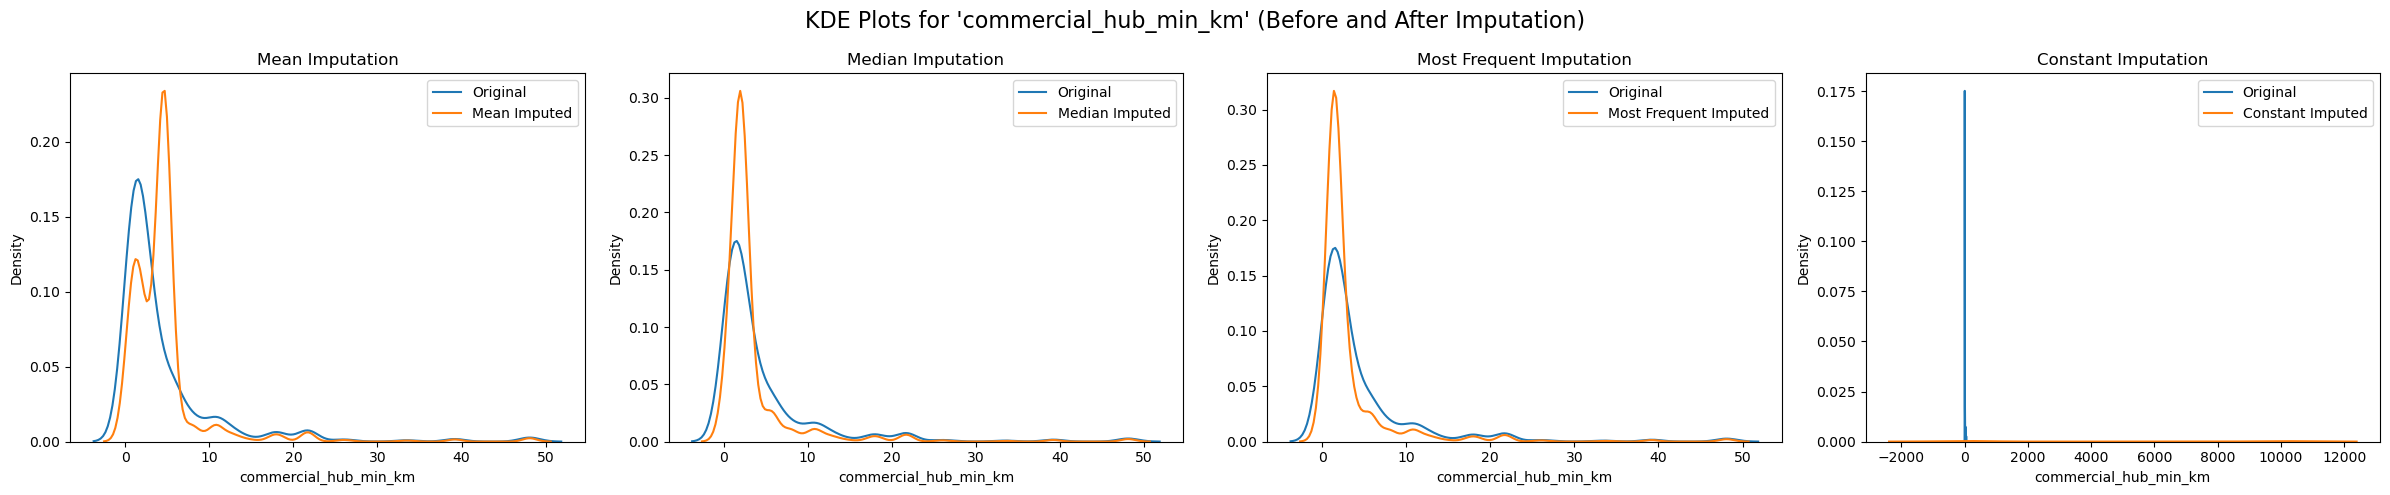

In [102]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'commercial_hub_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'commercial_hub_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


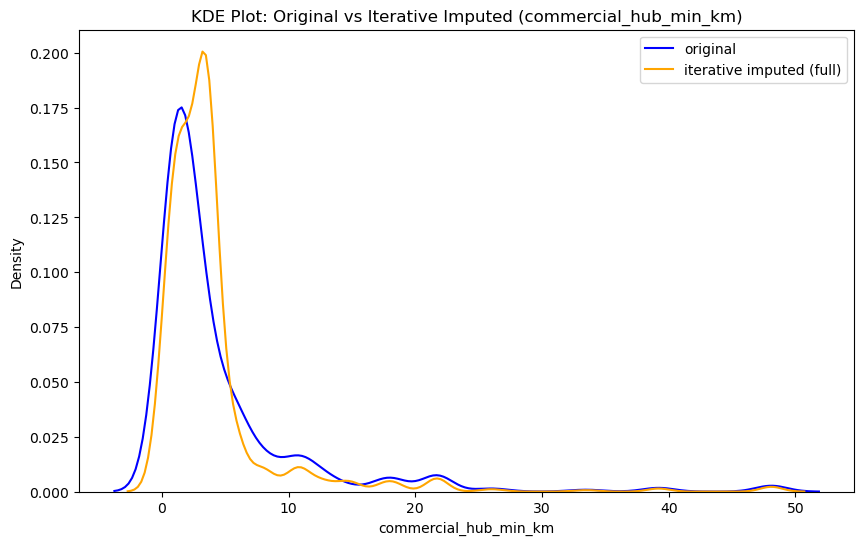

In [103]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'commercial_hub_min_km')

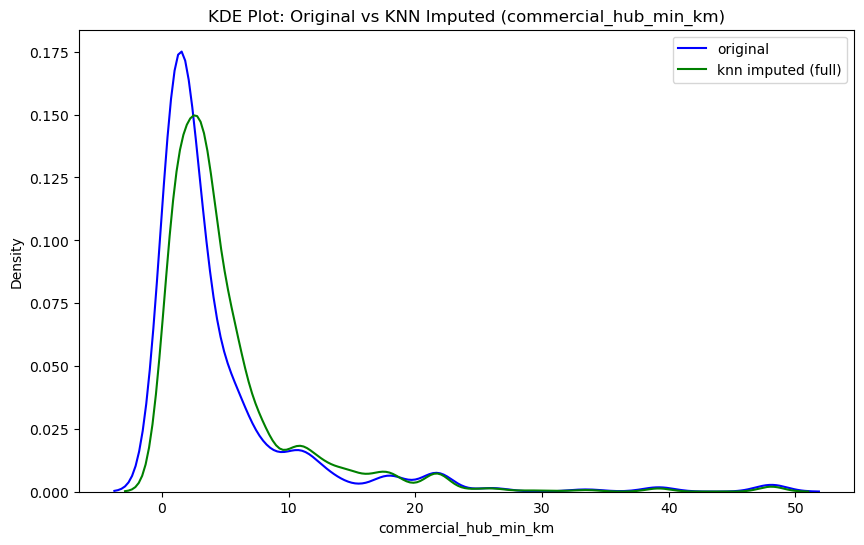

In [104]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'commercial_hub_min_km')

In [105]:
print("Original:\n", X_train['commercial_hub_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['commercial_hub_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['commercial_hub_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5250.000000
mean        4.609031
std         6.938345
min         0.000100
25%         1.000000
50%         2.100000
75%         5.600000
max        48.100000
Name: commercial_hub_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        5.224951
std         6.038299
min         0.000100
25%         1.700000
50%         3.400000
75%         5.795000
max        48.100000
Name: commercial_hub_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        4.018293
std         5.393574
min        -0.102071
25%         1.500000
50%         3.257334
75%         3.800000
max        48.100000
Name: commercial_hub_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        4.609031
std         5.211179
min         0.000100
25%         1.700000
50%         4.609031
75%         4.609031
max        48.100000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.515475
std         5.357654
min         0.000100
25%         

`observation`

- KNN works well 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_min_mean_km

In [106]:
describe_and_missing(X_train, 'overall_min_mean_km')


--- Description for 'overall_min_mean_km' ---
count    6351.000000
mean        1.733045
std         2.634916
min         0.000100
25%         0.700000
50%         0.925000
75%         1.760000
max        21.775000
Name: overall_min_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_min_mean_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

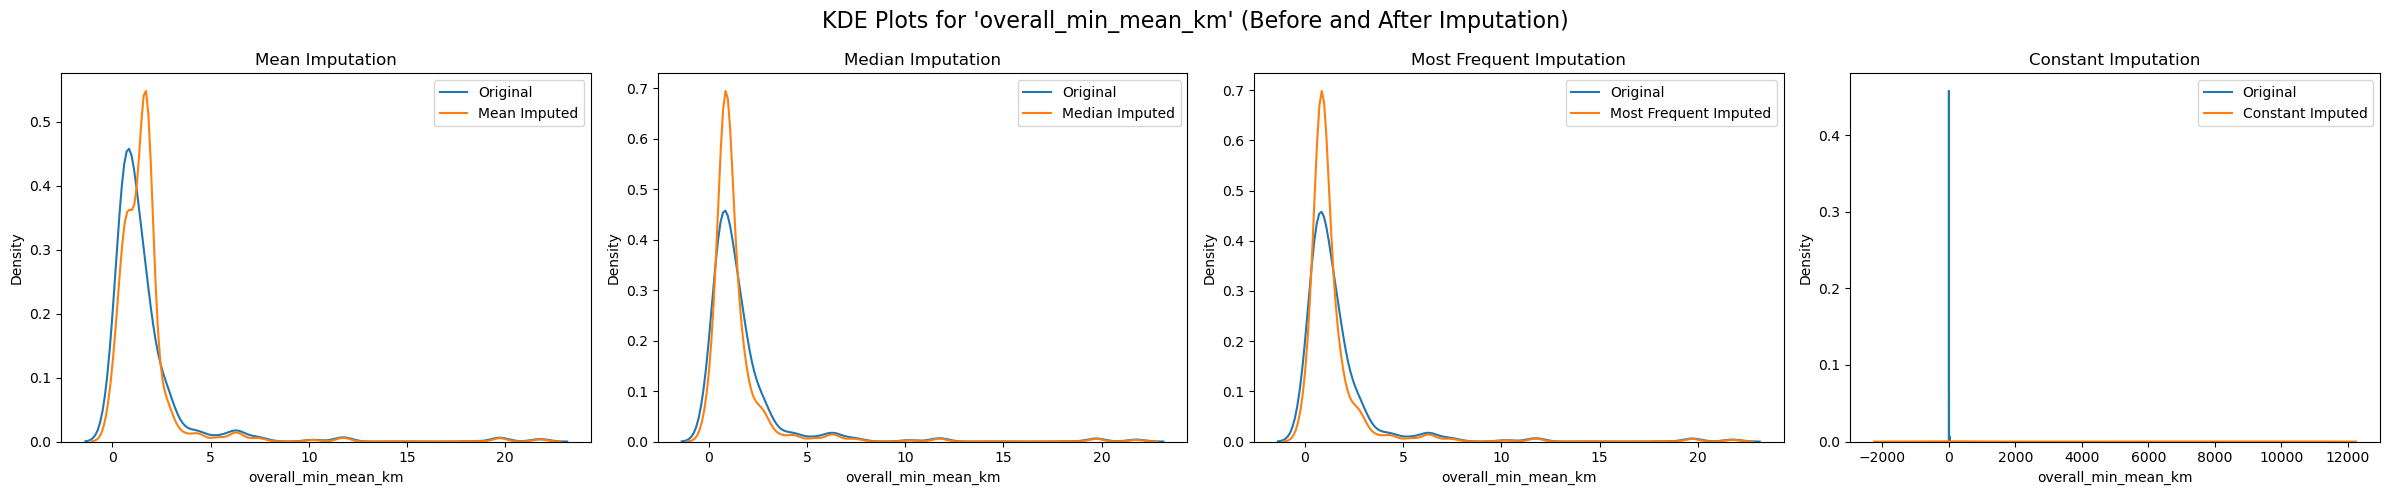

In [107]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_min_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_min_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


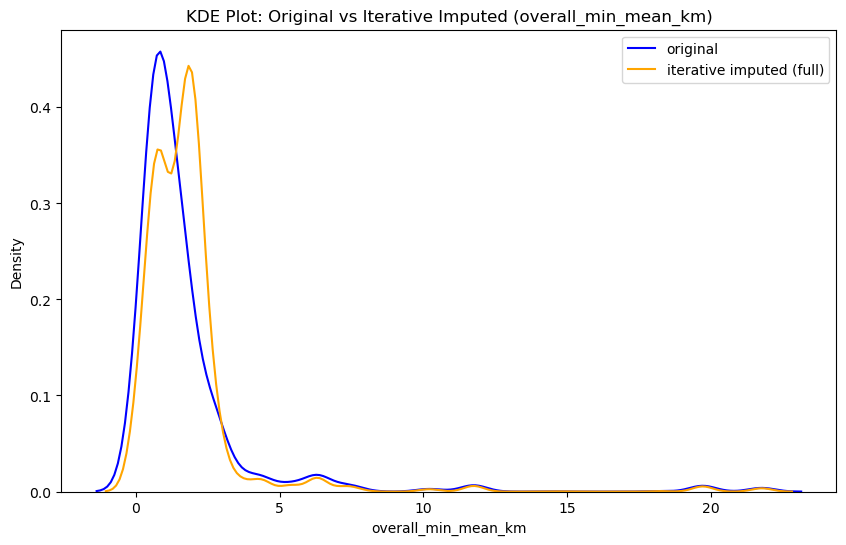

In [108]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_min_mean_km')

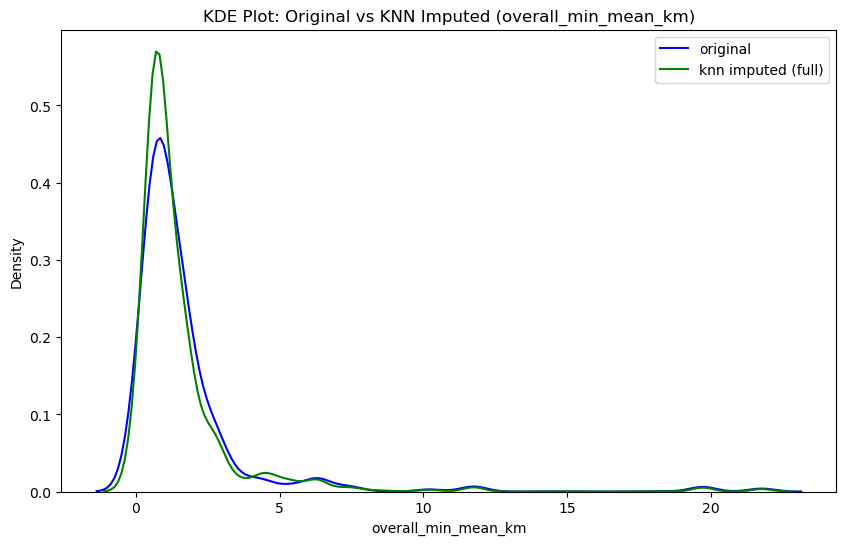

In [109]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_min_mean_km')

In [110]:
print("Original:\n", X_train['overall_min_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_min_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_min_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        1.733045
std         2.634916
min         0.000100
25%         0.700000
50%         0.925000
75%         1.760000
max        21.775000
Name: overall_min_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.577132
std         2.307031
min         0.000100
25%         0.602040
50%         0.900000
75%         1.633333
max        21.775000
Name: overall_min_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.813265
std         2.184519
min         0.000100
25%         0.820000
50%         1.633333
75%         2.082496
max        21.775000
Name: overall_min_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.733045
std         2.176684
min         0.000100
25%         0.820000
50%         1.733045
75%         1.733045
max        21.775000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.476461
std         2.208951
min         0.000100
25%         0.8200

`observation`

- both KNN and median almost same but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_avg_mean_km

In [111]:
describe_and_missing(X_train, 'overall_avg_mean_km')


--- Description for 'overall_avg_mean_km' ---
count    6351.000000
mean        4.810624
std         5.062668
min         0.100000
25%         1.854667
50%         3.540000
75%         4.620000
max        34.788333
Name: overall_avg_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_avg_mean_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

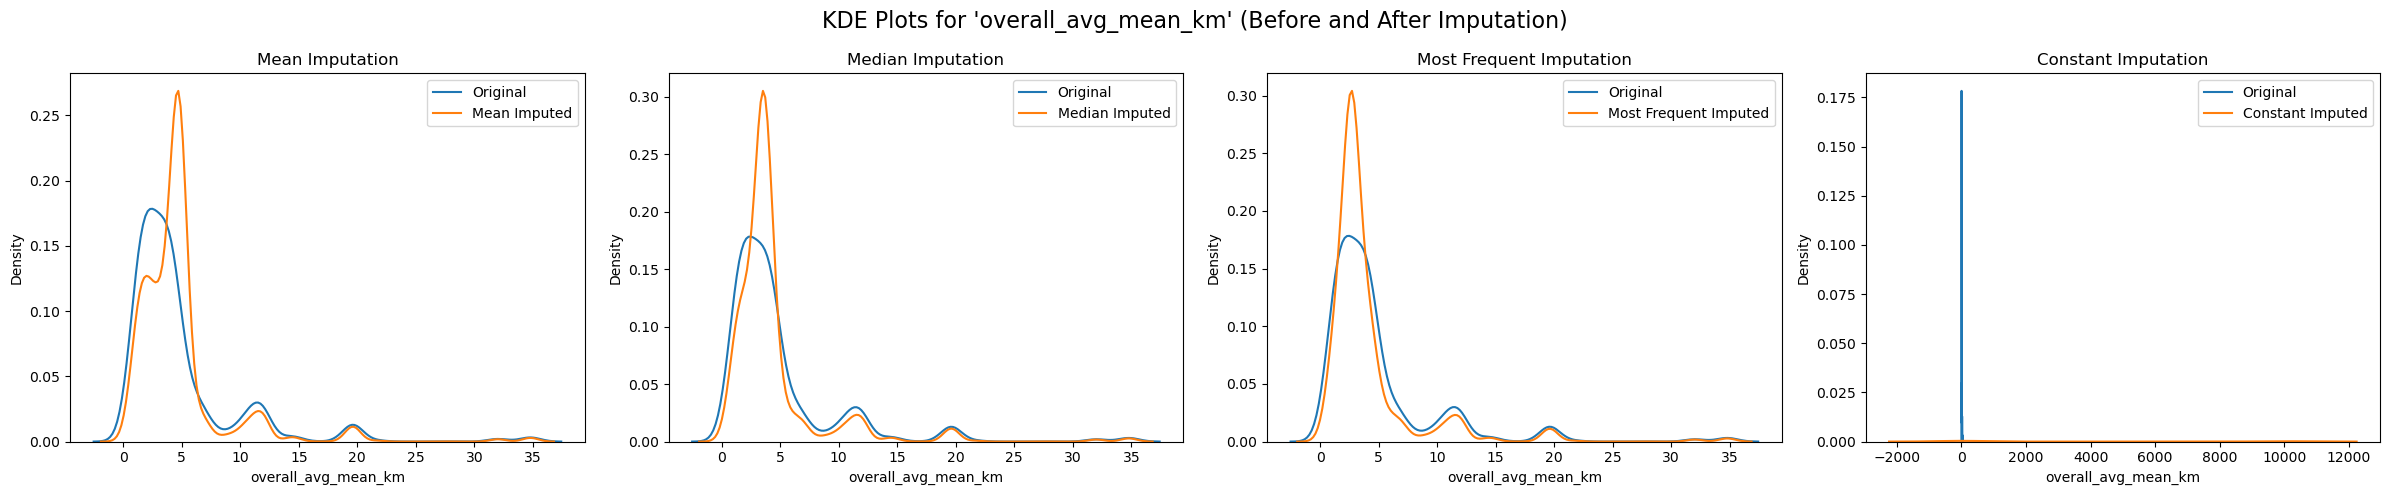

In [112]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_avg_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_avg_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


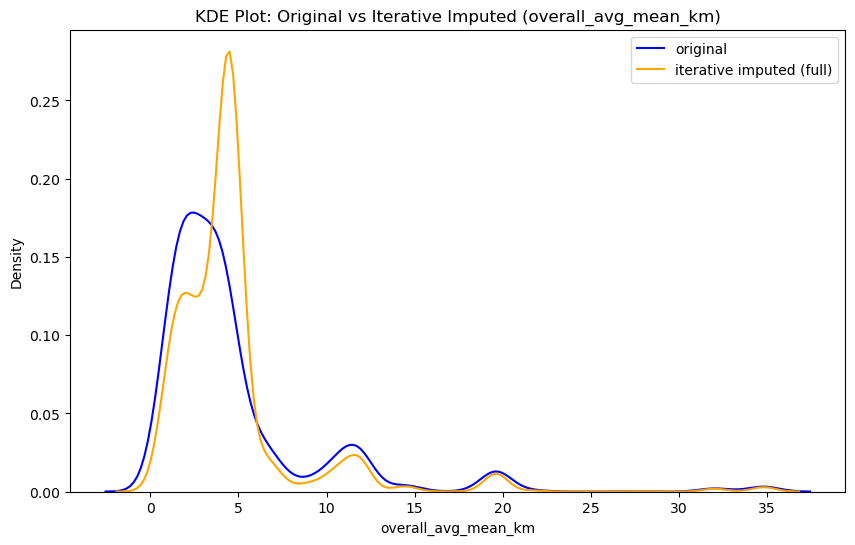

In [113]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_avg_mean_km')

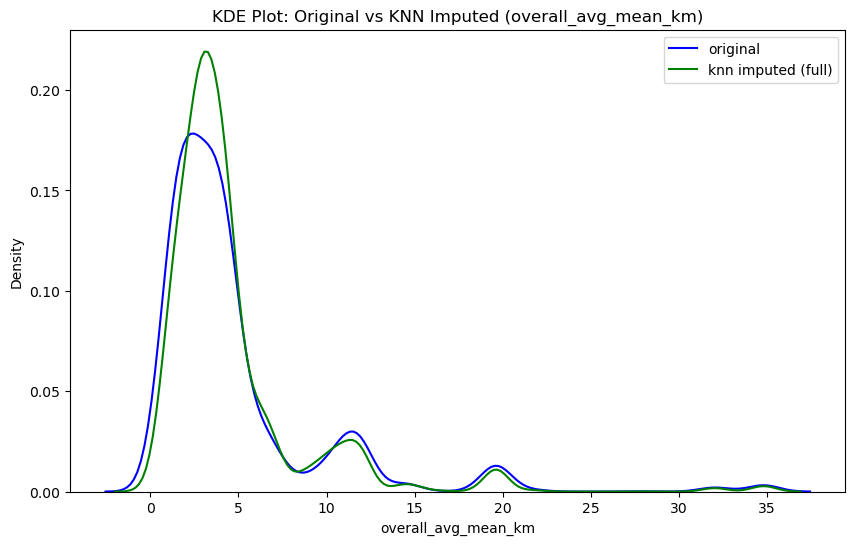

In [114]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_avg_mean_km')

In [115]:
print("Original:\n", X_train['overall_avg_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_avg_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_avg_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        4.810624
std         5.062668
min         0.100000
25%         1.854667
50%         3.540000
75%         4.620000
max        34.788333
Name: overall_avg_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        4.633614
std         4.361217
min         0.100000
25%         2.563673
50%         3.485040
75%         4.647590
max        34.788333
Name: overall_avg_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        4.737294
std         4.183849
min         0.100000
25%         2.690000
50%         4.402445
75%         4.632647
max        34.788333
Name: overall_avg_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        4.810624
std         4.182232
min         0.100000
25%         2.690000
50%         4.620000
75%         4.810624
max        34.788333
dtype: float64 

Median Imputed:
 count    9306.000000
mean        4.407153
std         4.223858
min         0.100000
25%         2.6900

`observation`

- both KNN and median works well but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_min_min_km

In [116]:
describe_and_missing(X_train, 'overall_min_min_km')


--- Description for 'overall_min_min_km' ---
count    6351.000000
mean        0.718734
std         1.230024
min         0.000100
25%         0.200000
50%         0.400000
75%         0.900000
max        14.700000
Name: overall_min_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_min_min_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

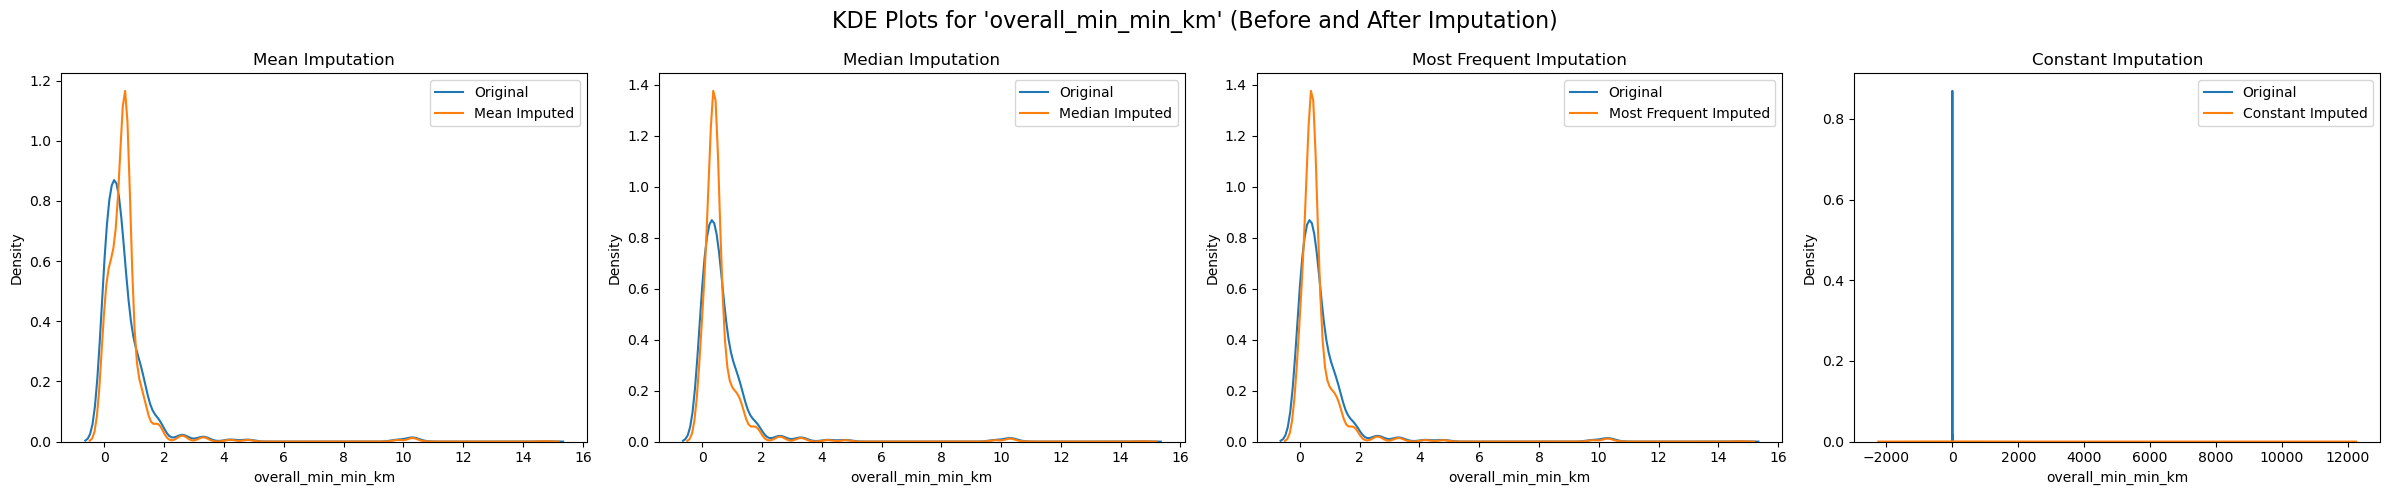

In [117]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_min_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_min_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


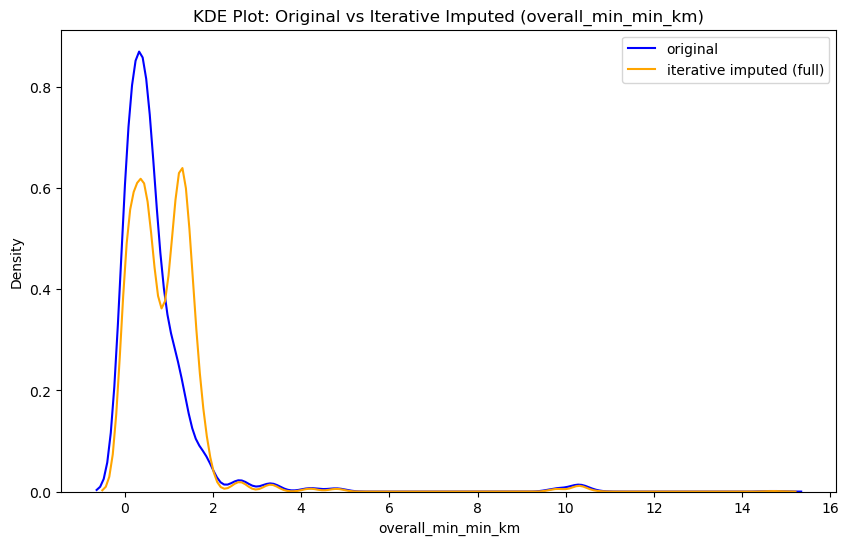

In [118]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_min_min_km')

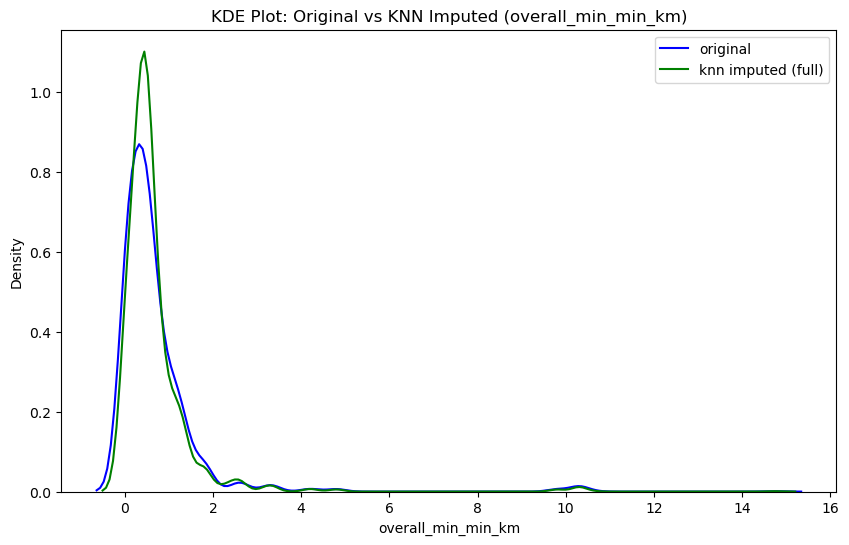

In [119]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_min_min_km')

In [120]:
print("Original:\n", X_train['overall_min_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_min_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_min_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        0.718734
std         1.230024
min         0.000100
25%         0.200000
50%         0.400000
75%         0.900000
max        14.700000
Name: overall_min_min_km, dtype: float64 

KNN Imputed:
 count    9306.00000
mean        0.68558
std         1.04820
min         0.00010
25%         0.30000
50%         0.48002
75%         0.72002
max        14.70000
Name: overall_min_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        0.911705
std         1.060439
min         0.000100
25%         0.300000
50%         0.800000
75%         1.300000
max        14.700000
Name: overall_min_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        0.718734
std         1.016114
min         0.000100
25%         0.300000
50%         0.718734
75%         0.718734
max        14.700000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        0.617524
std         1.026891
min         0.000100
25%         0.300000
50%     

`observation`

- both KNN and median works well but KNN is slightly betteer
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_avg_min_km

In [121]:
describe_and_missing(X_train, 'overall_avg_min_km')


--- Description for 'overall_avg_min_km' ---
count    6351.000000
mean        2.370468
std         2.931916
min         0.000100
25%         0.820000
50%         1.675000
75%         2.200000
max        24.125000
Name: overall_avg_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_avg_min_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

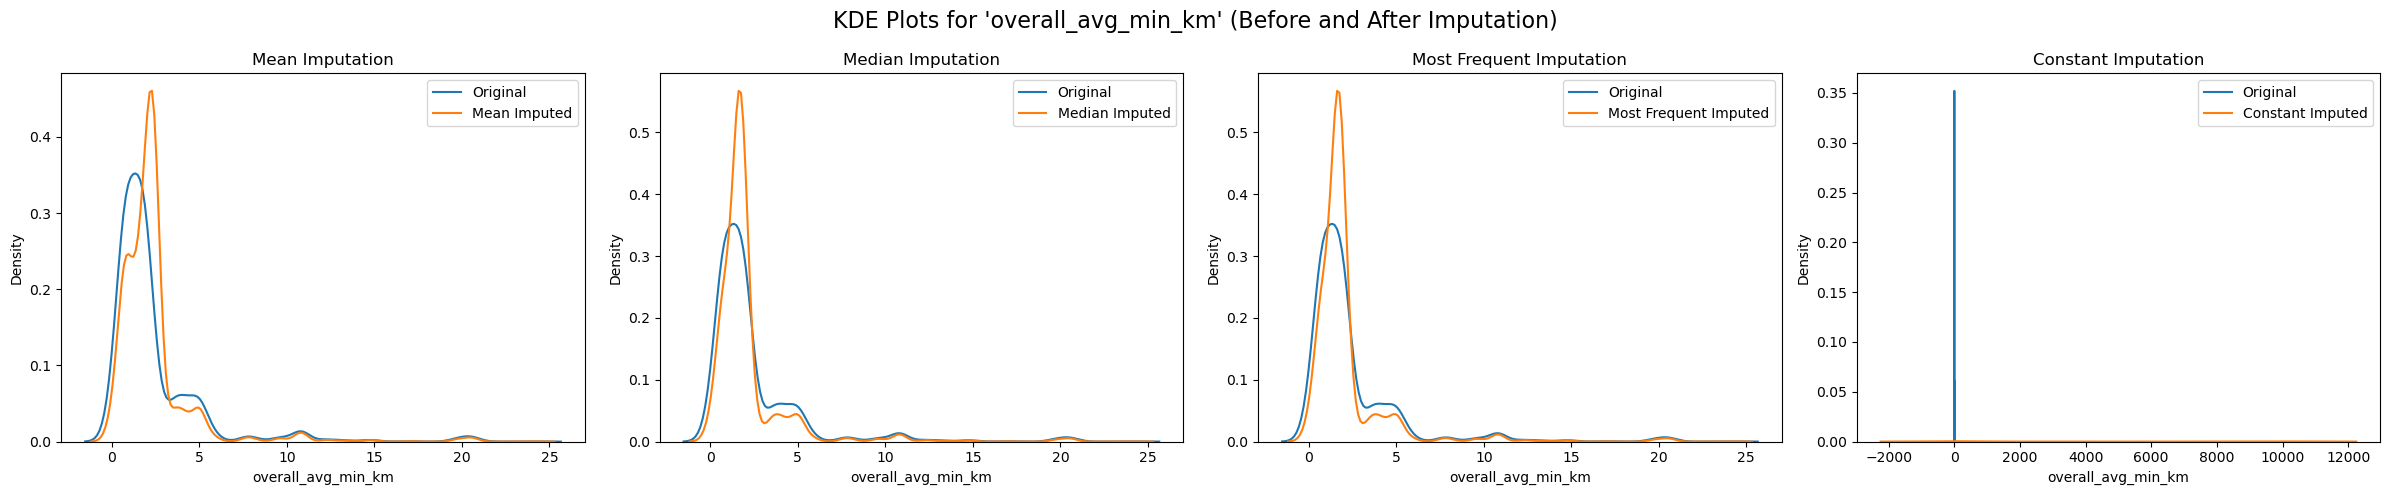

In [122]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_avg_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_avg_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


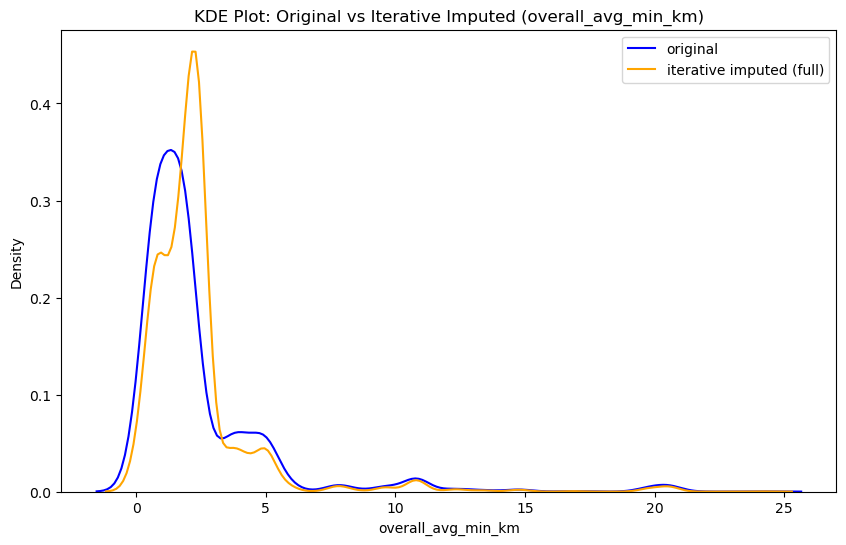

In [123]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_avg_min_km')

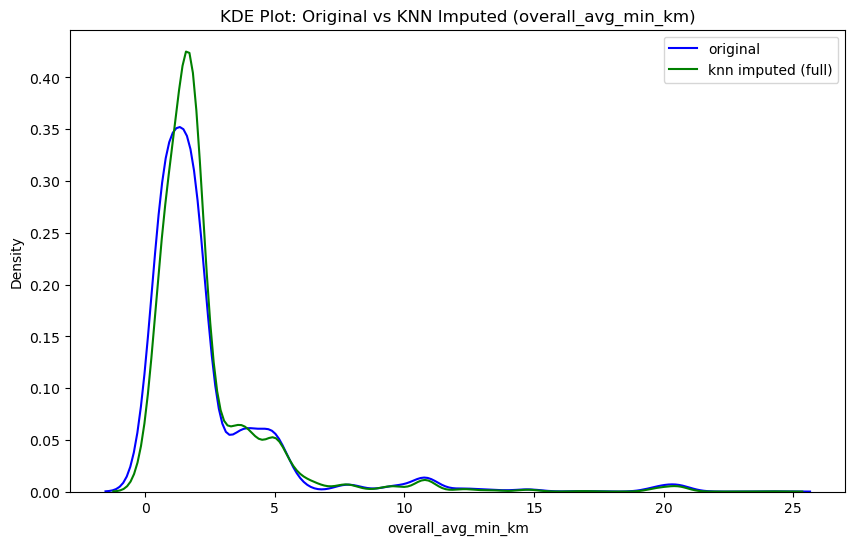

In [124]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_avg_min_km')

In [125]:
print("Original:\n", X_train['overall_avg_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_avg_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_avg_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        2.370468
std         2.931916
min         0.000100
25%         0.820000
50%         1.675000
75%         2.200000
max        24.125000
Name: overall_avg_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.351505
std         2.543496
min         0.000100
25%         1.075000
50%         1.675000
75%         2.300000
max        24.125000
Name: overall_avg_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.370553
std         2.422499
min         0.000100
25%         1.200000
50%         2.150000
75%         2.407400
max        24.125000
Name: overall_avg_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.370468
std         2.422034
min         0.000100
25%         1.200000
50%         2.175000
75%         2.370468
max        24.125000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        2.149631
std         2.443578
min         0.000100
25%         1.200000


`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### available_units

In [126]:
describe_and_missing(X_train, 'available_units')


--- Description for 'available_units' ---
count     5171.000000
mean       455.931348
std       1104.010526
min          6.000000
25%        120.000000
50%        275.000000
75%        534.000000
max      40000.000000
Name: available_units, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'available_units': 4135


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

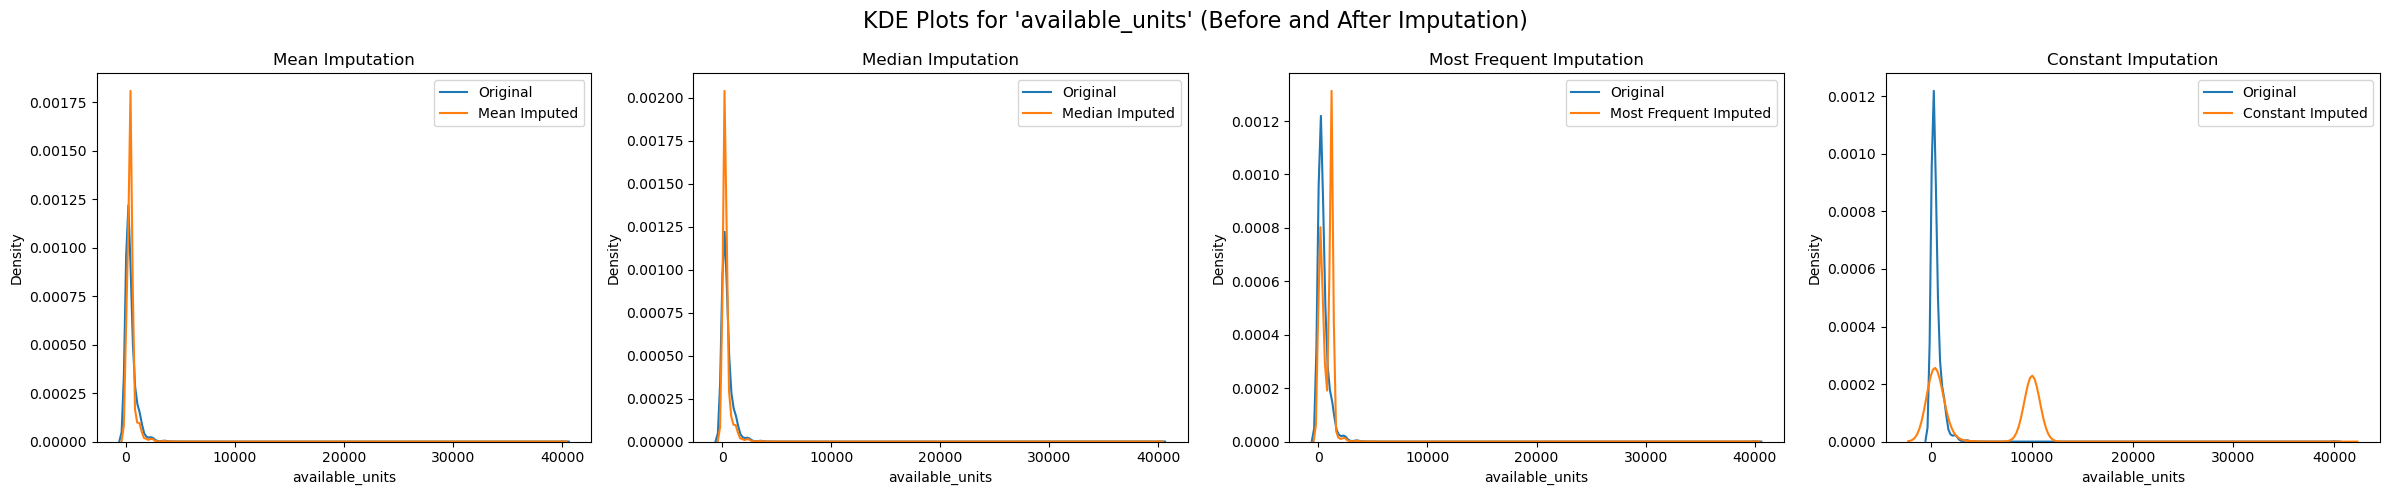

In [127]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'available_units', constant_value=9999)
plot_kde_imputations(X_train, 'available_units')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


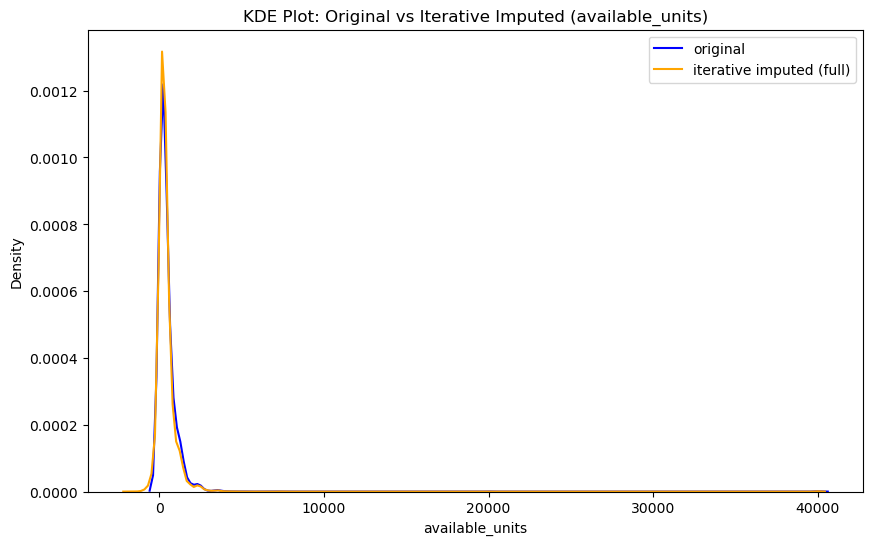

In [128]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'available_units')

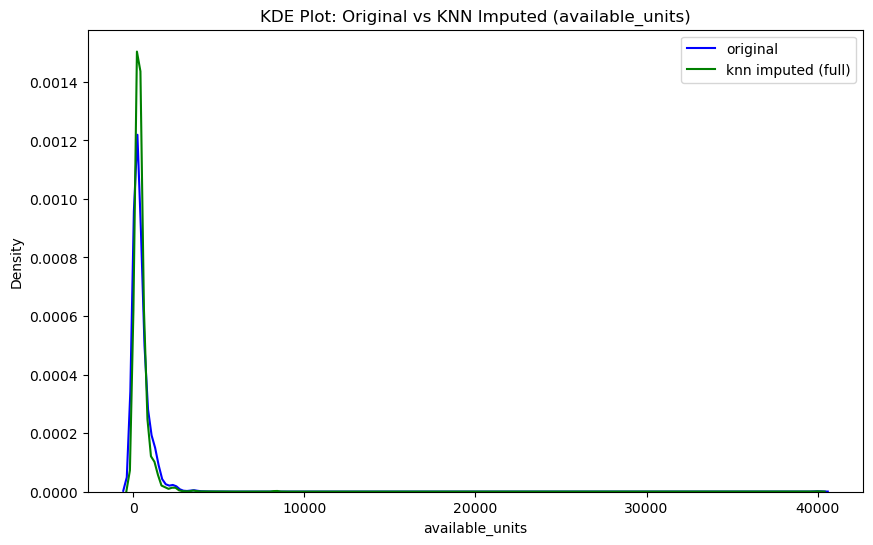

In [129]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'available_units')

In [130]:
print("Original:\n", X_train['available_units'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['available_units'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['available_units'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count     5171.000000
mean       455.931348
std       1104.010526
min          6.000000
25%        120.000000
50%        275.000000
75%        534.000000
max      40000.000000
Name: available_units, dtype: float64 

KNN Imputed:
 count     9306.000000
mean       432.571008
std        860.996702
min          6.000000
25%        229.450000
50%        324.000000
75%        481.100000
max      40000.000000
Name: available_units, dtype: float64 

Iterative Imputed:
 count     9306.000000
mean       388.165223
std        878.252456
min      -1771.712363
25%        112.000000
50%        278.000000
75%        489.000000
max      40000.000000
Name: available_units, dtype: float64 

Mean Imputed:
 count     9306.000000
mean       455.931348
std        822.925077
min          6.000000
25%        233.000000
50%        455.931348
75%        455.931348
max      40000.000000
dtype: float64 

Median Imputed:
 count     9306.000000
mean       375.536858
std        827.821938
min          6.0

`observation`

- KNN and median works well but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

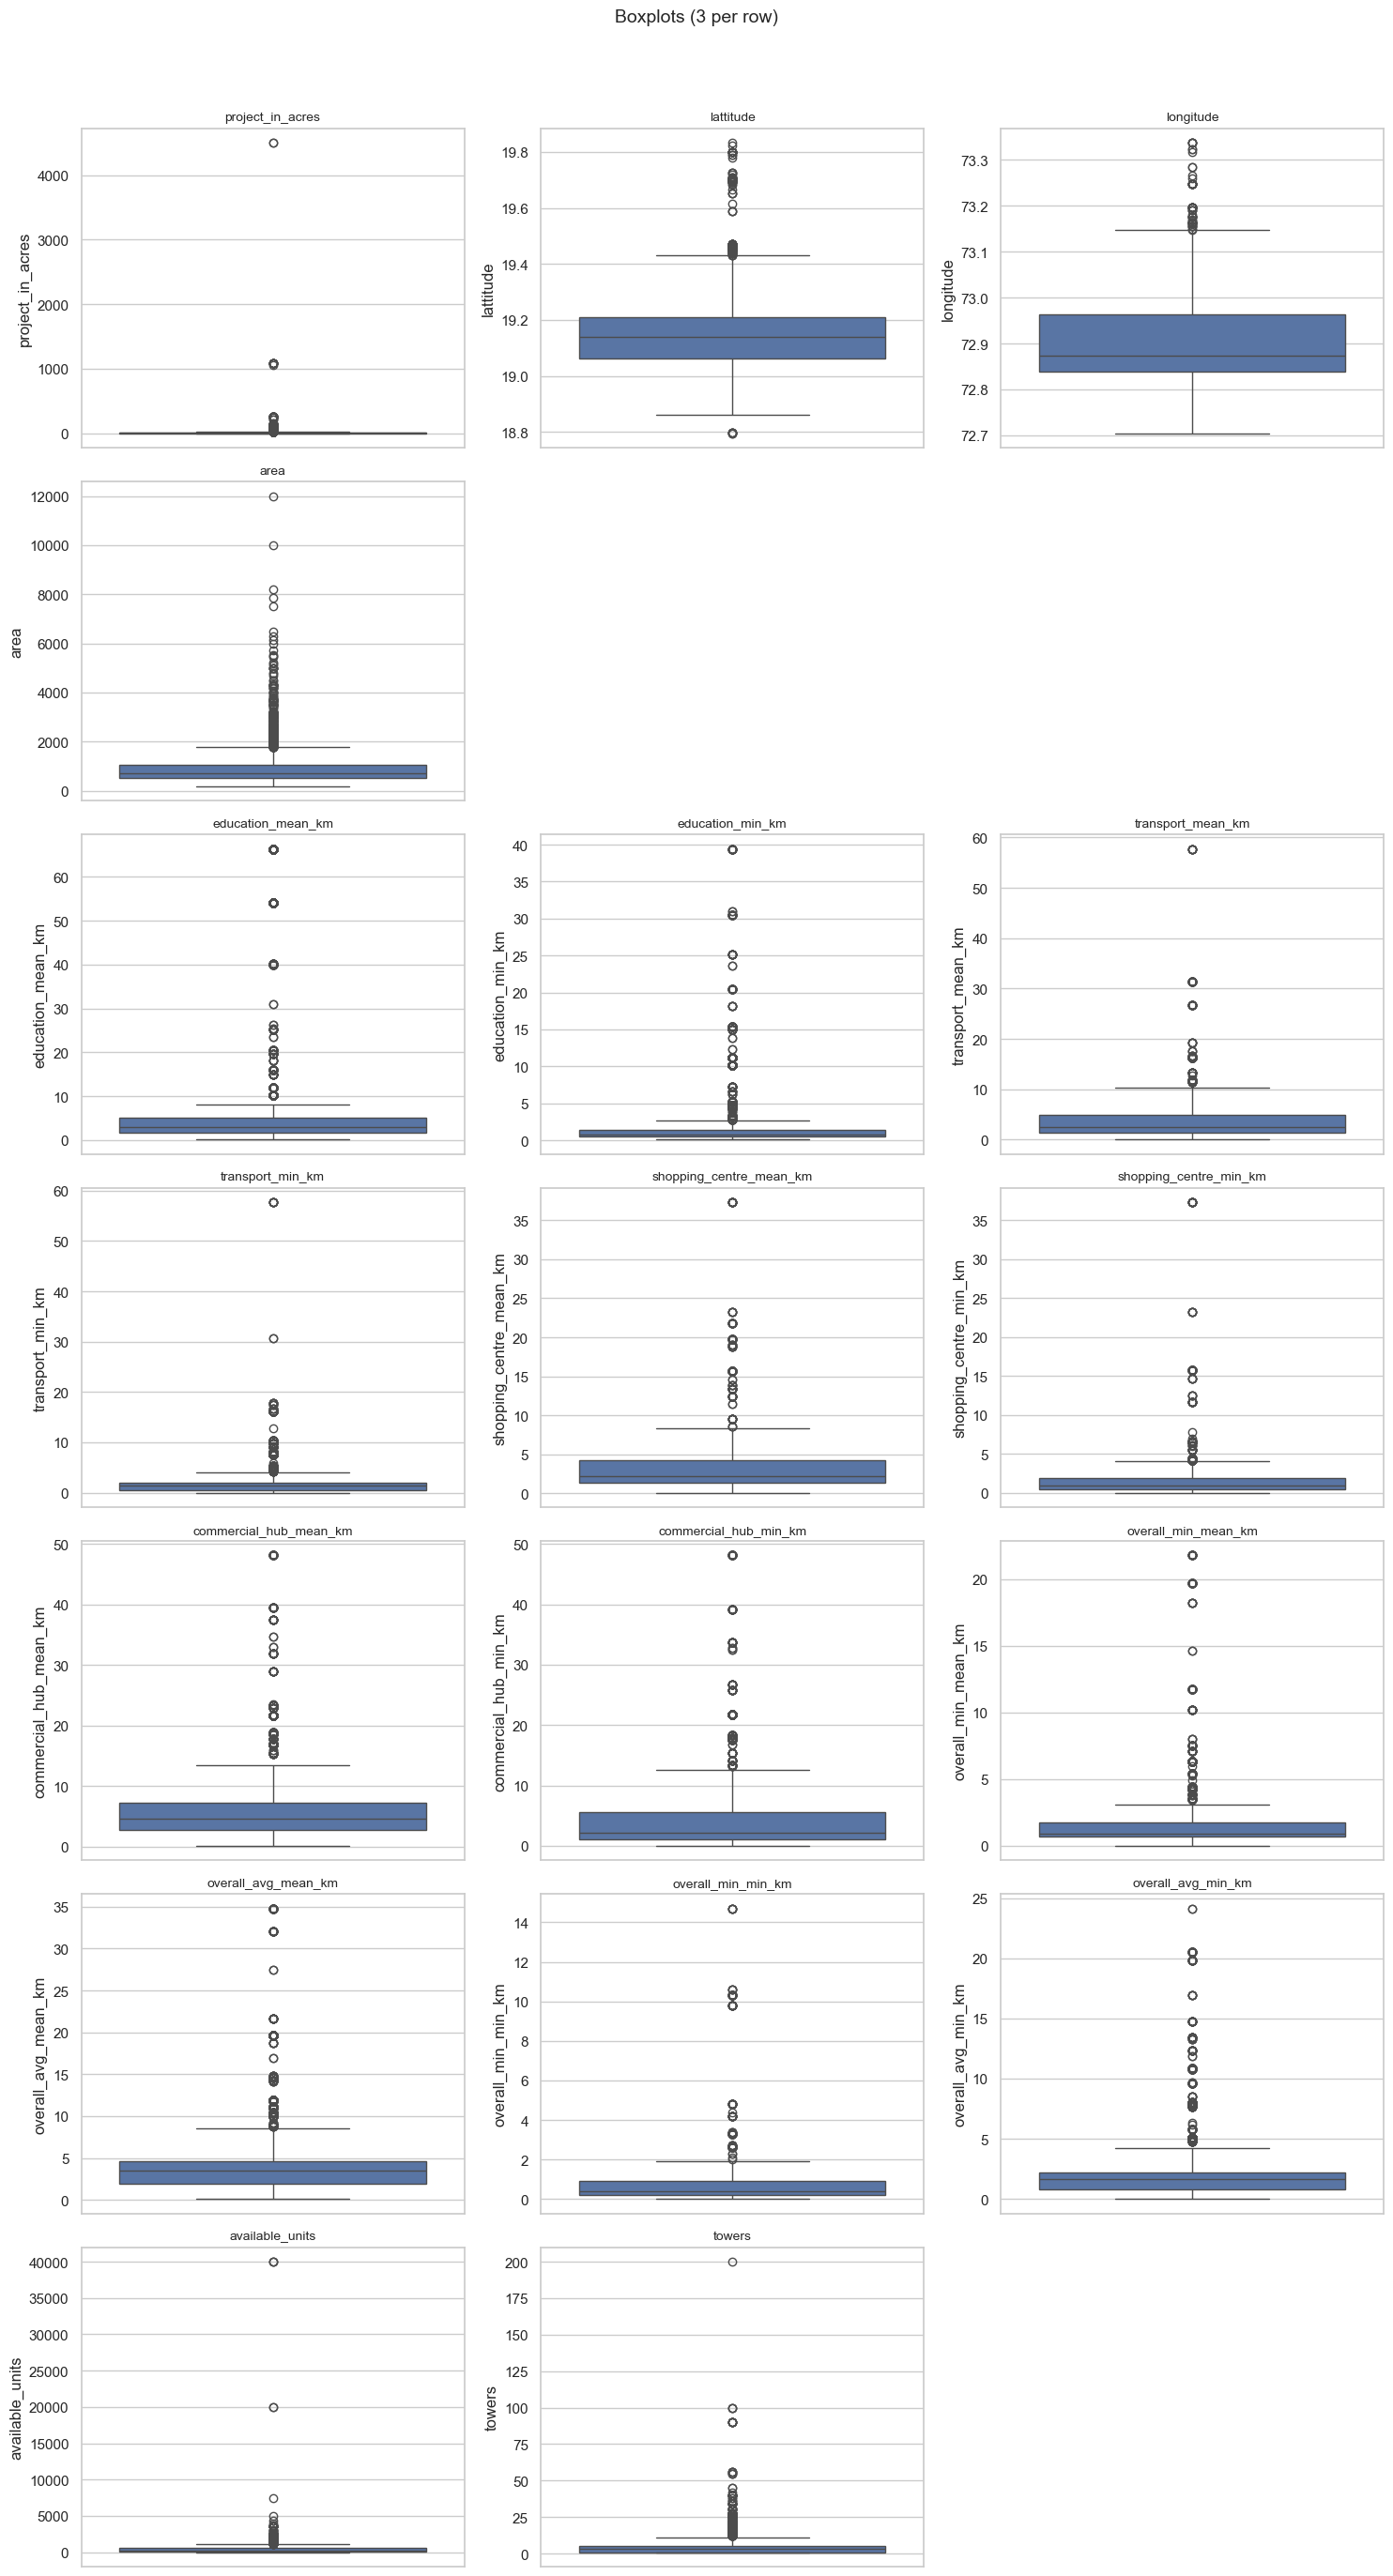

In [35]:
sns.set(style="whitegrid")

num_nominal_cols = [
    'project_in_acres','lattitude','longitude','area','costpersqft','emi',
    'education_mean_km', 'education_min_km','transport_mean_km', 'transport_min_km',
    'shopping_centre_mean_km', 'shopping_centre_min_km','commercial_hub_mean_km',
    'commercial_hub_min_km','overall_min_mean_km', 'overall_avg_mean_km',
    'overall_min_min_km', 'overall_avg_min_km','available_units','towers'
]

# layout config
n_cols = 3                      # 3 boxplots per row (first row will have 3)
n_plots = len(num_nominal_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_nominal_cols):
    ax = axes[i]
    if col not in X_train.columns:
        ax.set_visible(False)
        continue

    # ensure numeric (coerce bad values to NaN)
    series = pd.to_numeric(X_train[col], errors='coerce')

    # optional: drop NaNs for plotting or keep them (here we drop)
    series_clean = series.dropna()

    # draw vertical boxplot
    sns.boxplot(y=series_clean, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")    # hide x label (single value)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# hide any extra axes if total subplots > columns
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots (3 per row)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])   # leave space for suptitle
plt.show()


### towers

In [131]:
describe_and_missing(X_train, 'towers')


--- Description for 'towers' ---
count    5303.000000
mean        4.606638
std         6.709855
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       100.000000
Name: towers, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'towers': 4003


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

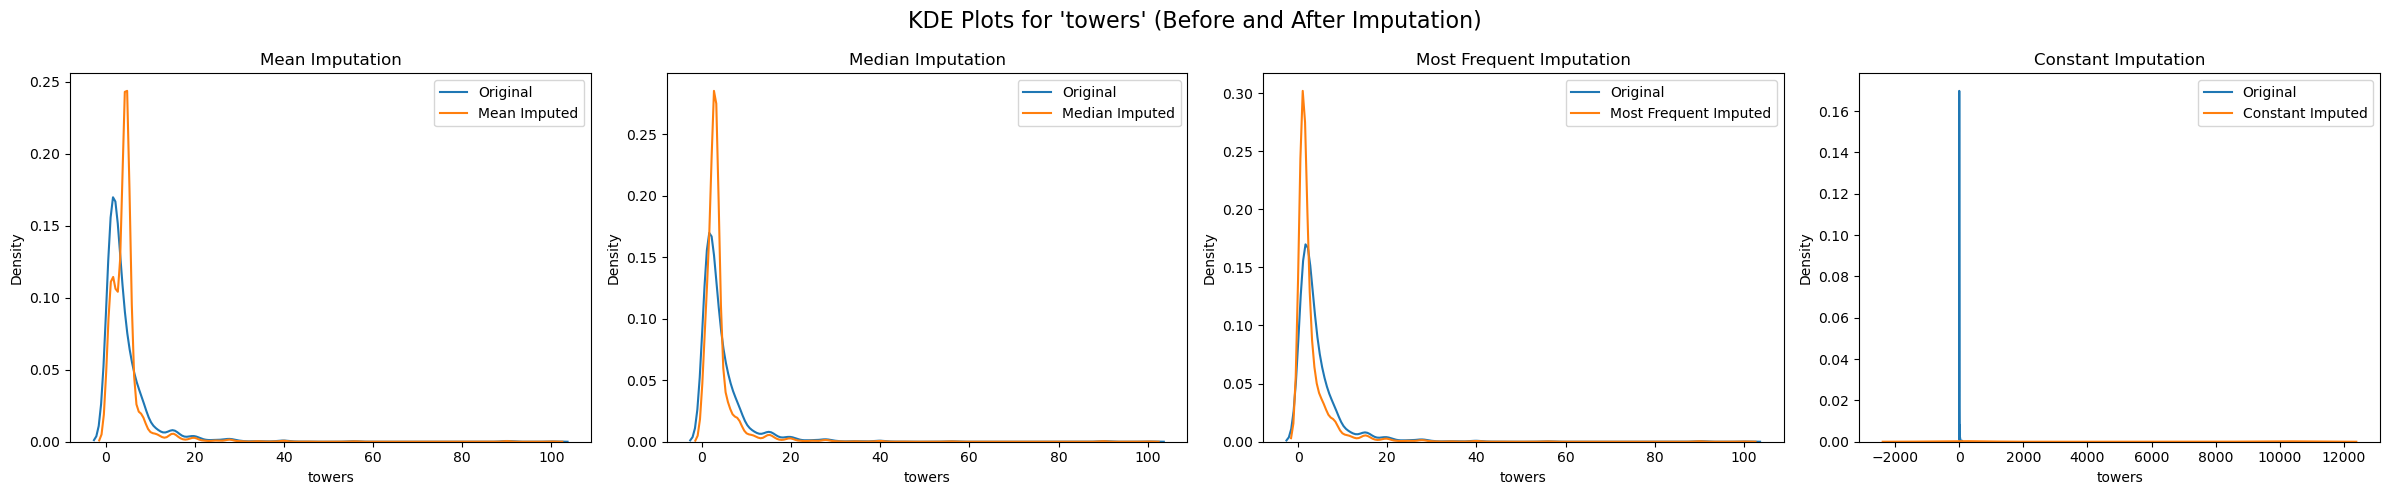

In [132]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'towers', constant_value=9999)
plot_kde_imputations(X_train, 'towers')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


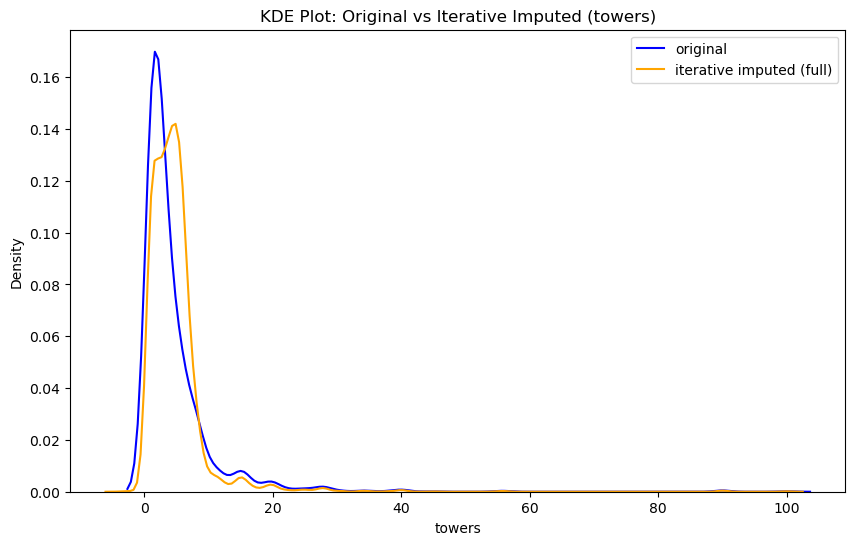

In [133]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'towers')

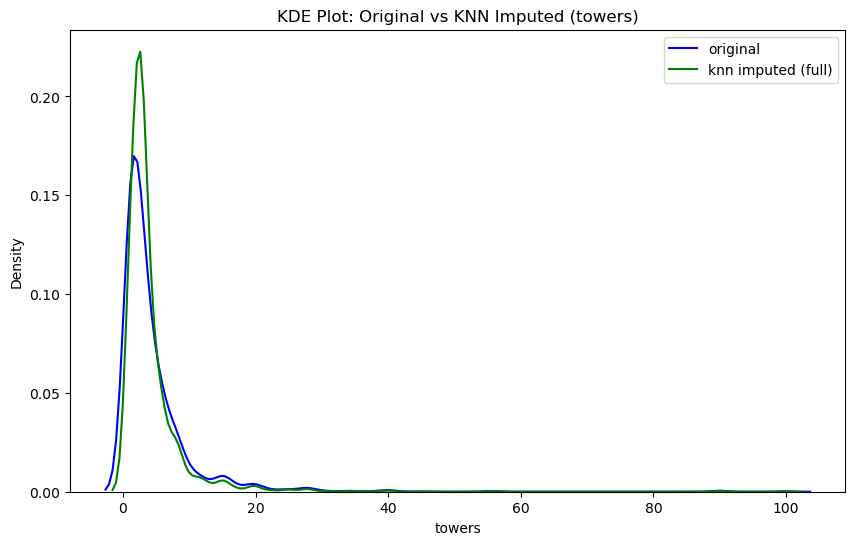

In [134]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'towers')

In [135]:
print("Original:\n", X_train['towers'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['towers'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['towers'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5303.000000
mean        4.606638
std         6.709855
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       100.000000
Name: towers, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        4.178702
std         5.311634
min         1.000000
25%         2.000000
50%         3.000000
75%         4.600000
max       100.000000
Name: towers, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        4.760665
std         5.167486
min        -3.539702
25%         2.000000
50%         4.000000
75%         5.921718
max       100.000000
Name: towers, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        4.606638
std         5.064946
min         1.000000
25%         2.000000
50%         4.606638
75%         4.606638
max       100.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.915538
std         5.127033
min         1.000000
25%         2.000000
50%         3.000000
75%         3.0

`observation`

- both KNN and median works well but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

`conclusion`  
num_nominal_cols   
'project_in_acres','longitude','area''costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'shopping_centre_min_km','overall_min_mean_km', 'overall_avg_mean_km','overall_min_min_km', 'overall_avg_min_km','available_units','towers' - KNN,    
'lattitude','commercial_hub_mean_km' - iterative,    
'transport_min_km','shopping_centre_mean_km', 'commercial_hub_min_km'- median

#delete this after reading and appyling

<font color = yellow> we have to add missing indicator also for each column we have to follow both below approaches 

---------------------------------------------------------------------------------------------------------------------

1.Approach: Imputation only   
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)  
model = LogisticRegression()  
scores_1 = cross_val_score(model, X_imputed, y, cv=3)  
print("Imputation only scores:", scores_1)  

--------------------------------------------------------------------------------------------------------------------
2.Approach: Imputation + Missing Indicator  
preprocessor = ColumnTransformer(transformers=[  
    ('impute', SimpleImputer(strategy='mean', add_indicator=True), ['Age', 'Fare'])  
])  
pipeline = make_pipeline(preprocessor, LogisticRegression())  
scores_2 = cross_val_score(pipeline, X, y, cv=3)  
print("Imputation + MissingIndicator scores:", scores_2)  

## Analysis on num_ordinal_cols

In [136]:
num_ordinal_cols = ['flat_on_floor','total_floor','bed','bath','balcony','lift','parking','education_within_2km','transport_within_2km','shopping_centre_within_2km',
                    'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

### flat_on_floor

In [137]:
describe_and_missing(X_train, 'flat_on_floor')


--- Description for 'flat_on_floor' ---
count    7663.000000
mean       10.823046
std        10.029193
min        -2.000000
25%         4.000000
50%         8.000000
75%        15.000000
max        73.000000
Name: flat_on_floor, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'flat_on_floor': 1643


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

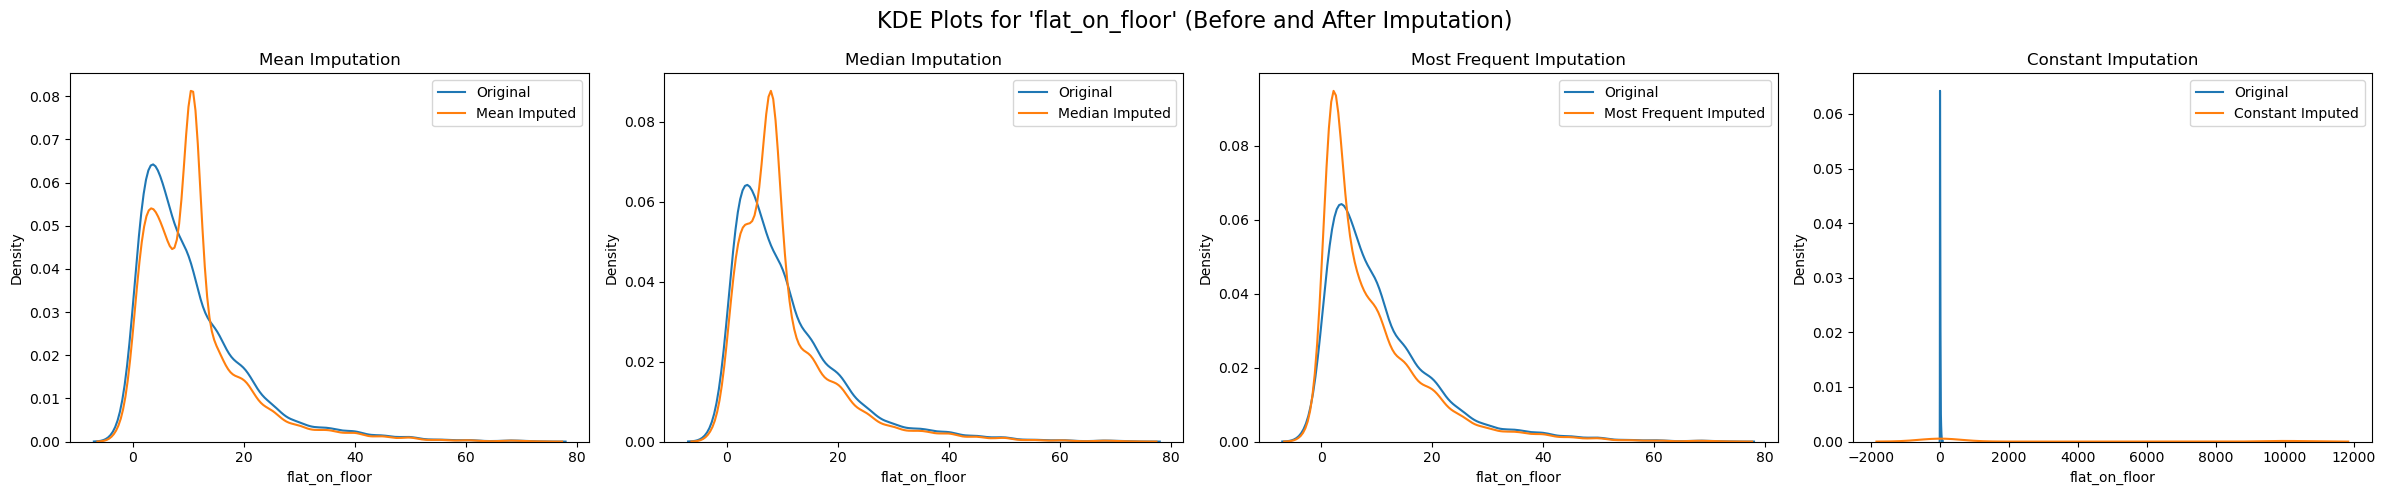

In [138]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'flat_on_floor', constant_value=9999)
plot_kde_imputations(X_train, 'flat_on_floor')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


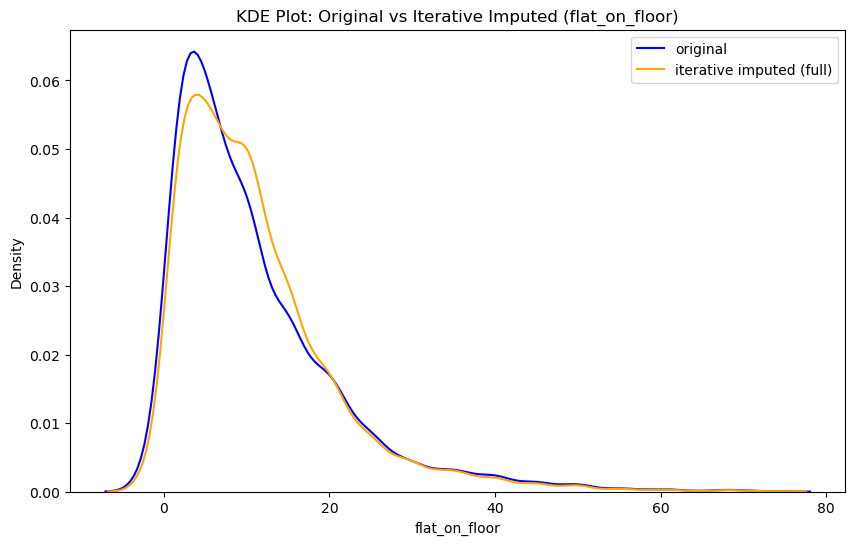

In [139]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'flat_on_floor')

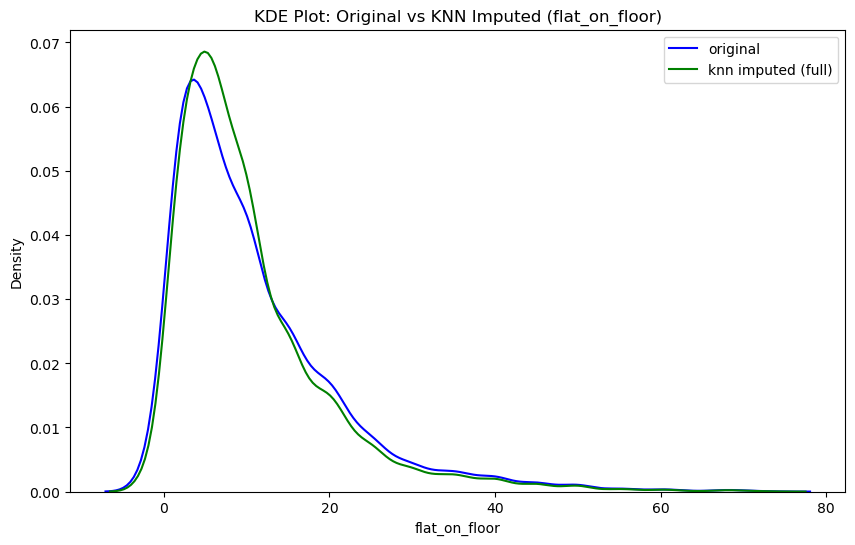

In [140]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'flat_on_floor')

In [141]:
print("Original:\n", X_train['flat_on_floor'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['flat_on_floor'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['flat_on_floor'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    7663.000000
mean       10.823046
std        10.029193
min        -2.000000
25%         4.000000
50%         8.000000
75%        15.000000
max        73.000000
Name: flat_on_floor, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       10.362390
std         9.300778
min        -2.000000
25%         4.000000
50%         8.000000
75%        14.000000
max        73.000000
Name: flat_on_floor, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       11.082059
std         9.469168
min        -2.193134
25%         4.000000
50%         9.000000
75%        15.000000
max        73.000000
Name: flat_on_floor, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       10.823046
std         9.100785
min        -2.000000
25%         5.000000
50%        10.000000
75%        13.000000
max        73.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean       10.324629
std         9.164227
min        -2.000000
25%         5.000000
50%         8.0

`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### total_floor

In [142]:
describe_and_missing(X_train, 'total_floor')


--- Description for 'total_floor' ---
count    7854.000000
mean       22.176980
std        16.157351
min         1.000000
25%         8.000000
50%        19.000000
75%        30.000000
max        92.000000
Name: total_floor, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'total_floor': 1452


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

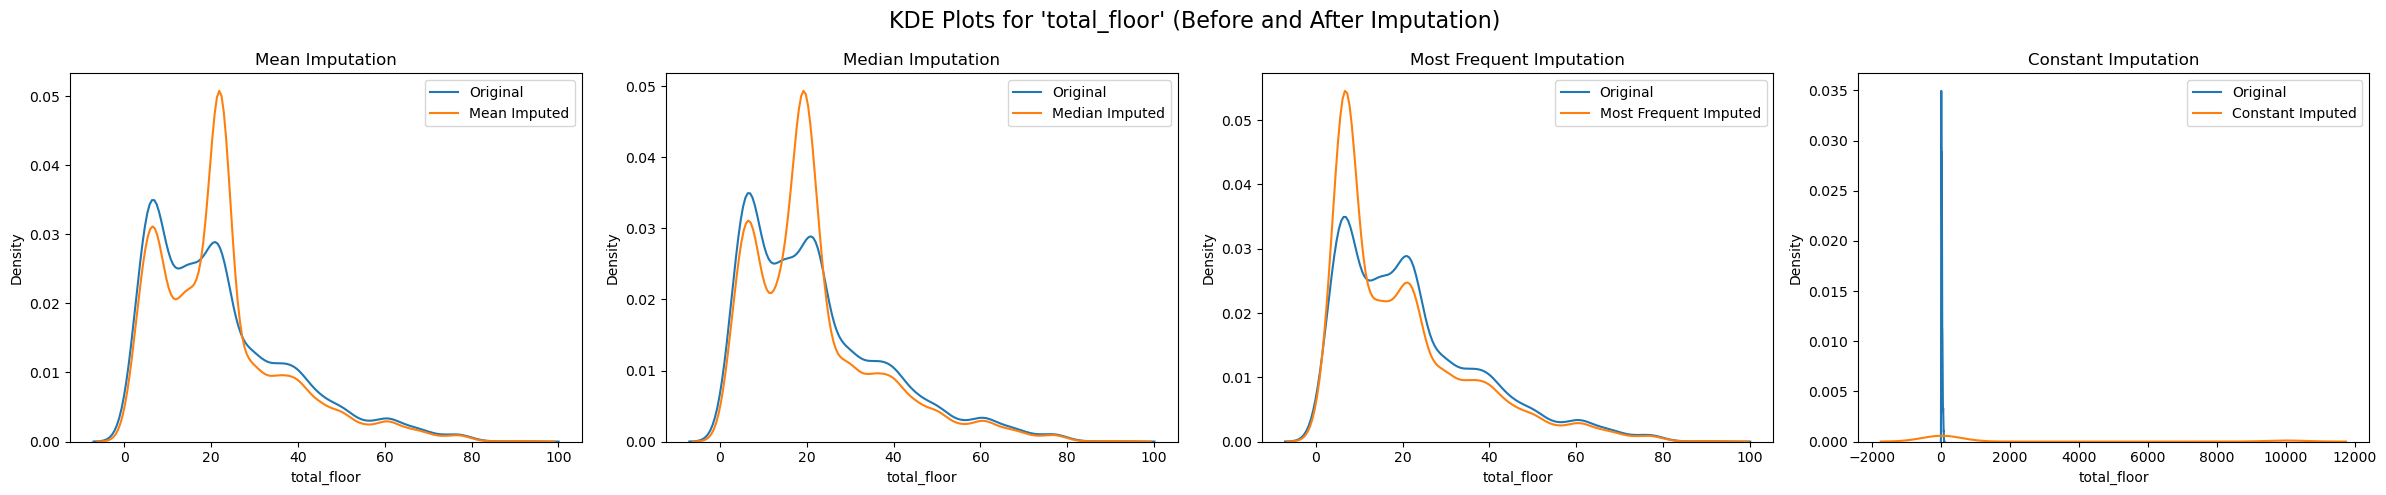

In [143]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'total_floor', constant_value=9999)
plot_kde_imputations(X_train, 'total_floor')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


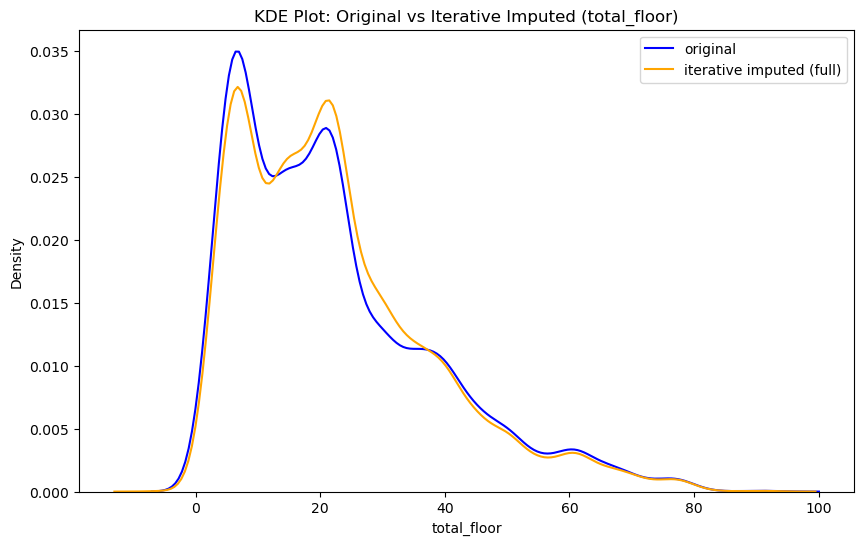

In [144]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'total_floor')

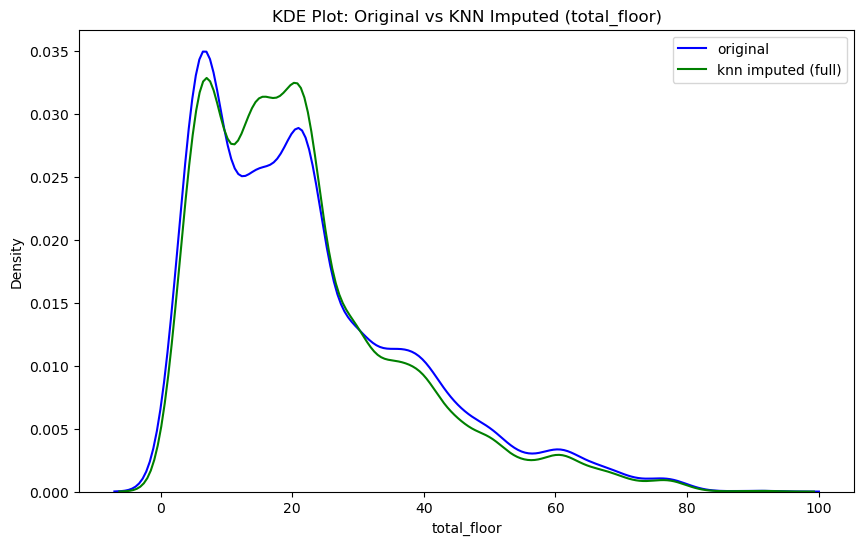

In [145]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'total_floor')

In [146]:
print("Original:\n", X_train['total_floor'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['total_floor'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['total_floor'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    7854.000000
mean       22.176980
std        16.157351
min         1.000000
25%         8.000000
50%        19.000000
75%        30.000000
max        92.000000
Name: total_floor, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       21.598259
std        15.140123
min         1.000000
25%        10.000000
50%        18.600000
75%        28.400000
max        92.000000
Name: total_floor, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       22.498240
std        15.576659
min        -5.554896
25%        10.000000
50%        20.000000
75%        30.000000
max        92.000000
Name: total_floor, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       22.176980
std        14.843276
min         1.000000
25%        11.000000
50%        22.000000
75%        27.000000
max        92.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean       21.681281
std        14.887985
min         1.000000
25%        11.000000
50%        19.000000


`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### bath

In [147]:
describe_and_missing(X_train, 'bath')


--- Description for 'bath' ---
count    9280.000000
mean        2.317996
std         0.965433
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: bath, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'bath': 26


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

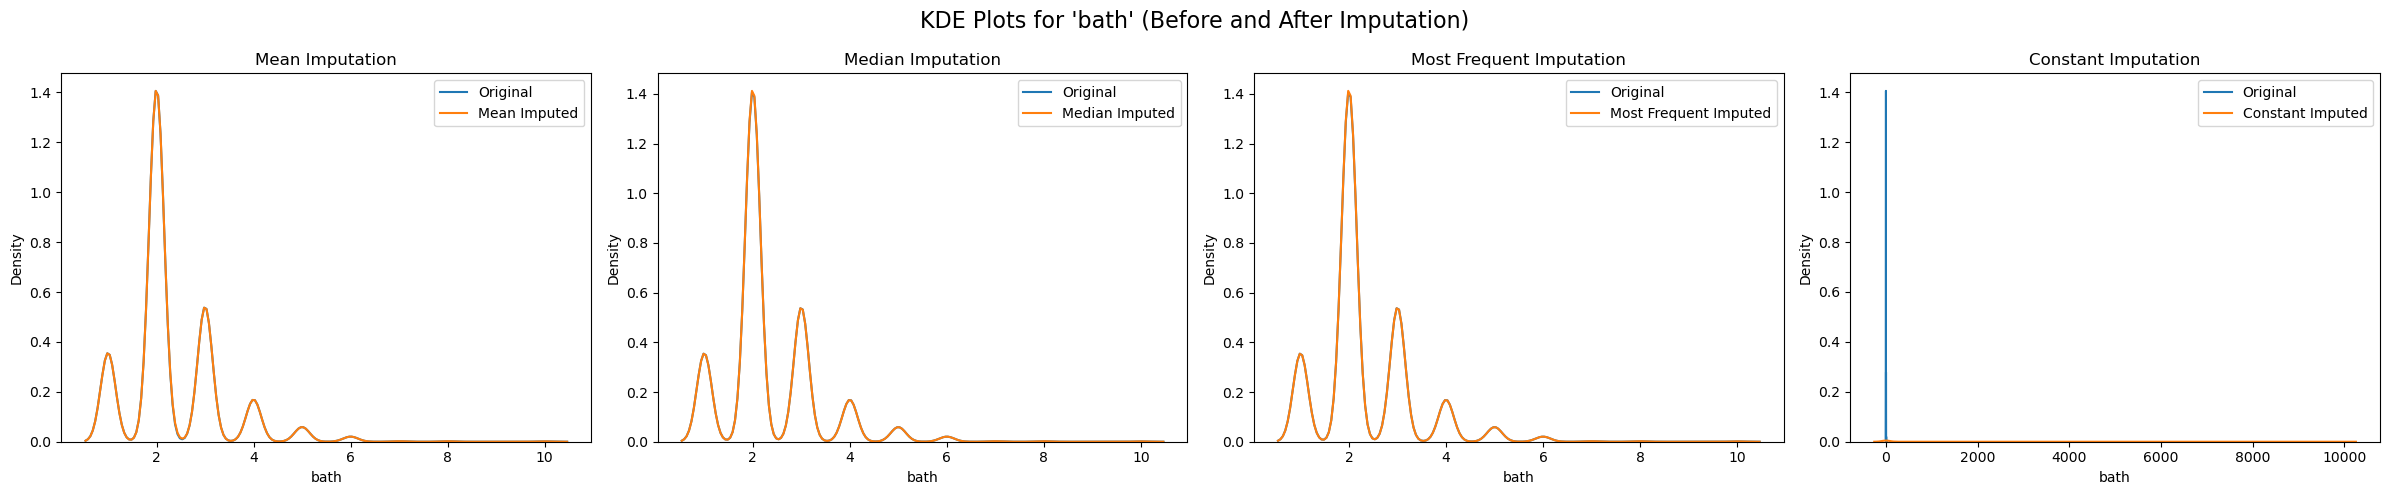

In [148]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'bath', constant_value=9999)
plot_kde_imputations(X_train, 'bath')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'bath')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'bath')

In [ ]:
print("Original:\n", X_train['bath'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['bath'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['bath'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### balcony

In [ ]:
describe_and_missing(X_train, 'balcony')

`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'balcony', constant_value=9999)
plot_kde_imputations(X_train, 'balcony')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'balcony')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'balcony')

In [ ]:
print("Original:\n", X_train['balcony'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['balcony'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['balcony'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`

- KNN works well
- as using KNN distribution is shifted, so use another method like missing indicator in next experiment 

### lift

In [ ]:
describe_and_missing(X_train, 'lift')

`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'lift', constant_value=9999)
plot_kde_imputations(X_train, 'lift')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
#approach B
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'lift')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'lift')

In [ ]:
print("Original:\n", X_train['lift'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['lift'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['lift'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`

- median works well

### parking

In [ ]:
describe_and_missing(X_train, 'parking')

`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'parking', constant_value=9999)
plot_kde_imputations(X_train, 'parking')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'parking')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'parking')

In [ ]:
print("Original:\n", X_train['parking'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['parking'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['parking'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.
- also try missing indicator

`observation`

The following columns have no missing values
- `bed`
- `education_within_2km`
- `transport_within_2km`
- `shopping_centre_within_2km`
- `commercial_hub_within_2km`
- `hospital_within_2km`
- `tourist_within_2km`
- `total_within_2km`

Conclusion: No imputation needed for these columns. Data is complete and consistent.


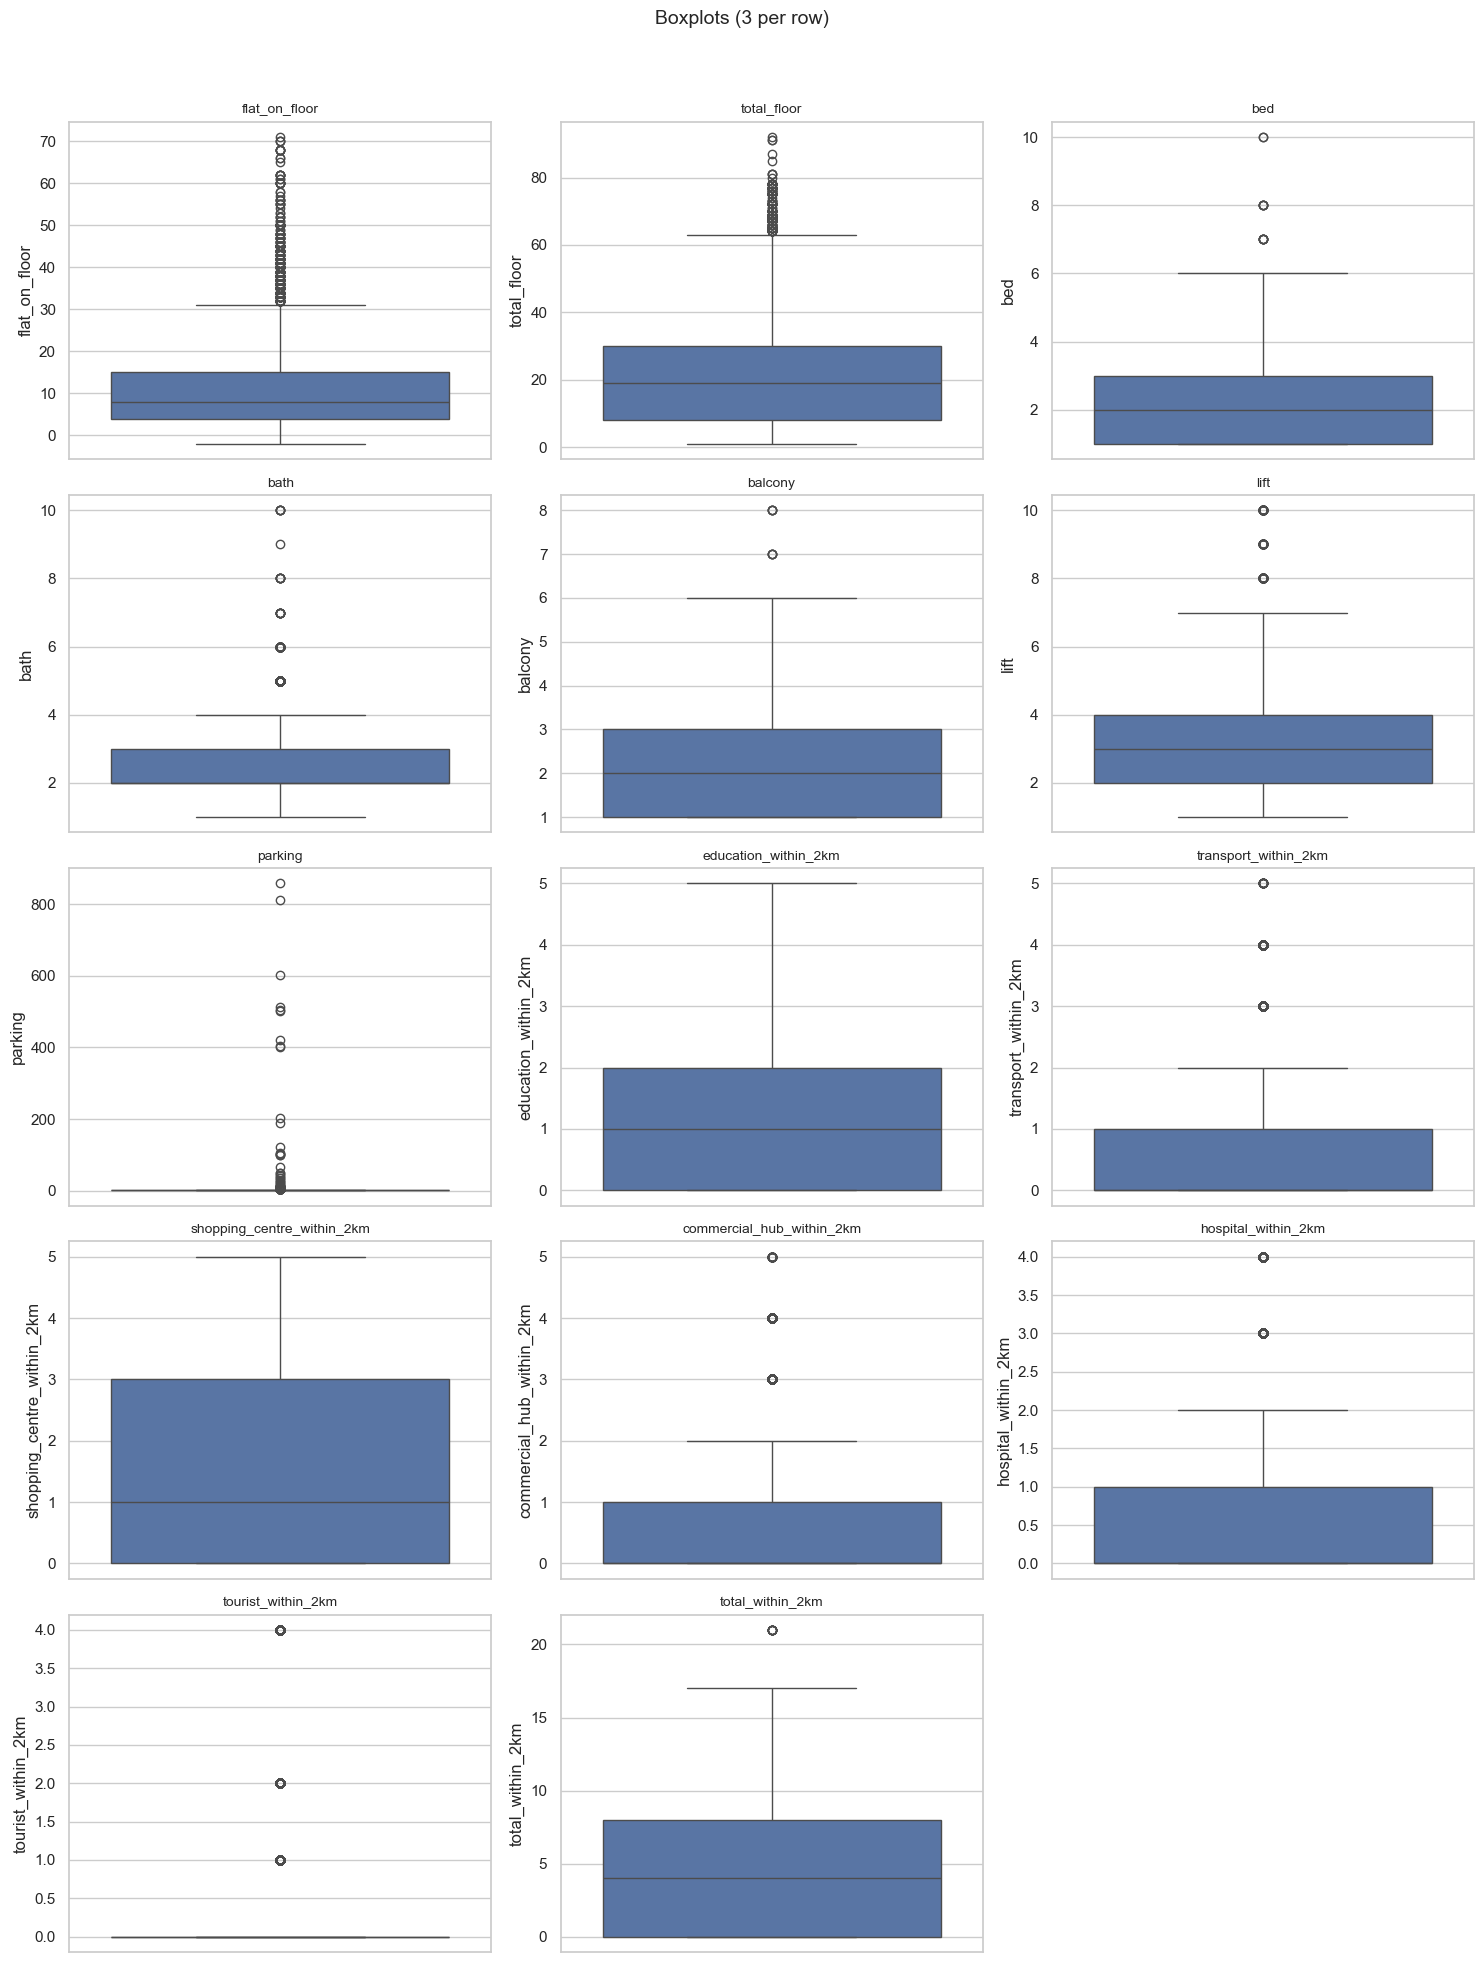

In [37]:
sns.set(style="whitegrid")

num_ordinal_cols = ['flat_on_floor','total_floor','bed','bath','balcony','lift','parking','education_within_2km','transport_within_2km','shopping_centre_within_2km',
                    'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

# layout config
n_cols = 3                      # 3 boxplots per row (first row will have 3)
n_plots = len(num_ordinal_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_ordinal_cols):
    ax = axes[i]
    if col not in X_train.columns:
        ax.set_visible(False)
        continue

    # ensure numeric (coerce bad values to NaN)
    series = pd.to_numeric(X_train[col], errors='coerce')

    # optional: drop NaNs for plotting or keep them (here we drop)
    series_clean = series.dropna()

    # draw vertical boxplot
    sns.boxplot(y=series_clean, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")    # hide x label (single value)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# hide any extra axes if total subplots > columns
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots (3 per row)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])   # leave space for suptitle
plt.show()


## Analysis on nominal_cat_cols

so we can use this methods for impute categorical col  
1)most-frequent    
2)constant  
3)KNN Imputer - for this we have to first convert the cat column into numerical   
4)Iterative Imputer - for this we have to first convert the cat column into numerical    
5)Custom Rules - Based on domain knowledge, Example: fill missing City based on Zipcode or Location

In [ ]:
nominal_cat_cols = ['builder','project_name','location','city','property_type','ownership','overlooking','facing','flooring','extra_rooms','seller']

### builder

In [ ]:
X_train['builder'].value_counts()

In [ ]:
df['builder'].unique().shape

In [ ]:
X_train['builder'].isna().sum()

Observation:

To impute missing values in the `builder` column using the `project_name` column, we apply the following rule:

For example:

|builder     | project\_name |
|----------- | ------------- |
|lodha       | pebble        |
|rustomjee   | vinayak       |
|lodha       | pebble        |
|excel group | vinayak       |
|**NaN**     | pebble        |
|**NaN**     | vinayak       |

After applying the logic:  

| builder     | project\_name |
| ----------- | ------------- |
| lodha       | pebble        |
| rustomjee   | vinayak       |
| lodha       | pebble        |
| excel group | vinayak       |
| **lodha**   | pebble        |
| **NaN**     | vinayak       |  

Here, `pebble` is uniquely associated with `lodha`, so the missing builder is filled as `lodha`.  
However, `vinayak` is linked to both `rustomjee` and `excel group`, so the missing value remains unfilled.  


In [ ]:
# Step 1: Group project_name by builder and count unique builders
project_to_builder = (
    df.dropna(subset=['builder', 'project_name'])
      .groupby('project_name')['builder']
      .nunique()
)

# Step 2: Filter only project_names with one unique builder
valid_projects = project_to_builder[project_to_builder == 1].index

# Step 3: Map project_name to builder where project_name is unique
project_to_unique_builder = (
    df[df['project_name'].isin(valid_projects)]
    .dropna(subset=['builder'])
    .drop_duplicates(subset=['project_name'])
    .set_index('project_name')['builder']
)

# Step 4: Fill missing builders
df['builder'] = df.apply(
    lambda row: project_to_unique_builder[row['project_name']]
    if pd.isna(row['builder']) and row['project_name'] in project_to_unique_builder
    else row['builder'],
    axis=1
)

In [ ]:
X_train['builder'].isna().sum()

`observation`
- Found nothing significant after grouping project_name by builder and counting unique builders.
- KNN and Iterative Imputer won't work as we don't have a numerical column; mode is also not feasible due to the absence of a dominating category.
- So, impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

In [ ]:
# Sample: X_train = your DataFrame, 'builder' = categorical col, 'price' = target col

# 1. Impute missing with 'missing'
X_train['builder'] = X_train['builder'].fillna('missing')

# 2. Get top 200 categories
top_200 = X_train['builder'].value_counts().nlargest(200).index

# 3. Replace others with 'other'
X_train['builder'] = X_train['builder'].apply(lambda x: x if x in top_200 else 'other')

# 4. Target Encoding
encoder = TargetEncoder(cols=['builder'])
X_train['builder_encoded'] = encoder.fit_transform(X_train['builder'], y_train)

# Optional: drop original if needed
# X_train.drop('builder', axis=1, inplace=True)


In [ ]:
describe_and_missing(X_train, 'builder_encoded')

`observation`
- mean and median values are different
- 3432 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'builder_encoded', constant_value=9999)
plot_kde_imputations(X_train, 'builder_encoded')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'builder_encoded')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'builder_encoded')

In [ ]:
print("Original:\n", X_train['builder_encoded'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['builder_encoded'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['builder_encoded'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`
- Impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

### project_name 

In [ ]:
X_train.shape

In [ ]:
X_train['project_name'].value_counts()

In [ ]:
X_train['project_name'].isna().sum()

In [ ]:
# Sample: X_train = your DataFrame, 'project_name' = categorical col, 'price' = target col

# 1. Impute missing with 'missing'
X_train['project_name'] = X_train['project_name'].fillna('missing')

# 2. Get top 200 categories
top_200 = X_train['project_name'].value_counts().nlargest(200).index

# 3. Replace others with 'other'
X_train['project_name'] = X_train['project_name'].apply(lambda x: x if x in top_200 else 'other')

# 4. Target Encoding
encoder = TargetEncoder(cols=['project_name'])
X_train['project_name_encoded'] = encoder.fit_transform(X_train['project_name'], y_train)

# Optional: drop original if needed
# X_train.drop('project_name', axis=1, inplace=True)


In [ ]:
# pd.set_option('display.max_rows', None)
# print(X_train['project_name_encoded'].value_counts())

In [ ]:
describe_and_missing(X_train, 'project_name_encoded')

`observation`
- mean and median values are different
- 3432 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'project_name_encoded', constant_value=9999)
plot_kde_imputations(X_train, 'project_name_encoded')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'project_name_encoded')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'project_name_encoded')

In [ ]:
print("Original:\n", X_train['project_name_encoded'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['project_name_encoded'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['project_name_encoded'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`
- Impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

### location

In [ ]:
X_train['location'].value_counts()

In [ ]:
X_train['location'].isna().sum()

In [ ]:
# Sample: X_train = your DataFrame, 'location' = categorical col, 'price' = target col

# 1. Impute missing with 'missing'
X_train['location'] = X_train['location'].fillna('missing')

# 2. Get top 200 categories
top_200 = X_train['location'].value_counts().nlargest(200).index

# 3. Replace others with 'other'
X_train['location'] = X_train['location'].apply(lambda x: x if x in top_200 else 'other')

# 4. Target Encoding
encoder = TargetEncoder(cols=['location'])
X_train['location_encoded'] = encoder.fit_transform(X_train['location'], y_train)

# Optional: drop original if needed
# X_train.drop('location', axis=1, inplace=True)


In [ ]:
# pd.set_option('display.max_rows', None)
# print(X_train['location_encoded'].value_counts())

In [ ]:
describe_and_missing(X_train, 'location_encoded')

`observation`
- mean and median values are different
- 3432 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'location_encoded', constant_value=9999)
plot_kde_imputations(X_train, 'location_encoded')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'location_encoded')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'location_encoded')

In [ ]:
print("Original:\n", X_train['location_encoded'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['location_encoded'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['location_encoded'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`
- Impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

### property_type

In [ ]:
X_train['property_type'].value_counts()

In [ ]:
X_train['property_type'].isna().sum()

`observation`

- have only 2 missing values and one dominant category hence use mode for imputation 

In [ ]:
X_train['property_type'].mode()[0]

In [ ]:
plot_categorical_imputations(X_train, 'property_type')

`observation`
- After using most_frequent (i.e.mode), the distribution remains almost the same. Hence, we can apply mode imputation on the property_type column.

In [ ]:
#applying ohe
X_train = pd.get_dummies(X_train, columns=['property_type'], drop_first=False)
#property_type will be dropped automatically, and replaced by new one hot encoded columns

`observation`

- mode and then OHE

### ownership

In [ ]:
X_train['ownership'].value_counts()

In [ ]:
X_train['ownership'].isna().sum()

`observation`
- Avoid target encoding for low-cardinality features due to risk of overfitting
- Mode imputation is not suitable as no single category dominates
- Use OHE 

In [ ]:
X_train['ownership'] = X_train['ownership'].fillna('missing')


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ownership_encoded = encoder.fit_transform(X_train[['ownership']])

# Optional: drop original & concatenate
X_train = X_train.drop('ownership', axis=1)
X_train = pd.concat([X_train, ownership_encoded], axis=1)

In [ ]:
ownership_encoded.head()

`observation`

- fillina using missing and then apply OHE 

### overlooking 

In [ ]:
X_train['overlooking'].value_counts()

In [ ]:
X_train['overlooking'].isna().sum()

`observation`
- Avoid target encoding for low-cardinality features due to risk of overfitting
- Mode imputation is not suitable as no single category dominates
- Use MultiLabel Binarizer

In [ ]:
# Step 1: Split entries into lists
X_train_split = X_train['overlooking'].fillna('missing').str.split(', ')

# Step 2: Fit on X_train only
mlb = MultiLabelBinarizer()
X_train_encoded = pd.DataFrame(mlb.fit_transform(X_train_split), columns=mlb.classes_, index=X_train.index)

# Optional: drop original & concatenate
X_train = X_train.drop('overlooking', axis=1)
X_train = pd.concat([X_train, X_train_encoded], axis=1)


In [ ]:
X_train_encoded.head()

`observation`

- fillina using missing and then use MultiLabelBinarizer
- There are two more methods assign weightage and actual weightage, so check out that also 

### facing 

In [ ]:
X_train['facing'].value_counts()

In [ ]:
X_train['facing'].isna().sum()

`observation`
- Avoid target encoding for low-cardinality features due to risk of overfitting
- Mode imputation is not suitable as no single category dominates
- Use OHE

In [ ]:
X_train['facing'] = X_train['facing'].fillna('missing')


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
facing_encoded = encoder.fit_transform(X_train[['facing']])

# Optional: drop original & concatenate
X_train = X_train.drop('facing', axis=1)
X_train = pd.concat([X_train, facing_encoded], axis=1)

In [ ]:
facing_encoded.head()

`observation`

- fillina usng missing and then OHE

### flooring 

In [ ]:
X_train['flooring'].value_counts()

In [ ]:
X_train['flooring'].isna().sum()

`observation`

- Mode imputation is not suitable as no single category dominates
- Use MultiLabel Binarizer

In [ ]:
# Step 1: Split entries into lists
X_train_split = X_train['flooring'].fillna('missing').str.split(', ')

# Step 2: Fit on X_train only
mlb = MultiLabelBinarizer()
X_train_encoded = pd.DataFrame(mlb.fit_transform(X_train_split), columns=mlb.classes_, index=X_train.index)

# Optional: drop original & concatenate
X_train = X_train.drop('flooring', axis=1)
X_train = pd.concat([X_train, X_train_encoded], axis=1)


In [ ]:
X_train_encoded.head()

`observation`

- fillina using missing and then use MultiLabelBinarizer
- there are 3 more methods so check out that also

### extra_rooms 

In [ ]:
X_train['extra_rooms'].value_counts()

In [ ]:
X_train['extra_rooms'].isna().sum()

`observation`
- Avoid target encoding as target encoding only works best when categories are clean and few — not when they’re combinations of multiple items.
- Mode imputation is not suitable as no single category dominates
- Use MultiLabel Binarizer

In [ ]:
# Step 1: Split entries into lists
X_train_split = X_train['extra_rooms'].fillna('missing').str.split(', ')

# Step 2: Fit on X_train only
mlb = MultiLabelBinarizer()
extra_rooms_encoded = pd.DataFrame(mlb.fit_transform(X_train_split), columns=mlb.classes_, index=X_train.index)

# Optional: drop original & concatenate
X_train = X_train.drop('extra_rooms', axis=1)
X_train = pd.concat([X_train, extra_rooms_encoded], axis=1)


In [ ]:
extra_rooms_encoded.head()

`observation`

- fillina using missing and then use MultiLabelBinarizer
- there are 3 more methods so check out that also 

### amenities

In [ ]:
# help to print full o/p
pd.set_option('display.max_colwidth', None)

# Print full value of first row
print(X_train['amenities'].head())

`assign weightage method`

In [ ]:
#final
amenities_weightages = {
    "sea facing": 10,
    "private pool": 10,
    "private jaccuzi": 10,
    "sky villa": 10,
    "helipad": 10,
    "wrap around balcony": 7,
    "infinity swimming pool": 10,
    "high ceiling": 9,
    "located in the heart of city": 10,
    "large open space": 10,
    "skyline view": 10,
    "private terrace/garden": 10,
    "private garage": 10,
    "mansion": 10,
    "club house": 9,
    "large clubhouse": 9,
    "modular kitchen": 9,
    "central ac": 9,
    "banquet hall": 6,
    "premium branded fittings": 9,
    "private garden": 9,
    "full glass wall": 9,
    "garden view": 9,
    "theme based architectures": 9,
    "grand entrance lobby": 9,
    "smart home": 9,
    "library and business centre": 9,
    "recreational pool": 9,
    "projector": 8,
    "swimming pool": 8,
    "gymnasium": 8,
    "indoor squash & badminton courts": 8,
    "outdoor tennis courts": 8,
    "cycling & jogging track": 8,
    "kids play pool with water slides": 8,
    "guest lobby in each floor": 8,
    "aesthetically designed landscape garden": 8,
    "health club with steam / jacuzzi": 8,
    "meditation area": 8,
    "pet park": 8,
    "visitor parking": 8,
    "badminton court": 8,
    "kids play area": 7,
    "community hall": 7,
    "power back up": 7,
    "cctv camera": 7,
    "rain water harvesting": 7,
    "internet/wi-fi connectivity": 7,
    "cycling track": 7,
    "art center": 7,
    "library": 7,
    "fire sprinklers": 7,
    "multipurpose hall": 7,
    "event space & amphitheatre": 7,
    "flower gardens": 6,
    "curated garden": 6,
    "multipurpose courts": 7,
    "dth television facility": 5,
    "fire fighting equipment": 6,
    "provision for power backup": 7,
    "sand pit": 6,
    "sewage treatment plant": 6,
    "solar energy": 7,
    "piped gas": 6,
    "kids club": 6,
    "waste disposal": 6,
    "lift": 5,
    "security": 5,
    "maintenance staff": 5,
    "reserved parking": 5,
    "ro water system": 5,
    "wheelchair accessibility": 5,
    "shopping center": 5,
    "laundry service": 5,
    "bank & atm": 5,
    "community entrance gate": 5,
    "canopy walk": 4,
    "entry exit gate": 4,
    "early learning centre": 4,
    "earth quake resistant": 7,
    "waste water recycling": 6,
    "whiteboard": 3,
    "printer": 3,
    "tea/coffee": 3,
    "house help accommodation": 7,
    "study room": 5,
    "ground water recharging": 5,
    "unknown": 0,
    "3 tier security system": 8,
    "ac in each room": 9,
    "activity deck4": 7,
    "aerobics room": 7,
    "air conditioned": 9,
    "all wooden flooring": 8,
    "arts & craft studio": 6,
    "bar/lounge": 7,
    "barbeque pit": 6,
    "barbeque space": 6,
    "cafeteria/food court": 7,
    "coffee lounge & restaurants": 7,
    "concierge services": 9,
    "conference room": 8,
    "cricket net practice": 6,
    "dance studio": 7,
    "downtown": 10,
    "fingerprint access": 8,
    "fireplace": 6,
    "golf course": 10,
    "hilltop": 10,
    "horticulture": 6,
    "indoor games room": 7,
    "island kitchen layout": 8,
    "jogging and strolling track": 7,
    "kids splash pool": 7,
    "lawn with pathway": 6,
    "guest accommodation":8,
    "marble flooring": 9,
    "mini cinema theatre": 9,
    "half basketball court":7,
    "park": 8,
    "pool with temperature control": 10,
    "intercom facility":6,
    "rentable community space": 6,
    "retail boulevard (retail shops)": 8,
    "service/goods lift": 6,
    "skydeck": 9,
    "vaastu compliant": 7,
    "volleyball court": 6,
    "water front": 10,
    "water storage": 5,
    "water treatment plant": 7,
    "wine cellar": 8
}

In [ ]:
# Function to calculate the combination score
def calculate_combination_score(amenities_combination):
    amenities_types = [f.strip().lower() for f in amenities_combination.split(",")]
    total_weight = sum(amenities_weightages.get(f, 0) for f in amenities_types)
    #combination_score = total_weight / len(amenities_types)
    return round(total_weight, 2)

# Apply the function to the dataframe
X_train["assigned_amenities_score"] = X_train["amenities"].apply(calculate_combination_score)

In [ ]:
X_train["assigned_amenities_score"].head() 

In [ ]:
X_train["assigned_amenities_score"].value_counts()

In [ ]:
# Replace 0 with NaN
X_train['assigned_amenities_score'] = X_train['assigned_amenities_score'].replace(0, None)

In [ ]:
X_train['assigned_amenities_score'] = pd.to_numeric(X_train['assigned_amenities_score'])

In [ ]:
X_train.drop(columns=['amenities'], inplace=True)

In [ ]:
X_train['assigned_amenities_score'].head()

In [ ]:
X_train['assigned_amenities_score'].isna().sum()

In [ ]:
describe_and_missing(X_train, 'assigned_amenities_score')

`observation`
- mean and median values are different
- 4050 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

In [ ]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'assigned_amenities_score', constant_value=9999)
plot_kde_imputations(X_train, 'assigned_amenities_score')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

In [ ]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'assigned_amenities_score')

In [ ]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'assigned_amenities_score')

In [ ]:
print("Original:\n", X_train['assigned_amenities_score'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['assigned_amenities_score'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['assigned_amenities_score'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

`observation`

- Knn work slight better but KNN imputation distorting the original distribution hence use missing indicator and let the model learn from the missingness itself.
- use assign weightage and then missing indicator then keep the original col and apply KNN imputation and min max scaling  
- use models for imputation like Xgboost and LightGBM

## Analysis on ordinal_cat_cols

In [ ]:
ordinal_cat_cols = ['status','construction','furnish']

#status : 'under construction < ongoing < ready to move'
#construction : 'under construction → new construction → less than 5 years → 5 to 10 years → 10 to 15 years → 15 to 20 years → above 20 years'
#furnish : 'unfurnished < semi-furnished < furnished'

### status

In [ ]:
X_train['status'].value_counts()

In [ ]:
df['status'].isna().sum()

`observation`

- Imputation: Very few missing values and one dominant category ('ready to move'), hence we use mode.

In [ ]:
# Mode imputation
X_train['status'] = X_train['status'].fillna(X_train['status'].mode()[0])

`observation`

- 1st apply mode and then ordinal encoding
- this is ordinal columns hence apply ordinal encoding or we can apply OHE  

### construction

In [ ]:
X_train['construction'].isna().sum()

In [ ]:
X_train['construction'].value_counts()

`observation`

- 'under construction' is the dominant category, but missing values are too many for mode imputation
- capture missingness by missing indicator by filling NaN values using 'missing' 

In [ ]:
X_train["construction_missing"] = X_train["construction"].isna().astype(int)
X_train["construction"] = X_train["construction"].fillna("missing")

In [ ]:
X_train[['construction_missing','construction']].head()

`observation`

- 1st apply missing indicator and then ordinal encoding
- this is ordinal columns hence apply ordinal encoding or we can apply OHE 

### furnish

In [ ]:
X_train['furnish'].isna().sum()

In [ ]:
X_train['furnish'].value_counts()

`observation`

- Imputation: Very few missing values and one dominant category ('unfurnished'), hence we use mode.

In [ ]:
# Mode imputation
X_train['furnish'] = X_train['furnish'].fillna(X_train['furnish'].mode()[0])

`observation`

- 1st apply mode and then ordinal encoding
- this is ordinal columns hence apply ordinal encoding or we can apply OHE 